# TFM - Análisis de Emisiones Industriales en la Unión Europea
### Registro Europeo E-PRTR / IED · Agencia Europea de Medio Ambiente · 2007–2024

**Máster en Data Science | Septiembre 2026

**GRUPO 1**

## Índice

| Sección | Contenido | Responsable |
|---------|-----------|-------------|
| 1 | Preprocesamiento y construcción del dataset |
| 2 | Análisis exploratorio de datos (EDA) |
| 3 | Predicción de emisiones de CO₂ (regresión) |
| 4 | Clasificación de sector industrial (red neuronal) |
| 5 | Clustering de países por perfil de emisiones |
| 6 | Series temporales y proyección 2025-2030 |

---

## Fuente de datos

**Registro:** European Pollutant Release and Transfer Register (E-PRTR)  
**Reglamento:** (CE) N°166/2006 del Parlamento Europeo  
**Institución:** Agencia Europea de Medio Ambiente (EEA)  
**Periodo:** 2007–2024 | **Países:** 32 | **Instalaciones:** 10.788  
**Ficheros fuente:** F1 (aire), F2 (agua), F3 (transferencias), F4 (residuos)

---

## Preguntas de investigación

1. ¿Es posible predecir las emisiones de CO₂ de una instalación
   industrial a partir de su perfil de contaminantes y actividad?
2. ¿Puede identificarse el sector industrial de una instalación
   únicamente a partir de lo que emite?
3. ¿Qué patrones comunes de comportamiento ambiental comparten
   los países europeos?
4. ¿Mantiene Europa una trayectoria de reducción de emisiones
   compatible con los objetivos del Pacto Verde para 2030?

---

## Nota sobre reproducibilidad

Todos los modelos utilizan `SEED = 42` fijado al inicio de cada
sección de modelado — los resultados son idénticos en cada
ejecución del notebook.

**Modelos guardados en Drive:**
- `model_co2.pkl` → XGBoost regresión (P4)
- `model_sector.keras` → Red neuronal clasificación (P1)
- `model_clusters.pkl` → KMeans clustering (P3)
- `model_series.pkl` → Drift series temporales (P5)
- `scaler.pkl` → StandardScaler clasificación (P1)


##1. Preprocesamiento y construcción del dataset

##FUENTE DE DATOS: EL REGISTRO EUROPEO E-PRTR
El E-PRTR (European Pollutant Release and Transfer Register) fue establecido mediante el Reglamento (CE) N°166/2006 del Parlamento Europeo y del Consejo, como aplicación en la Unión Europea del Protocolo de Kiev de 2003. Su objetivo es garantizar el libre acceso público a información sobre las emisiones y transferencias de contaminantes generadas por instalaciones industriales en Europa.

El registro incluye información anual sobre emisiones al aire, agua y suelo de 91 contaminantes, así como transferencias de residuos y de contaminantes en aguas residuales. La obligación de reportar aplica a las instalaciones cuyas actividades están listadas en el Anexo I del reglamento, agrupadas en 9 sectores industriales, cuando superan determinados umbrales de capacidad o de emisión.

La Agencia Europea de Medio Ambiente (EEA) es la institución responsable de consolidar, validar y publicar los datos reportados por los Estados Miembros.

## Descripción de las tablas originales
El dataset original de la EEA es una base de datos Microsoft Access .accdb con 33 tablas organizadas en cuatro niveles jerárquicos: Production Site - Facility - Installation - Part. El nivel Facility corresponde al ámbito del reglamento E-PRTR y es donde se reportan las emisiones y transferencias objeto de este trabajo. Cada instalación se identifica con un INSPIRE_ID, un identificador único y permanente que permite hacer seguimiento a lo largo del tiempo.

La EEA también ofrece archivos CSV simplificados. Para este trabajo se seleccionaron los 4 archivos con mayor nivel de detalle (por instalación industrial)(F1, F2, F3 y F4), excluyendo los archivos agrupados por país, sector o actividad:

Archivo	Contenido	Filas	Variable numérica	Unidades
F1 — Air Releases	Emisiones al aire	370,301	Releases	kg/año
F2 — Water Releases	Emisiones al agua	252,313	Releases	kg/año
F3 — Transfers	Transferencias de contaminantes	65,475	transfers	kg/año
F4 — Waste Transfers	Transferencias de residuos	843,877	wasteTransfers	toneladas/año
Los 4 archivos comparten 16 columnas y FacilityInspireId y reportingYearserán las columnas clave, los que permiten integrarlos en un único dataset.

OJO: Sobre las unidades: F1, F2 y F3 reportan cantidades en kg/año, mientras que F4 reporta en toneladas/año.

## Diccionario de variables de los archivos originales
Los 4 archivos CSV comparten la siguiente estructura de 16 variables:

FacilityInspireId: Identificador único y permanente de cada instalación industrial.

reportingYear: Año al que corresponde el dato de emisión (ente 2007–2024).

PublicationDate: Fecha en la que la EEA publicó el dato.

countryName: País donde está la instalación.

facilityName: Nombre comercial de la instalación.

city: Ciudad donde está ubicada la instalación

Latitude / Longitude: Coordenadas geográficas para ubicar la instalación en un mapa.

EPRTR_SectorCode - EPRTR_SectorName: Código numérico del (1-9) y Nombre del sectior industrial.

EPRTRAnnexIMainActivity: Actividad industrial principal de la instalación según el Anexo I del reglamento E-PRTR

TargetRelease: Medio al que se libera el contaminante (Air, Water, Land). Solo son F1(aire) y F2(agua).

Pollutant: Es el contaminante (CO2, CH4, NH3, etc.). Solo en F1, F2 y F3.

Releases: Cantidad total del contaminante liberado (kg/año). Solo en F1 y F2.

transfers: Cantidad total del contaminante transferido en aguas residuales (kg/año). Solo en F3.

wasteTransfers: Cantidad total de residuos transferidos (toneladas/año). Solo en F4.

wasteTreatment: Qué se hace con el residuo después de transferirlo. Solo hay dos valores: R = Recovery (recuperación: reciclaje, reutilización, valorización energética) y D = Disposal (eliminación: vertedero, incineración sin recuperación). Solo en F4

wasteClassification: Clasificación de residuo. Solo hay dos valores: HW = Hazardous Waste(residuo peligroso: Químico tóxico, aceites usados, baterías, disolventes, etc.) y NONHW = Non-Hazardous Waste (residuo no peligroso: Escombro, residuos orgánicos, papel, plástico común, etc.) Solo en F4.

confidentialityReason: Motivo de confidencialidad del dato.

addressConfidentialityReason: Motivo de confidencialidad de la dirección

# PREPROCESAMIENTO Y LIMPIEZA DE DATOS

## Preprocesamiento de datos
Los 4 archivos CSV originales están en formato largo: cada fila representa un solo contaminante reportado por una instalación en un año. Una misma instalación puede tener 3, 5 o 15 filas en el mismo año, una por cada contaminante que reportó.

En este preprocesamiento transformamos estos 4 archivos en un único dataset, dataset en formato ancho, donde cada instalación-año ocupa una sola fila y cada contaminante es una columna separada.

Pasos de preprocesamiento:

Paso	Descripción
Paso 1	Carga de los 4 archivos CSV
Paso 2	Pivotado y merge
Paso 3	Diagnóstico del dataset resultante
Paso 4	Limpieza de filas
Paso 5	Verificación de coordenadas
Paso 6	Tratamiento de valores faltantes en metadatos
Paso 7	Documentación y verificación final
Paso 8	Dataset limpio

## PASO 1: CARGANDO ARCHIVOS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE    = '/content/drive/MyDrive/TFM/'
DATA    = BASE + 'datasets/'
MODELOS = BASE + 'modelos/'

import os
if not os.path.exists(BASE):
    raise FileNotFoundError(
        "No se encuentra la carpeta TFM. "
        "Añade un acceso directo: clic derecho > Organizar > Añadir acceso directo a Drive."
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Fijación de semilla e imports globales

In [ ]:
import random
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Librerías base cargadas | SEED={SEED}")

Librerías base cargadas | SEED=42


## PASO 2: PIVOTADO Y MERGE DE DATOS

Pivotado y Merge: Es una transformación de los 4 archivos .csv en formato largo a un solo dataset en formato ancho, obteniendo filas unicas por instalación.

### 2.1 Importaciones y definiciones

In [ ]:
# Columnas clave: identifican una fila única (instalación + año)
KEYS = ['FacilityInspireId', 'reportingYear']

# Columnas descriptivas: información de cada instalación que no participa en el pivotado pero que necesitamos conservarlos
META_COLS = ['countryName','facilityName','city','Longitude','Latitude',
              'EPRTR_SectorCode','EPRTR_SectorName','EPRTRAnnexIMainActivity']


print(f"\n{'='*60}")
print(" 2.1 — Definiciones")
print(f"{'='*60}")

print(f"\n  KEYS: {KEYS}")
print(f"  META_COLS: {META_COLS}\n")


 2.1 — Definiciones

  KEYS: ['FacilityInspireId', 'reportingYear']
  META_COLS: ['countryName', 'facilityName', 'city', 'Longitude', 'Latitude', 'EPRTR_SectorCode', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity']



### 2.2 Carga de los 4 archivos CSV

In [ ]:
print(f"\n{'='*60}")
print(" 2.2 — Carga de los 4 archivos CSV")
print(f"{'='*60}\n")

f1_raw = pd.read_csv(DATA + 'F1_4_Air_Releases_Facilities.csv', low_memory=False)
f2_raw = pd.read_csv(DATA + 'F2_4_Water_Releases_Facilities.csv', low_memory=False)
f3_raw = pd.read_csv(DATA + 'F3_2_Transfers_Facilities.csv', low_memory=False)
f4_raw = pd.read_csv(DATA + 'F4_2_WasteTransfers_Facilities.csv', low_memory=False)

for nombre, df in [('F1 - Aire', f1_raw), ('F2 - Agua', f2_raw),
                    ('F3 - Transferencias', f3_raw), ('F4 - Residuos', f4_raw)]:
    print(f"  {nombre}: {df.shape[0]:,} filas × {df.shape[1]} columnas")


 2.2 — Carga de los 4 archivos CSV

  F1 - Aire: 370,301 filas × 16 columnas
  F2 - Agua: 252,313 filas × 16 columnas
  F3 - Transferencias: 65,475 filas × 15 columnas
  F4 - Residuos: 843,877 filas × 16 columnas


### 2.3 Definir la función de pivotado a formato ancho

Función para pivotar los archivos a formato ancho

df: dataframe a pivotar, value_col: columna con números(Releases), top_n: cuantos contaminantes conservar, prefix: prefijo para las columnas resultantes, categorya_col: Columna con nombres de contaminantes(Pollutant)

In [ ]:
def pivot_top_n(df, value_col, top_n, prefix, category_col='Pollutant'):

    counts = (df.groupby(category_col)[KEYS]
                .apply(lambda x: len(x.drop_duplicates()))
                .sort_values(ascending=False))

    top = counts.head(top_n).index.tolist()

    sub = df[df[category_col].isin(top)]

    wide = sub.pivot_table(index=KEYS, columns=category_col,
                           values=value_col, aggfunc='sum')

    wide.columns = [f"{prefix}_{c}" for c in wide.columns]

    return wide.reset_index()

### 2.4 Pivotamos F1, F2 y F3

In [ ]:
print(f"\n{'='*60}")
print(" 2.4 — Pivotando F1, F2 y F3")
print(f"{'='*60}")

f1_wide = pivot_top_n(f1_raw, 'Releases', 15, 'AIR')
print(f"\n  F1 (aire): {f1_wide.shape[0]:,} filas × {f1_wide.shape[1]} columnas")

f2_wide = pivot_top_n(f2_raw, 'Releases', 10, 'WATER')
print(f"  F2 (agua): {f2_wide.shape[0]:,} filas × {f2_wide.shape[1]} columnas")

f3_wide = pivot_top_n(f3_raw, 'transfers', 6, 'TRANSFER')
print(f"  F3 (transferencias): {f3_wide.shape[0]:,} filas × {f3_wide.shape[1]} columnas\n")


 2.4 — Pivotando F1, F2 y F3

  F1 (aire): 197,954 filas × 17 columnas
  F2 (agua): 51,319 filas × 12 columnas
  F3 (transferencias): 27,818 filas × 8 columnas



### 2.5 Pivotamos F4

In [ ]:
print(f"\n{'='*60}")
print(" 2.5 — Pivotando F4 (los residuos)")
print(f"{'='*60}")

f4_raw['waste_combo'] = f4_raw['wasteTreatment'] + '_' + f4_raw['wasteClassification']

main_combos = ['Recovery_HW','Recovery_NONHW','Disposal_HW','Disposal_NONHW']

f4_wide = (f4_raw[f4_raw['waste_combo'].isin(main_combos)]
           .pivot_table(index=KEYS, columns='waste_combo',
                        values='wasteTransfers', aggfunc='sum')
           .rename(columns=lambda c: f"WASTE_{c}")
           .reset_index())

print(f"\n Categorías creadas: {main_combos}")
print(f" F4 (residuos): {f4_wide.shape[0]:,} filas × {f4_wide.shape[1]} columnas\n")


 2.5 — Pivotando F4 (los residuos)

 Categorías creadas: ['Recovery_HW', 'Recovery_NONHW', 'Disposal_HW', 'Disposal_NONHW']
 F4 (residuos): 415,121 filas × 6 columnas



### 2.6 Extracción de metadatos

Extraemos metadatos porque después del pivotado los archivos solo se quedan con las columnas clave KEYS y columnas de contaminantes, las demás columnas se perdieron al pivotar.

Recuperamos de F1 porque este tiene la mayor variedad de instalaciones y si usamos otro posiblemente muchas instalaciones no tendrian metadatos.

In [ ]:
print(f"\n{'='*60}")
print("2.6 — Extracción de metadatos")
print(f"{'='*60}")

# Extraer metadatos de F1 original
meta = f1_raw[KEYS + META_COLS].drop_duplicates(subset=KEYS)
print(f"\n  Metadatos extraídos: {meta.shape[0]:,} filas × {meta.shape[1]} columnas")


2.6 — Extracción de metadatos

  Metadatos extraídos: 207,230 filas × 10 columnas


### 2.7 Merge final y Resultado de Dataset final

In [ ]:
print(f"\n{'='*60}")
print("2.7 — Merge final")
print(f"{'='*60}")

# Merge final
merged = f1_wide.merge(f4_wide, on=KEYS, how='inner')
print(f"\n  Después de merge F1 + F4 (inner): {merged.shape[0]:,} filas × {merged.shape[1]} columnas")

merged = merged.merge(meta, on=KEYS, how='left')
print(f"  Después de merge + metadatos (left): {merged.shape[0]:,} filas × {merged.shape[1]} columnas")

merged = merged.merge(f2_wide, on=KEYS, how='left')
print(f"  Después de merge + F2 agua (left): {merged.shape[0]:,} filas × {merged.shape[1]} columnas")

merged = merged.merge(f3_wide, on=KEYS, how='left')
print(f"  Después de merge + F3 transferencias (left): {merged.shape[0]:,} filas × {merged.shape[1]} columnas")

print(f"\n{'='*60}")
print(f"  RESULTADO")
print(f"{'='*60}")
print(f"  Dataset final: {merged.shape[0]:,} filas × {merged.shape[1]} columnas")


2.7 — Merge final

  Después de merge F1 + F4 (inner): 82,113 filas × 21 columnas
  Después de merge + metadatos (left): 82,113 filas × 29 columnas
  Después de merge + F2 agua (left): 82,113 filas × 39 columnas
  Después de merge + F3 transferencias (left): 82,113 filas × 45 columnas

  RESULTADO
  Dataset final: 82,113 filas × 45 columnas


In [ ]:
for i, col in enumerate(merged.columns, 1):
    print(f"  {i}. {col}")

  1. FacilityInspireId
  2. reportingYear
  3. AIR_Ammonia (NH3)
  4. AIR_Carbon dioxide (CO2)
  5. AIR_Carbon dioxide (CO2) excluding biomass
  6. AIR_Carbon monoxide (CO)
  7. AIR_Chlorine and inorganic compounds (as HCl)
  8. AIR_Hydrochlorofluorocarbons (HCFCs)
  9. AIR_Mercury and compounds (as Hg)
  10. AIR_Methane (CH4)
  11. AIR_Nickel and compounds (as Ni)
  12. AIR_Nitrogen oxides (NOX)
  13. AIR_Nitrous oxide (N2O)
  14. AIR_Non-methane volatile organic compounds (NMVOC)
  15. AIR_Particulate matter (PM10)
  16. AIR_Sulphur oxides (SOX)
  17. AIR_Zinc and compounds (as Zn)
  18. WASTE_Disposal_HW
  19. WASTE_Disposal_NONHW
  20. WASTE_Recovery_HW
  21. WASTE_Recovery_NONHW
  22. countryName
  23. facilityName
  24. city
  25. Longitude
  26. Latitude
  27. EPRTR_SectorCode
  28. EPRTR_SectorName
  29. EPRTRAnnexIMainActivity
  30. WATER_Arsenic and compounds (as As)
  31. WATER_Chlorides (as total Cl)
  32. WATER_Copper and compounds (as Cu)
  33. WATER_Fluorides (as total F

In [ ]:
merged.head(10)

,FacilityInspireId,reportingYear,AIR_Ammonia (NH3),AIR_Carbon dioxide (CO2),AIR_Carbon dioxide (CO2) excluding biomass,AIR_Carbon monoxide (CO),AIR_Chlorine and inorganic compounds (as HCl),AIR_Hydrochlorofluorocarbons (HCFCs),AIR_Mercury and compounds (as Hg),AIR_Methane (CH4),...,WATER_Total nitrogen,WATER_Total organic carbon(as total C or COD/3) (TOC),WATER_Total phosphorus,WATER_Zinc and compounds (as Zn),TRANSFER_Nickel and compounds (as Ni),TRANSFER_Phenols (as total C),TRANSFER_Total nitrogen,TRANSFER_Total organic carbon(as total C or COD/3) (TOC),TRANSFER_Total phosphorus,TRANSFER_Zinc and compounds (as Zn)
0,AT.CAED/9008390306826.FACILITY,2010,NaN,106000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,476000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AT.CAED/9008390306826.FACILITY,2011,NaN,102000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,511000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AT.CAED/9008390306826.FACILITY,2012,NaN,102000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,466000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AT.CAED/9008390317211.FACILITY,2008,NaN,107000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,614000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AT.CAED/9008390317211.FACILITY,2010,NaN,104000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500000.0,NaN,NaN
5,AT.CAED/9008390317211.FACILITY,2011,NaN,101000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,515000.0,NaN,NaN
6,AT.CAED/9008390317211.FACILITY,2012,NaN,103000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,621000.0,NaN,NaN
7,AT.CAED/9008390392737.FACILITY,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,23.0,NaN,NaN,NaN,NaN,NaN
8,AT.CAED/9008390396414.FACILITY,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,AT.CAED/9008390396414.FACILITY,2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## PASO 3: DIAGNÓSTICO DEL DATASET RESULTANTE

Antes de limpiar necesitamos conocer la estructura del dataset resultante, conocer el número de filas y columnas, el tipo de dato de cada columna, el numero de valores NaN

### 3.1 ESTRUCTURA BÁSICA

In [ ]:
print(f"\n{'='*60}")
print("3.1 — Dimensiones, valores no-nulos y tipos de datos:")
print(f"{'='*60}")

print(f"\nDimensiones: {merged.shape[0]:,} filas × {merged.shape[1]} columnas\n")


merged.info()


3.1 — Dimensiones, valores no-nulos y tipos de datos:

Dimensiones: 82,113 filas × 45 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82113 entries, 0 to 82112
Data columns (total 45 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   FacilityInspireId                                         82113 non-null  object 
 1   reportingYear                                             82113 non-null  int64  
 2   AIR_Ammonia (NH3)                                         13548 non-null  float64
 3   AIR_Carbon dioxide (CO2)                                  33989 non-null  float64
 4   AIR_Carbon dioxide (CO2) excluding biomass                6407 non-null   float64
 5   AIR_Carbon monoxide (CO)                                  8321 non-null   float64
 6   AIR_Chlorine and inorganic compounds (as HCl)             6362 non-null   float64
 7   AIR_Hy

### 3.2 VALORES ÚNICOS EN METADATOS

Verificamos que los metadatos o datos descriptivos de cada instalacion tenga sentido, es decir, que el numero de paises, los años y los sectores concuerden con los mencionado en la data. Si no concuerda, sabremos que existe un problema.

In [ ]:
print("=" * 60)
print("3.2 — Valores únicos en metadatos")
print("=" * 60)

print(f"\nPaíses únicos: {merged['countryName'].nunique()}")
print( merged['countryName'].unique())

print(f"\nAños únicos: {merged['reportingYear'].nunique()}")
print(f"Rango: {merged['reportingYear'].min()} - {merged['reportingYear'].max()}")
print( merged['reportingYear'].unique())

print(f"\nSectores únicos: {merged['EPRTR_SectorCode'].nunique()}")
print( merged['EPRTR_SectorCode'].dropna().unique())

3.2 — Valores únicos en metadatos

Países únicos: 32
['Austria' 'Belgium' 'Bulgaria' 'Switzerland' 'Cyprus' 'Czechia' 'Germany'
 'Denmark' 'Estonia' 'Greece' 'Spain' 'Finland' 'France' 'United Kingdom'
 'Croatia' 'Hungary' 'Ireland' 'Iceland' 'Italy' 'Lithuania' 'Luxembourg'
 'Latvia' 'Malta' 'Netherlands' 'Norway' 'Poland' 'Portugal' 'Romania'
 'Serbia' 'Sweden' 'Slovenia' 'Slovakia']

Años únicos: 18
Rango: 2007 - 2024
[2010 2011 2012 2008 2021 2007 2018 2019 2020 2022 2023 2009 2013 2014
 2015 2016 2017 2024]

Sectores únicos: 9
[6. 4. 2. 3. 9. 8. 1. 5. 7.]


### 3.3 Valores en 0 en los contaminantes y residuos

Verificar si hay valores 0 en las columnas contaminantes y residuos, esto puede significar que se reportó, pero que se declaró que no emitió nada (0 kg o tn) durante ese año

In [ ]:
print(f"\n{'='*60}")
print("3.3 — Valores en 0 por grupo de columnas")
print(f"{'='*60}")

# Seleccionamos columnas según prefijo

for prefijo in ['AIR_', 'WATER_', 'TRANSFER_', 'WASTE_']:

    cols = [c for c in merged.columns if c.startswith(prefijo)]

    ceros = merged[cols].eq(0).sum().sum()

    total_valores = merged[cols].notna().sum().sum()

    if total_valores > 0:
        porcentaje = (ceros / total_valores) * 100
    else:
        porcentaje = 0

    print(f"  {prefijo}: {ceros:,} ceros de {total_valores:,} valores ({porcentaje:.2f}%)")


3.3 — Valores en 0 por grupo de columnas
  AIR_: 196 ceros de 193,553 valores (0.10%)
  WATER_: 73 ceros de 47,537 valores (0.15%)
  TRANSFER_: 16 ceros de 10,159 valores (0.16%)
  WASTE_: 379 ceros de 192,305 valores (0.20%)


### 3.4 Verificación de coordenadas

Verificamos si hay coordenadas imposibles o fuera del planeta, coordenadas de ultramas o fuera de europa pero permitidos y filas sin coordenadas.

In [ ]:
print(f"\n{'='*60}")
print("3.4 — Verificación de coordenadas")
print(f"{'='*60}")

tiene_coord = merged['Latitude'].notna()

dentro_europa = (
    merged['Latitude'].between(35, 75) &
    merged['Longitude'].between(-25, 50)
)

dentro_planeta = (
    merged['Latitude'].between(-90, 90) &
    merged['Longitude'].between(-180, 180)
)

print(f"\n  Con coordenadas: {tiene_coord.sum():,}")
print(f"  Sin coordenadas: {(~tiene_coord).sum():,}")
print(f"  Dentro de Europa: {(tiene_coord & dentro_europa).sum():,}")
print(f"  Fuera de Europa pero permitido (ultramar): {(tiene_coord & ~dentro_europa & dentro_planeta).sum():,}")
print(f"  Imposibles (fuera del planeta): {(tiene_coord & ~dentro_planeta).sum():,}")


3.4 — Verificación de coordenadas

  Con coordenadas: 81,946
  Sin coordenadas: 167
  Dentro de Europa: 81,277
  Fuera de Europa pero permitido (ultramar): 669
  Imposibles (fuera del planeta): 0


## PASO 4: LIMPIEZA DE FILAS

### 4.1 Eliminamos filas que no tienen sector ni actividad

La instalación, al no tener sector no sabriamos si es de energía, ganadería, química, etc. Esto puede afectar futuros analisis.

In [ ]:
print("=" * 60)
print("4.1 — Eliminamos filas sin sector")
print("=" * 60)

filas_antes = len(merged)

cols_sector = ['EPRTR_SectorCode', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity']

merged = merged.dropna(subset=cols_sector)

merged = merged.reset_index(drop=True)

print(f"\n  Antes: {filas_antes:,} filas")
print(f"  Después: {len(merged):,} filas")
print(f"  Eliminadas: {filas_antes - len(merged):,} filas ({(filas_antes - len(merged))/filas_antes*100:.2f}%)")

print(f"\n{'='*60}")
print("Verificación")
print("=" * 60)

for col in cols_sector:
    nulos = merged[col].isnull().sum()
    print(f"  {col}: {nulos} NaN")

print(f"\n{'='*60}")
print(f"RESULTADO")
print(f"{'='*60}")
print(f"  Dataset: {merged.shape[0]:,} filas × {merged.shape[1]} columnas")

4.1 — Eliminamos filas sin sector

  Antes: 82,113 filas
  Después: 81,005 filas
  Eliminadas: 1,108 filas (1.35%)

Verificación
  EPRTR_SectorCode: 0 NaN
  EPRTR_SectorName: 0 NaN
  EPRTRAnnexIMainActivity: 0 NaN

RESULTADO
  Dataset: 81,005 filas × 45 columnas


## PASO 5: VERIFICACIÓN DE COORDENADAS

### 5.1 Busqueda de coordenadas imposibles

Nos cercioramos de que no haya coordenadas imposibles, si encontramos, eliminamos porque serian errores de datos porque no existen

In [ ]:
print("=" * 60)
print("5.1 — Coordenadas imposibles")
print("=" * 60)

tiene_coord = merged['Latitude'].notna() & merged['Longitude'].notna()
dentro_planeta = (
    merged['Latitude'].between(-90, 90) &
    merged['Longitude'].between(-180, 180)
)
imposibles = (tiene_coord & ~dentro_planeta).sum()
print(f"   Coordenadas imposibles: {imposibles}")

if imposibles > 0:
    merged = merged[~(tiene_coord & ~dentro_planeta)]
    merged = merged.reset_index(drop=True)
    print(f"   Eliminadas {imposibles} filas")
else:
    print(f"   No hay coordenadas imposibles. No se eliminó nungún NaN.")

5.1 — Coordenadas imposibles
   Coordenadas imposibles: 0
   No hay coordenadas imposibles. No se eliminó nungún NaN.


### 5.2 Documentar coordenadas de ultramar

Nos informamos de cuantas coordenadas son aceptadas por E-PRTR pero que están fuera de europa, pero dentro del planeta. Son territorios como Guayana Francesa (Sudamérica), Reunión (océano Índico), Canarias y Azores (Atlántico).

Europa continental: Latitud 35-75, Longitud -25 a +50.

In [ ]:
print("=" * 60)
print("5.2 — Coordenadas de ultramar (Solo para documentar)")
print("=" * 60)

dentro_europa = (
    merged['Latitude'].between(35, 75) &
    merged['Longitude'].between(-25, 50)
)
ultramar = (tiene_coord & ~dentro_europa & dentro_planeta).sum()
sin_coord = (~tiene_coord).sum()

print(f"\n  Dentro de Europa: {(tiene_coord & dentro_europa).sum():,}")
print(f"  Fuera de Europa (ultramar): {ultramar:,}")
print(f"  Sin coordenadas: {sin_coord:,}")

print(f"  Se mantienen todos, incluso las instalaciones sin coordenadas, porque además que son pocos,  son instalaciones con contaminantes y residuos.")

print(f"\n{'='*60}")
print(f" RESULTADO")
print(f"{'='*60}")
print(f"\n  Dataset: {merged.shape[0]:,} filas × {merged.shape[1]} columnas\n")

5.2 — Coordenadas de ultramar (Solo para documentar)

  Dentro de Europa: 80,177
  Fuera de Europa (ultramar): 661
  Sin coordenadas: 167
  Se mantienen todos, incluso las instalaciones sin coordenadas, porque además que son pocos,  son instalaciones con contaminantes y residuos.

 RESULTADO

  Dataset: 81,005 filas × 45 columnas



## PASO 6: TRATAMIENTO DE VALORES FALTANTES EN METADATOS

Tanto para las columnas facilityName como city, encontramos que hay filas con NaN, 1NaN y 30NaN respectivamente. No lo eliminamos porque estos tienen datos de contaminantes y residuos. Lo que se hará es rellenar los datos faltantes para no desperdiciar información que puede ser útil.

### 6.1 Rellenar facilityName

La columna facilityName tiene solo 1 fila sin nombre, pero es una fila con datos importantes, asi que lo rellenamos con "Sin nombre"

In [ ]:
print("=" * 60)
print("6.1 — Rellenar facilityName")
print("=" * 60)

nulos_nombre = merged['facilityName'].isnull().sum()
merged['facilityName'] = merged['facilityName'].fillna('Sin nombre')
print(f"\n {nulos_nombre} NaN, es rellenados con 'Sin nombre'\n")

6.1 — Rellenar facilityName

 1 NaN, es rellenados con 'Sin nombre'



### 6.2 Rellenar city

La columna city tiene 30 filas sin nombre, pero con datos importantes de contaminantes y residuos, y además de que ya tenemos columnas como countryName y coordenadas. Así que rellenamos con "Desconocido"

In [ ]:
print("=" * 60)
print("6.2 — Rellenar city")
print("=" * 60)

nulos_city = merged['city'].isnull().sum()
merged['city'] = merged['city'].fillna('Desconocido')
print(f"\n  {nulos_city} NaN, es rellenados con 'Desconocido'\n")

6.2 — Rellenar city

  30 NaN, es rellenados con 'Desconocido'



### 6.3 Rellenar valores raros

Algunas instalaciones reportaron caracteres como "--", ".", ".." en la columna city y "–" en facilityName. Son datos que vienen así de la fuente original del E-PRTR. Reemplazamos valores para mantener valores de contaminantes.

In [ ]:
print("=" * 60)
print("6.3 — Rellenar valores raros")
print("=" * 60)

raros_city = merged['city'].isin(['--', '.', '..']).sum()
merged['city'] = merged['city'].replace(['--', '.', '..'], 'Desconocido')

raros_nombre = (merged['facilityName'] == '–').sum()
merged['facilityName'] = merged['facilityName'].replace(['–'], 'Sin nombre')

print(f"\n  city: {raros_city:,} valores raros → 'Desconocido'")
print(f"  facilityName: {raros_nombre} valor raro → 'Sin nombre'")

6.3 — Rellenar valores raros

  city: 1,032 valores raros → 'Desconocido'
  facilityName: 1 valor raro → 'Sin nombre'


### 6.4 Verificación de metadatos

Revisamos que ya no haya NaN en ninguna de las columnas de metadatos. Como resultado se obtuvo que tanto longitud como latitud presentan valores NaN, pero lo mantenemos.

In [ ]:
# Revisamos que ya no hay NaN en ninguna de las columnas de metadatos.

print(f"{'='*60}")
print("6.4 — Verificación de metadatos")
print(f"{'='*60}\n")

meta_cols = ['FacilityInspireId', 'reportingYear', 'countryName',
             'facilityName', 'city', 'Longitude', 'Latitude',
             'EPRTR_SectorCode', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity']

for col in meta_cols:
    nulos = merged[col].isnull().sum()
    estado = "No" if nulos == 0 else f"Si {nulos:,} NaN"
    print(f" {col}: {estado}")

print(f"\n{'='*60}")
print(f" RESULTADO")
print(f"{'='*60}")
print(f"\n  Dataset: {merged.shape[0]:,} filas × {merged.shape[1]} columnas")

6.4 — Verificación de metadatos

 FacilityInspireId: No
 reportingYear: No
 countryName: No
 facilityName: No
 city: No
 Longitude: Si 167 NaN
 Latitude: Si 167 NaN
 EPRTR_SectorCode: No
 EPRTR_SectorName: No
 EPRTRAnnexIMainActivity: No

 RESULTADO

  Dataset: 81,005 filas × 45 columnas


### 6.5 Verificación de valores en 0 en las columnas de cantidad.

Se mantendrá los valores con 0 debido a que pueden ser reportes de emisiones o residuos reales.


In [ ]:
print(f"{'='*60}")
print("6.5 — Valores en 0")
print(f"{'='*60}\n")

for prefijo in ['AIR_', 'WATER_', 'TRANSFER_', 'WASTE_']:
    cols = [c for c in merged.columns if c.startswith(prefijo)]
    ceros = merged[cols].eq(0).sum().sum()
    total_valores = merged[cols].notna().sum().sum()
    if total_valores > 0:
        porcentaje = (ceros / total_valores) * 100
    else:
        porcentaje = 0
    print(f"  {prefijo}: {ceros:,} ceros de {total_valores:,} valores ({porcentaje:.2f}%) → Se mantienen")

6.5 — Valores en 0

  AIR_: 196 ceros de 191,708 valores (0.10%) → Se mantienen
  WATER_: 73 ceros de 47,279 valores (0.15%) → Se mantienen
  TRANSFER_: 16 ceros de 10,096 valores (0.16%) → Se mantienen
  WASTE_: 378 ceros de 189,980 valores (0.20%) → Se mantienen


## PASO 7: DOCUMENTACIÓN Y VERIFICACIÓN FINAL

Realizaremos un resumen de todos los cambios hechos y una verificacion final del dataset.

### 7.1 Todos los cambios aplicados

In [ ]:
print(f"\n{'='*60}")
print("7.1 — Resumen de cambios sobre dataset merged")
print(f"{'='*60}")

print(f"\n  Dataset original:   82,113 filas × 45 columnas")

print(f"  Paso 4.1 — Filas de las columnas sector y actividad eliminadas:     -1,108 filas")

print(f"  Paso 5.1 — Coordenadas imposibles eliminadas:                         0 filas")

print(f"  Paso 5.2 — Coordenadas ultramar mantenidas:                          661 filas")

print(f"  Paso 5.2 — Coordenadas sin datos (mantenidas):                       167 filas")

print(f"  Paso 6.1 — facilityName rellenados:                         1 fila  con 'Sin nombre'")

print(f"  Paso 6.2 — city rellenados:                                    30 filas con 'Desconocido'")



print(f"\n  Dataset limpio final:  {merged.shape[0]:,} filas × {merged.shape[1]} columnas")


7.1 — Resumen de cambios sobre dataset merged

  Dataset original:   82,113 filas × 45 columnas
  Paso 4.1 — Filas de las columnas sector y actividad eliminadas:     -1,108 filas
  Paso 5.1 — Coordenadas imposibles eliminadas:                         0 filas
  Paso 5.2 — Coordenadas ultramar mantenidas:                          661 filas
  Paso 5.2 — Coordenadas sin datos (mantenidas):                       167 filas
  Paso 6.1 — facilityName rellenados:                         1 fila  con 'Sin nombre'
  Paso 6.2 — city rellenados:                                    30 filas con 'Desconocido'

  Dataset limpio final:  81,005 filas × 45 columnas


### 7.2 Verificación final

In [ ]:
print(f"\n{'='*60}")
print("7.2 — Verificación final")
print(f"{'='*60}")

print(f"\n  Dimensiones: {merged.shape[0]:,} filas × {merged.shape[1]} columnas")

print(f"  Memoria: {merged.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print(f"\n  Tipos de datos:")
for tipo, cantidad in merged.dtypes.value_counts().items():
    print(f"    {tipo}: {cantidad} columnas")

print(f"\n  NaN en metadatos:")
meta_check = ['FacilityInspireId', 'reportingYear', 'countryName',
              'facilityName', 'city', 'EPRTR_SectorCode',
              'EPRTR_SectorName', 'EPRTRAnnexIMainActivity']
for col in meta_check:
    print(f"    {col}: {merged[col].isnull().sum()} NaN")

print(f"\n  NaN en coordenadas:")
print(f"    Latitude: {merged['Latitude'].isnull().sum()} NaN (mantenidas)")
print(f"    Longitude: {merged['Longitude'].isnull().sum()} NaN (mantenidas)")

print(f"\n  Países: {merged['countryName'].nunique()}")
print(f"  Años: {merged['reportingYear'].min()} - {merged['reportingYear'].max()}")
print(f"  Sectores: {merged['EPRTR_SectorCode'].nunique()}")


7.2 — Verificación final

  Dimensiones: 81,005 filas × 45 columnas
  Memoria: 56.7 MB

  Tipos de datos:
    float64: 38 columnas
    object: 6 columnas
    int64: 1 columnas

  NaN en metadatos:
    FacilityInspireId: 0 NaN
    reportingYear: 0 NaN
    countryName: 0 NaN
    facilityName: 0 NaN
    city: 0 NaN
    EPRTR_SectorCode: 0 NaN
    EPRTR_SectorName: 0 NaN
    EPRTRAnnexIMainActivity: 0 NaN

  NaN en coordenadas:
    Latitude: 167 NaN (mantenidas)
    Longitude: 167 NaN (mantenidas)

  Países: 32
  Años: 2007 - 2024
  Sectores: 9


In [ ]:
merged.head()

,FacilityInspireId,reportingYear,AIR_Ammonia (NH3),AIR_Carbon dioxide (CO2),AIR_Carbon dioxide (CO2) excluding biomass,AIR_Carbon monoxide (CO),AIR_Chlorine and inorganic compounds (as HCl),AIR_Hydrochlorofluorocarbons (HCFCs),AIR_Mercury and compounds (as Hg),AIR_Methane (CH4),...,WATER_Total nitrogen,WATER_Total organic carbon(as total C or COD/3) (TOC),WATER_Total phosphorus,WATER_Zinc and compounds (as Zn),TRANSFER_Nickel and compounds (as Ni),TRANSFER_Phenols (as total C),TRANSFER_Total nitrogen,TRANSFER_Total organic carbon(as total C or COD/3) (TOC),TRANSFER_Total phosphorus,TRANSFER_Zinc and compounds (as Zn)
0,AT.CAED/9008390306826.FACILITY,2010,NaN,106000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,476000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AT.CAED/9008390306826.FACILITY,2011,NaN,102000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,511000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AT.CAED/9008390306826.FACILITY,2012,NaN,102000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,466000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AT.CAED/9008390317211.FACILITY,2008,NaN,107000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,614000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AT.CAED/9008390317211.FACILITY,2010,NaN,104000000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500000.0,NaN,NaN


## PASO 8: DATASET LIMPIO

In [ ]:
print("=" * 60)
print("PASO 8 — Dataset limpio")
print("=" * 60)


ruta_guardado = DATA + 'dataset_merged_limpio.csv'

merged.to_csv(ruta_guardado, index=False)

print(f"\n  Archivo guardado en:")
print(f"  {ruta_guardado}")
print(f"\n  Tamaño: {merged.shape[0]:,} filas × {merged.shape[1]} columnas")

PASO 8 — Dataset limpio

  Archivo guardado en:
  /content/drive/MyDrive/TFM/datasets/dataset_merged_limpio.csv

  Tamaño: 81,005 filas × 45 columnas


In [ ]:
# Renombrar para consistencia con el resto del notebook master
df_merged = merged.copy()
print(f"✓ df_merged disponible: {df_merged.shape[0]:,} filas x {df_merged.shape[1]} columnas")

✓ df_merged disponible: 81,005 filas x 45 columnas


## Diccionario de variables del dataset final.
Tras el preprocesamiento, las variables originales de contaminantes (Pollutant, Releases, transfers, wasteTransfers, wasteTreatment y wasteClassification) se transformaron en 35 variables independientes, cada una representando un contaminante o tipo de residuo específico.
El dataset final contiene 81005 filas y 45 variables:

Variables descriptivas:

- FacilityInspireId: Identificador de cada instalación industrial.
- reportingYear: Año de emisión (2007 – 2024).
- countryName: País donde está la instalación.
- facilityName: Nombre comercial de la instalación.
- city: Ciudad donde está ubicada la instalación.
- Latitude: Coordenada geográfica norte-sur.
- Longitude: Coordenada geográfica este-oeste.
- EPRTR_SectorCode: Código numérico del sector industrial (1–9).
- EPRTR_SectorName: Nombre del sector industrial.
- EPRTRAnnexIMainActivity: Actividad industrial principal según el Anexo I del reglamento E-PRTR.

Emisiones al aire en kg/año:

- AIR_Ammonia (NH3): Amoniaco.
- AIR_Carbon dioxide (CO2): Dióxido de carbono. Principal gas de efecto invernadero.
- AIR_Carbon dioxide (CO2) excluding biomass: Dióxido de carbono de origen fósil. Excluye el CO2 generado por la quema de biomasa (madera, residuos orgánicos), que se considera neutro.
- AIR_Carbon monoxide (CO): Monóxido de carbono. Gas tóxico producido por combustión incompleta.
- AIR_Chlorine and inorganic compounds (as HCl): Ácido clorhídrico y compuestos de cloro.
- AIR_Hydrochlorofluorocarbons (HCFCs): Hidroclorofluorocarbonos. Gases que dañan la capa de ozono.
- AIR_Mercury and compounds (as Hg): Mercurio. Metal pesado altamente tóxico.
- AIR_Methane (CH4): Metano. Gas de efecto invernadero.
- AIR_Nickel and compounds (as Ni): Níquel. Metal pesado clasificado como cancerígeno.
- AIR_Nitrogen oxides (NOX): Óxidos de nitrógeno. Contribuyen a la lluvia ácida y al smog.
- AIR_Nitrous oxide (N2O): Óxido nitroso. Gas de efecto invernadero.
- AIR_Non-methane volatile organic compounds (NMVOC): Compuestos orgánicos volátiles no metánicos. Precursores del ozono troposférico.
- AIR_Particulate matter (PM10): Material particulado inferior a 10 micrómetros. Causa enfermedades respiratorias.
- AIR_Sulphur oxides (SOX): Óxidos de azufre. Causantes de la lluvia ácida.
- AIR_Zinc and compounds (as Zn): Zinc y compuestos. Metal que contamina el aire al fundirse o incinerarse.

Emisiones al agua en kg/año:
- WATER_Arsenic and compounds (as As): Arsénico. Metal pesado tóxico.
- WATER_Chlorides (as total Cl): Cloruros totales. Sales que en altas concentraciones afectan la vida acuática.
- WATER_Copper and compounds (as Cu): Cobre. Metal pesado tóxico para organismos acuáticos.
- WATER_Fluorides (as total F): Fluoruros totales. Compuestos que en exceso son tóxicos para la vida acuática.
- WATER_Lead and compounds (as Pb): Plomo. Metal pesado altamente tóxico.
- WATER_Nickel and compounds (as Ni): Níquel. Metal pesado tóxico para organismos acuáticos.
- WATER_Total nitrogen: Nitrógeno total. En exceso causa eutrofización (crecimiento excesivo de algas que agota el oxígeno del agua).
- WATER_Total organic carbon (TOC): Carbono orgánico total. Indicador de contaminación orgánica en el agua.
- WATER_Total phosphorus: Fósforo total. Junto al nitrógeno causa eutrofización en ríos y lagos.
- WATER_Zinc and compounds (as Zn): Zinc y compuestos. Metal que en altas concentraciones es tóxico para la vida acuática.

Transferencias de contaminantes en kg/año:

- TRANSFER_Nickel and compounds (as Ni): Níquel. Metal pesado presente en aguas residuales industriales.
- TRANSFER_Phenols (as total C): Fenoles. Compuestos orgánicos tóxicos presentes en aguas residuales.
- TRANSFER_Total nitrogen: Nitrógeno total. Nutriente que en exceso contamina el agua.
- TRANSFER_Total organic carbon (TOC): Carbono orgánico total. Indicador de materia orgánica contaminante.
- TRANSFER_Total phosphorus: Fósforo total. Nutriente que en exceso causa crecimiento de algas.
- TRANSFER_Zinc and compounds (as Zn): Zinc y compuestos. Metal pesado presente en aguas residuales.

Transferencias de residuos en toneladas/año:

- WASTE_Recovery_HW: Recuperación de residuos peligrosos. Reciclaje o reutilización de residuos como aceites usados, disolventes o baterías.
- WASTE_Recovery_NONHW: Recuperación de residuos no peligrosos. Reciclaje de papel, plástico, residuos orgánicos.
- WASTE_Disposal_HW: Eliminación de residuos peligrosos. Envío a vertedero o incineración de productos químicos tóxicos.
- WASTE_Disposal_NONHW: Eliminación de residuos no peligrosos. Envío a vertedero de escombros, residuos inertes.

# 2. Análisis Exploratorio de Datos (EDA)
## Emisiones industriales en Europa, 2007–2024

**Objetivo:** Caracterizar la estructura, distribución, magnitud, evolución temporal y localización geográfica de las emisiones industriales europeas.

### Partes del análisis  
I.  Inspección general y calidad de datos  
II. Preparación del dataset para el análisis  
III. Análisis  
1. Estadística descriptiva.
2. Distribución de instalaciones por país y sector industrial.
3. Distribución y escala de contaminantes principales.
4. Evolución temporal agregada de emisiones.
5. Visualizaciones geográficas.
6. Análisis complementario POR agua, residuos y transferencias

IV. Conclusiones  
> El dataset se considera previamente limpio e integrado. Se realizan comprobaciones analíticas, pero no se eliminan observaciones automáticamente.

Importación de librerías

In [ ]:
#  Instalación
!pip -q install geopandas kaleido==0.2.1


# ── Imports EDA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
from IPython.display import display
import re

# ── Configuración de visualización
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')
%matplotlib inline



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 12.6 MB/s eta 0:00:00


In [ ]:
# Renderer de Plotly compatible con exportación HTML
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

In [ ]:
# Verificación del dataset
print(f"Dimensiones: {df_merged.shape[0]:,} filas x {df_merged.shape[1]:,} columnas")
print(f"Columnas: {df_merged.shape[1]}")
print(f"Duplicados: {df_merged.duplicated().sum()}")
display(df_merged.head())

Dimensiones: 81,005 filas x 45 columnas
Columnas: 45
Duplicados: 0


,FacilityInspireId,reportingYear,AIR_Ammonia (NH3),AIR_Carbon dioxide (CO2),AIR_Carbon dioxide (CO2) excluding biomass,AIR_Carbon monoxide (CO),AIR_Chlorine and inorganic compounds (as HCl),AIR_Hydrochlorofluorocarbons (HCFCs),AIR_Mercury and compounds (as Hg),AIR_Methane (CH4),...,WATER_Total nitrogen,WATER_Total organic carbon(as total C or COD/3) (TOC),WATER_Total phosphorus,WATER_Zinc and compounds (as Zn),TRANSFER_Nickel and compounds (as Ni),TRANSFER_Phenols (as total C),TRANSFER_Total nitrogen,TRANSFER_Total organic carbon(as total C or COD/3) (TOC),TRANSFER_Total phosphorus,TRANSFER_Zinc and compounds (as Zn)
0,AT.CAED/9008390306826.FACILITY,2010,NaN,"106,000,000.000",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,"476,000.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AT.CAED/9008390306826.FACILITY,2011,NaN,"102,000,000.000",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,"511,000.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AT.CAED/9008390306826.FACILITY,2012,NaN,"102,000,000.000",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,"466,000.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AT.CAED/9008390317211.FACILITY,2008,NaN,"107,000,000.000",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,"614,000.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AT.CAED/9008390317211.FACILITY,2010,NaN,"104,000,000.000",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"500,000.000",NaN,NaN


## I. Inspección general y calidad de datos

El análisis se realizará sobre las **45 columnas del dataset**.

In [ ]:
# Tipos de datos y memoria
display(
    pd.DataFrame({
        "columna": df_merged.columns,
        "tipo": df_merged.dtypes.astype(str).values,
        "n_unicos": [df_merged[c].nunique(dropna=True) for c in df_merged.columns],
        "nulos": df_merged.isna().sum().values,
        "%_nulos": (df_merged.isna().mean().values * 100).round(2)
    })
)

,columna,tipo,n_unicos,nulos,%_nulos
0,FacilityInspireId,object,10788,0,0.000
1,reportingYear,int64,18,0,0.000
2,AIR_Ammonia (NH3),float64,1960,67810,83.710
3,AIR_Carbon dioxide (CO2),float64,4296,47163,58.220
4,AIR_Carbon dioxide (CO2) excluding biomass,float64,2766,74632,92.130
5,AIR_Carbon monoxide (CO),float64,2296,72782,89.850
6,AIR_Chlorine and inorganic compounds (as HCl),float64,1417,74671,92.180
7,AIR_Hydrochlorofluorocarbons (HCFCs),float64,1882,76214,94.090
8,AIR_Mercury and compounds (as Hg),float64,1453,74022,91.380
9,AIR_Methane (CH4),float64,2460,67589,83.440


In [ ]:
# Cobertura temporal y entidades
print("Años:", sorted(df_merged["reportingYear"].dropna().unique()))
print("Número de años:", df_merged["reportingYear"].nunique())
print("Instalaciones únicas:", df_merged["FacilityInspireId"].nunique())
print("Países:", df_merged["countryName"].nunique())
print("Sectores:", df_merged["EPRTR_SectorName"].nunique())
print("Actividades principales:", df_merged["EPRTRAnnexIMainActivity"].nunique())

Años: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Número de años: 18
Instalaciones únicas: 10788
Países: 32
Sectores: 9
Actividades principales: 73


In [ ]:
# Registros por año
registros_anio = (
    df_merged.groupby("reportingYear")
      .size()
      .reset_index(name="registros")
      .sort_values("reportingYear")
)
display(registros_anio)

,reportingYear,registros
0,2007,4972
1,2008,5136
2,2009,4967
3,2010,5040
4,2011,4984
5,2012,4919
6,2013,4967
7,2014,4894
8,2015,4578
9,2016,4680


In [ ]:
# Cobertura geográfica
geo_quality = pd.DataFrame({
    "indicador": [
        "Registros totales",
        "Registros con latitud",
        "Registros con longitud",
        "Registros con ambas coordenadas",
        "Registros sin ambas coordenadas"
    ],
    "valor": [
        len(df_merged),
        df_merged["Latitude"].notna().sum(),
        df_merged["Longitude"].notna().sum(),
        df_merged[["Latitude", "Longitude"]].notna().all(axis=1).sum(),
        (~df_merged[["Latitude", "Longitude"]].notna().all(axis=1)).sum()
    ]
})
display(geo_quality)

,indicador,valor
0,Registros totales,81005
1,Registros con latitud,80838
2,Registros con longitud,80838
3,Registros con ambas coordenadas,80838
4,Registros sin ambas coordenadas,167


## III. Preparación del dataset para el análisis

### Diccionario y clasificación de las 45 columnas

La clasificación se basa en la estructura real del archivo:

- Identificación y tiempo
- Instalación y geografía
- Clasificación industrial
- Emisiones al aire (`AIR_`)
- Emisiones/liberaciones al agua (`WATER_`)
- Transferencias de residuos (`WASTE_`)
- Transferencias de contaminantes (`TRANSFER_`)

In [ ]:
# Grupos reales de columnas
ID_COLS = [
    "FacilityInspireId", "reportingYear"
]

FACILITY_GEO_COLS = [
    "countryName", "facilityName", "city", "Longitude", "Latitude"
]

INDUSTRY_COLS = [
    "EPRTR_SectorCode",
    "EPRTR_SectorName",
    "EPRTRAnnexIMainActivity"
]

AIR_COLS = [c for c in df_merged.columns if c.startswith("AIR_")]
WATER_COLS = [c for c in df_merged.columns if c.startswith("WATER_")]
WASTE_COLS = [c for c in df_merged.columns if c.startswith("WASTE_")]
TRANSFER_COLS = [c for c in df_merged.columns if c.startswith("TRANSFER_")]

print("AIR:", len(AIR_COLS))
print("WATER:", len(WATER_COLS))
print("WASTE:", len(WASTE_COLS))
print("TRANSFER:", len(TRANSFER_COLS))
print("Total clasificadas:", len(ID_COLS + FACILITY_GEO_COLS + INDUSTRY_COLS + AIR_COLS + WATER_COLS + WASTE_COLS + TRANSFER_COLS))

AIR: 15
WATER: 10
WASTE: 4
TRANSFER: 6
Total clasificadas: 45


In [ ]:
# Diccionario técnico de variables
diccionario = []

for c in df_merged.columns:
    if c in ID_COLS:
        grupo = "Identificación / temporal"
    elif c in FACILITY_GEO_COLS:
        grupo = "Instalación / geografía"
    elif c in INDUSTRY_COLS:
        grupo = "Clasificación industrial"
    elif c in AIR_COLS:
        grupo = "Emisiones al aire"
    elif c in WATER_COLS:
        grupo = "Emisiones al agua"
    elif c in WASTE_COLS:
        grupo = "Transferencias de residuos"
    elif c in TRANSFER_COLS:
        grupo = "Transferencias de contaminantes"
    else:
        grupo = "Revisar"

    diccionario.append({
        "columna": c,
        "grupo": grupo,
        "tipo_dato": str(df_merged[c].dtype),
        "n_unicos": df_merged[c].nunique(dropna=True),
        "nulos": df_merged[c].isna().sum(),
        "%_nulos": round(df_merged[c].isna().mean() * 100, 2)
    })

diccionario = pd.DataFrame(diccionario)
display(diccionario)

,columna,grupo,tipo_dato,n_unicos,nulos,%_nulos
0,FacilityInspireId,Identificación / temporal,object,10788,0,0.000
1,reportingYear,Identificación / temporal,int64,18,0,0.000
2,AIR_Ammonia (NH3),Emisiones al aire,float64,1960,67810,83.710
3,AIR_Carbon dioxide (CO2),Emisiones al aire,float64,4296,47163,58.220
4,AIR_Carbon dioxide (CO2) excluding biomass,Emisiones al aire,float64,2766,74632,92.130
5,AIR_Carbon monoxide (CO),Emisiones al aire,float64,2296,72782,89.850
6,AIR_Chlorine and inorganic compounds (as HCl),Emisiones al aire,float64,1417,74671,92.180
7,AIR_Hydrochlorofluorocarbons (HCFCs),Emisiones al aire,float64,1882,76214,94.090
8,AIR_Mercury and compounds (as Hg),Emisiones al aire,float64,1453,74022,91.380
9,AIR_Methane (CH4),Emisiones al aire,float64,2460,67589,83.440


### Interpretación de los grupos

**Identificación/temporal:** `FacilityInspireId` identifica la instalación y `reportingYear` identifica el año de reporte.

**Instalación/geografía:** nombre, ciudad, país y coordenadas.

**Clasificación industrial:** sector E-PRTR y actividad principal del Anexo I.

**AIR:** contaminantes reportados para emisiones al aire.

**WATER:** sustancias/indicadores reportados para liberaciones al agua.

**WASTE:** transferencias de residuos, diferenciando eliminación/recuperación y residuos peligrosos/no peligrosos.

**TRANSFER:** transferencias de determinados contaminantes.

### Transformación `wide → long`; porque el dataset contiene una columna por contaminante. Para el análisis se construyen tablas largas independientes por medio ambiental.

In [ ]:
# Identificadores comunes
ID_ANALISIS = [
    "FacilityInspireId",
    "reportingYear",
    "countryName",
    "facilityName",
    "city",
    "Longitude",
    "Latitude",
    "EPRTR_SectorCode",
    "EPRTR_SectorName",
    "EPRTRAnnexIMainActivity"
]

def wide_to_long(data, value_cols, medio):
    tmp = data[ID_ANALISIS + value_cols].melt(
        id_vars=ID_ANALISIS,
        value_vars=value_cols,
        var_name="variable",
        value_name="valor"
    )
    tmp["medio"] = medio
    tmp["contaminante"] = (
        tmp["variable"]
        .str.replace(r"^[A-Z]+_", "", regex=True)
    )
    tmp["valor"] = pd.to_numeric(tmp["valor"], errors="coerce")
    return tmp

air_long = wide_to_long(df_merged, AIR_COLS, "Aire")
water_long = wide_to_long(df_merged, WATER_COLS, "Agua")
waste_long = wide_to_long(df_merged, WASTE_COLS, "Residuos")
transfer_long = wide_to_long(df_merged, TRANSFER_COLS, "Transferencias")

print("AIR long:", air_long.shape)
print("WATER long:", water_long.shape)
print("WASTE long:", waste_long.shape)
print("TRANSFER long:", transfer_long.shape)

AIR long: (1215075, 14)
WATER long: (810050, 14)
WASTE long: (324020, 14)
TRANSFER long: (486030, 14)


In [ ]:
# Unificar variables ambientales en una tabla larga
ambiental_long = pd.concat(
    [air_long, water_long, waste_long, transfer_long],
    ignore_index=True
)

print(f"Registros en formato largo: {len(ambiental_long):,}")
display(ambiental_long.head())

Registros en formato largo: 2,835,175


,FacilityInspireId,reportingYear,countryName,facilityName,city,Longitude,Latitude,EPRTR_SectorCode,EPRTR_SectorName,EPRTRAnnexIMainActivity,variable,valor,medio,contaminante
0,AT.CAED/9008390306826.FACILITY,2010,Austria,Mondi Neusiedler GmbH & Co KG,Kematen,14.753,48.023,6.000,Paper and wood production and processing,6(a),AIR_Ammonia (NH3),NaN,Aire,Ammonia (NH3)
1,AT.CAED/9008390306826.FACILITY,2011,Austria,Mondi Neusiedler GmbH & Co KG,Kematen,14.753,48.023,6.000,Paper and wood production and processing,6(a),AIR_Ammonia (NH3),NaN,Aire,Ammonia (NH3)
2,AT.CAED/9008390306826.FACILITY,2012,Austria,Mondi Neusiedler GmbH & Co KG,Kematen,14.753,48.023,6.000,Paper and wood production and processing,6(a),AIR_Ammonia (NH3),NaN,Aire,Ammonia (NH3)
3,AT.CAED/9008390317211.FACILITY,2008,Austria,Mondi Neusiedler GmbH & Co KG,Hausmening,14.820,48.070,6.000,Paper and wood production and processing,6(b),AIR_Ammonia (NH3),NaN,Aire,Ammonia (NH3)
4,AT.CAED/9008390317211.FACILITY,2010,Austria,Mondi Neusiedler GmbH & Co KG,Hausmening,14.820,48.070,6.000,Paper and wood production and processing,6(b),AIR_Ammonia (NH3),NaN,Aire,Ammonia (NH3)


In [ ]:
# Valores disponibles por medio
resumen_medio = (
    ambiental_long.groupby("medio")
    .agg(
        variables=("variable", "nunique"),
        observaciones=("valor", lambda x: x.notna().sum()),
        instalaciones=("FacilityInspireId", "nunique")
    )
    .reset_index()
)
display(resumen_medio)

,medio,variables,observaciones,instalaciones
0,Agua,10,47279,10788
1,Aire,15,191708,10788
2,Residuos,4,189980,10788
3,Transferencias,6,10096,10788


# III. Análisis
# 1. Estadística descriptiva  
Se analizarán las distribuciones sin mezclar unidades entre contaminantes. Para emisiones, se presentan estadísticas por variable y medio.

In [ ]:
# 1.1 Estadística descriptiva de variables numéricas originales
num_cols = df_merged.select_dtypes(include=np.number).columns.tolist()
desc_numeric = df_merged[num_cols].describe().T
desc_numeric["mediana"] = df_merged[num_cols].median()
desc_numeric["nulos"] = df_merged[num_cols].isna().sum()
desc_numeric["%_nulos"] = df_merged[num_cols].isna().mean() * 100
display(desc_numeric)

,count,mean,std,min,25%,50%,75%,max,mediana,nulos,%_nulos
reportingYear,"81,005.000","2,014.871",5.021,"2,007.000","2,011.000","2,015.000","2,019.000","2,024.000","2,015.000",0,0.000
AIR_Ammonia (NH3),"13,195.000","66,535.892","140,209.367",0.000,"16,300.000","30,200.000","60,600.000","3,280,000.000","30,200.000",67810,83.711
AIR_Carbon dioxide (CO2),"33,842.000","852,208,110.259","1,930,764,246.722",0.000,"167,000,000.000","319,000,000.000","782,000,000.000","43,200,000,000.000","319,000,000.000",47163,58.222
AIR_Carbon dioxide (CO2) excluding biomass,"6,373.000","673,884,454.828","1,924,350,780.498",0.000,"63,200,000.000","168,000,000.000","485,000,000.000","32,200,000,000.000","168,000,000.000",74632,92.133
AIR_Carbon monoxide (CO),"8,223.000","6,085,910.143","20,481,404.030",0.000,"699,000.000","1,140,000.000","2,530,000.000","407,162,000.000","1,140,000.000",72782,89.849
AIR_Chlorine and inorganic compounds (as HCl),"6,334.000","71,179.496","202,063.519",0.000,"13,700.000","21,200.000","50,400.000","6,490,603.621","21,200.000",74671,92.181
AIR_Hydrochlorofluorocarbons (HCFCs),"4,791.000","1,209.952","7,354.746",0.000,10.100,42.100,221.500,"215,000.000",42.100,76214,94.086
AIR_Mercury and compounds (as Hg),"6,983.000",60.646,128.486,0.000,15.000,25.200,54.450,"2,820.000",25.200,74022,91.380
AIR_Methane (CH4),"13,416.000","1,548,092.131","4,874,234.914",1.000,"196,000.000","407,000.000","1,080,000.000","81,400,000.000","407,000.000",67589,83.438
AIR_Nickel and compounds (as Ni),"5,930.000",558.803,"1,323.948",0.000,80.000,154.000,473.750,"31,200.000",154.000,75075,92.679


**Hallazgos principales de la estadística descriptiva**:

- Las variables de emisiones muestran distribuciones muy asimétricas: la media de CO₂ (852M kg/año) casi triplica la mediana (319M kg/año). Esto confirma la presencia de pocas instalaciones grandes que elevan el promedio.
- Los residuos peligrosos (WASTE_Recovery_HW, WASTE_Disposal_HW) son las variables con mayor cobertura (73.5% y 69.8% de instalaciones los reportan respectivamente).
- Las variables TRANSFER son las que menos cobertura tienen (96-99% de nulos), menos del 4% de instalaciones transfieren contaminantes fuera de la planta.
- No hay valores negativos en ninguna variable numérica.

In [ ]:
# 1.2 Estadística descriptiva de emisiones por medio
desc_ambiental = (
    ambiental_long.dropna(subset=["valor"])
    .groupby(["medio", "variable"])["valor"]
    .agg(
        n="count",
        media="mean",
        mediana="median",
        desviacion="std",
        minimo="min",
        maximo="max",
        q25=lambda x: x.quantile(.25),
        q75=lambda x: x.quantile(.75)
    )
    .reset_index()
)

desc_ambiental["IQR"] = desc_ambiental["q75"] - desc_ambiental["q25"]
desc_ambiental["coef_variacion"] = (
    desc_ambiental["desviacion"] / desc_ambiental["media"]
)

display(desc_ambiental)

,medio,variable,n,media,mediana,desviacion,minimo,maximo,q25,q75,IQR,coef_variacion
0,Agua,WATER_Arsenic and compounds (as As),4926,128.184,19.800,893.581,0.000,"34,100.000",9.682,52.400,42.718,6.971
1,Agua,WATER_Chlorides (as total Cl),3855,"56,101,387.740","7,290,000.000","161,327,337.083",0.000,"1,910,000,000.000","3,580,000.000","24,900,000.000","21,320,000.000",2.876
2,Agua,WATER_Copper and compounds (as Cu),4581,472.319,142.000,"1,514.039",0.000,"49,100.000",82.500,342.000,259.500,3.206
3,Agua,WATER_Fluorides (as total F),3108,"33,866.867","7,399.935","162,155.322",538.720,"7,470,000.000","3,700.000","23,825.000","20,125.000",4.788
4,Agua,WATER_Lead and compounds (as Pb),3328,255.240,61.600,"1,262.704",0.000,"40,400.000",33.200,150.000,116.800,4.947
5,Agua,WATER_Nickel and compounds (as Ni),6537,261.597,70.400,"1,219.625",0.000,"66,300.000",36.900,166.000,129.100,4.662
6,Agua,WATER_Total nitrogen,4503,"355,345.630","135,000.000","886,516.512",0.000,"25,000,000.000","80,900.000","285,000.000","204,100.000",2.495
7,Agua,WATER_Total organic carbon(as total C or COD/3...,5858,"618,866.694","204,500.000","1,164,193.107",0.000,"33,300,000.000","96,800.000","607,750.000","510,950.000",1.881
8,Agua,WATER_Total phosphorus,3161,"38,725.695","11,600.000","125,236.719",0.000,"1,720,000.000","7,430.000","22,300.000","14,870.000",3.234
9,Agua,WATER_Zinc and compounds (as Zn),7422,"1,543.270",506.000,"3,776.714",0.000,"87,100.000",215.250,"1,400.000","1,184.750",2.447


**Hallazgos de la estadística descriptiva de emisiones por medio**:

- Los contaminantes atmosféricos presentan alta variabilidad relativa,
  indicando grandes diferencias entre instalaciones pequeñas y grandes.
- Las transferencias de metales (Ni, Zn) tienen coeficientes de variación
  extremadamente altos (21-37) — señal de outliers muy extremos en
  instalaciones metalúrgicas que dominan estas transferencias.
- En agua, los cloruros destacan por su magnitud (media 56M kg/año) —
  coherente con procesos industriales que generan grandes volúmenes
  de aguas salinas.
- La mediana es consistentemente mucho menor que la media en todos los
  contaminantes.

In [ ]:
# 1.3 Ceros y valores negativos
calidad_emisiones = (
    ambiental_long.groupby(["medio", "variable"])["valor"]
    .agg(
        observaciones="count",
        ceros=lambda x: (x == 0).sum(),
        negativos=lambda x: (x < 0).sum(),
        positivos=lambda x: (x > 0).sum()
    )
    .reset_index()
)

calidad_emisiones["%_ceros"] = (
    calidad_emisiones["ceros"] / calidad_emisiones["observaciones"] * 100
)

display(calidad_emisiones)

,medio,variable,observaciones,ceros,negativos,positivos,%_ceros
0,Agua,WATER_Arsenic and compounds (as As),4926,10,0,4916,0.203
1,Agua,WATER_Chlorides (as total Cl),3855,2,0,3853,0.052
2,Agua,WATER_Copper and compounds (as Cu),4581,12,0,4569,0.262
3,Agua,WATER_Fluorides (as total F),3108,0,0,3108,0.000
4,Agua,WATER_Lead and compounds (as Pb),3328,15,0,3313,0.451
5,Agua,WATER_Nickel and compounds (as Ni),6537,12,0,6525,0.184
6,Agua,WATER_Total nitrogen,4503,5,0,4498,0.111
7,Agua,WATER_Total organic carbon(as total C or COD/3...,5858,4,0,5854,0.068
8,Agua,WATER_Total phosphorus,3161,4,0,3157,0.127
9,Agua,WATER_Zinc and compounds (as Zn),7422,9,0,7413,0.121


**Hallazgos de ceros y negativos**:

- No hay valores negativos en ninguna variable.
- Los ceros son minoritarios en todas las variables (menos del 2% en la
  mayoría de casos), esto es coherente con la forma de reportar estos datos en en E-PRTR (dataset de la UE), es decir, una instalación solo declara un contaminante si supera el umbral legal. Un valor de cero es inusual pero es válído.

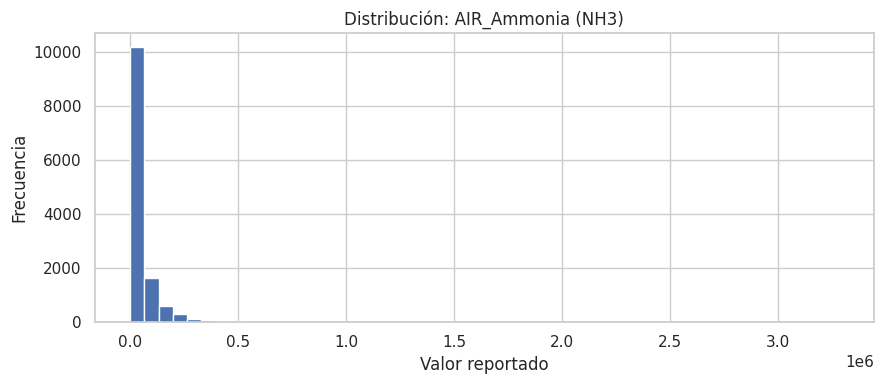

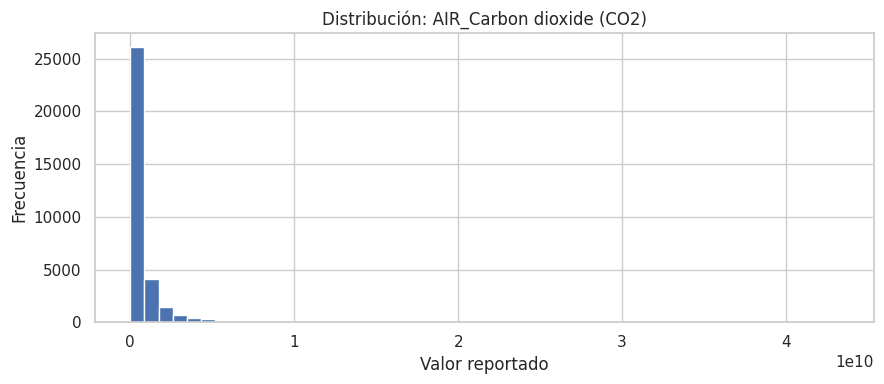

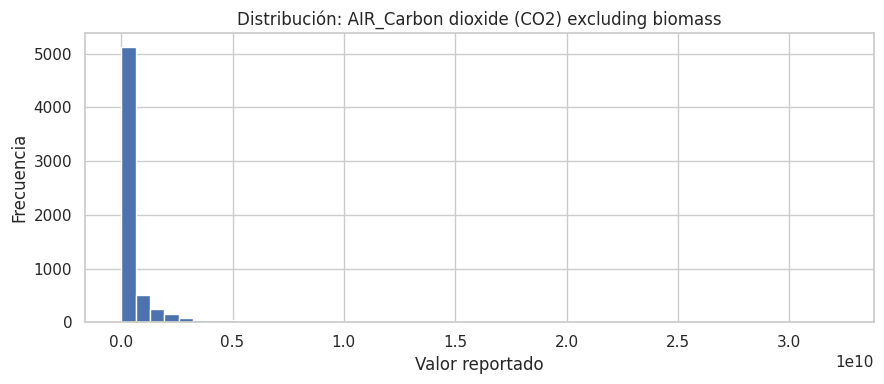

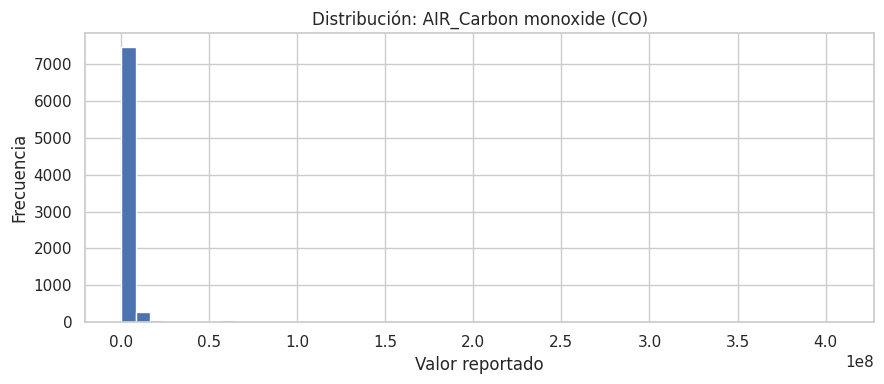

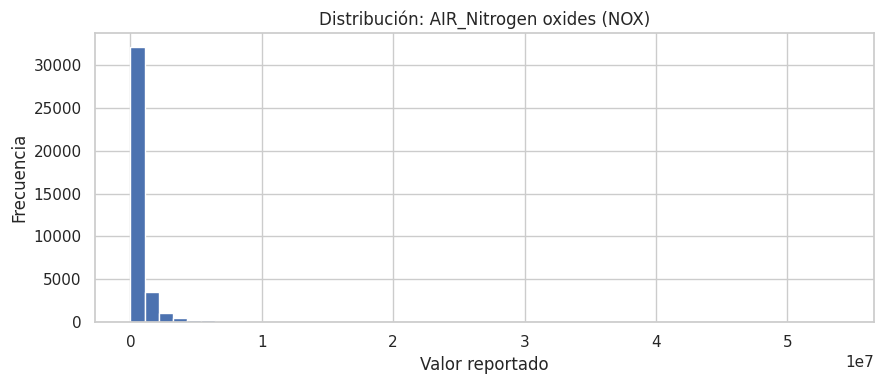

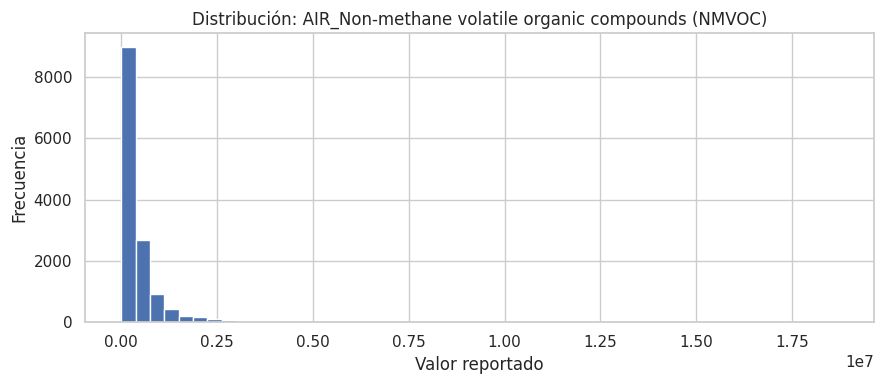

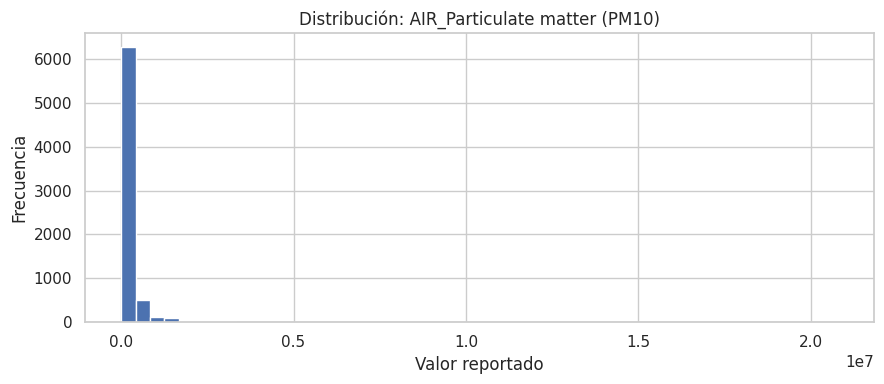

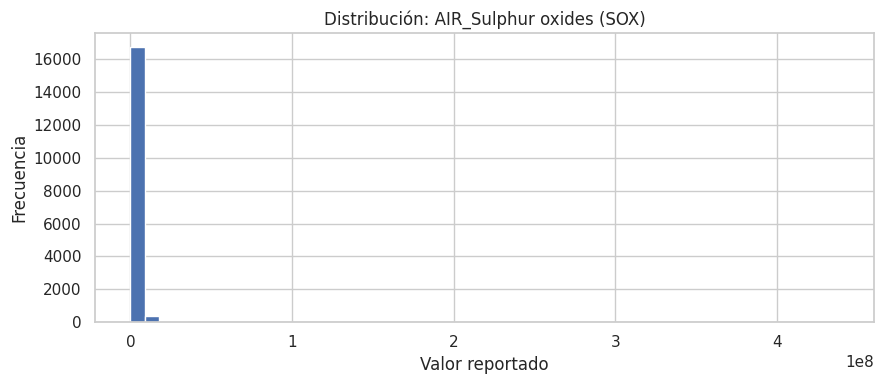

In [ ]:
# 1.4 Distribución de una selección de contaminantes atmosféricos
principales_air = [
    c for c in AIR_COLS
    if any(k in c.upper() for k in ["CO2", "NOX", "SOX", "PM10", "NMVOC", "NH3"])
]

air_plot = df_merged[principales_air].copy()

for c in principales_air:
    plt.figure(figsize=(9, 4))
    plt.hist(air_plot[c].dropna(), bins=50)
    plt.title(f"Distribución: {c}")
    plt.xlabel("Valor reportado")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


**Hallazgos principales de distribución de contaminantes atmosféricos:**

- Todos los contaminantes muestran una distribución fuertemente asimétrica
  hacia la derecha en escala original.  La gran mayoría de instalaciones
  se concentran en valores bajos, con una cola larga de pocas instalaciones
  con emisiones muy elevadas.
- Este patrón es consistente en todos los contaminantes analizados
  (CO₂, NOX, SOX, PM10, NMVOC, NH₃) y confirma la necesidad de aplicar
  una transformación logarítmica antes de entrenar los modelos predictivos.
- NOX y CO₂ son los que presentan valores máximos más extremos por lo que las  grandes centrales eléctricas de carbón son las que dominan
las emisiones de estos contaminantes en Europa.
- NH₃ muestra una distribución algo menos extrema que el resto.

# 2.- Distribución de instalaciones por país y sector industrial

**Regla metodológica:** para contar instalaciones se utiliza `FacilityInspireId.nunique()`, no el número bruto de filas.

In [ ]:
# 2.1 Instalaciones únicas por país
inst_pais = (
    df_merged.groupby("countryName")["FacilityInspireId"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index(name="instalaciones")
)

display(inst_pais)

,countryName,instalaciones
0,Spain,1452
1,United Kingdom,1353
2,France,1267
3,Germany,1210
4,Italy,1050
5,Poland,692
6,Romania,476
7,Netherlands,367
8,Belgium,348
9,Finland,315


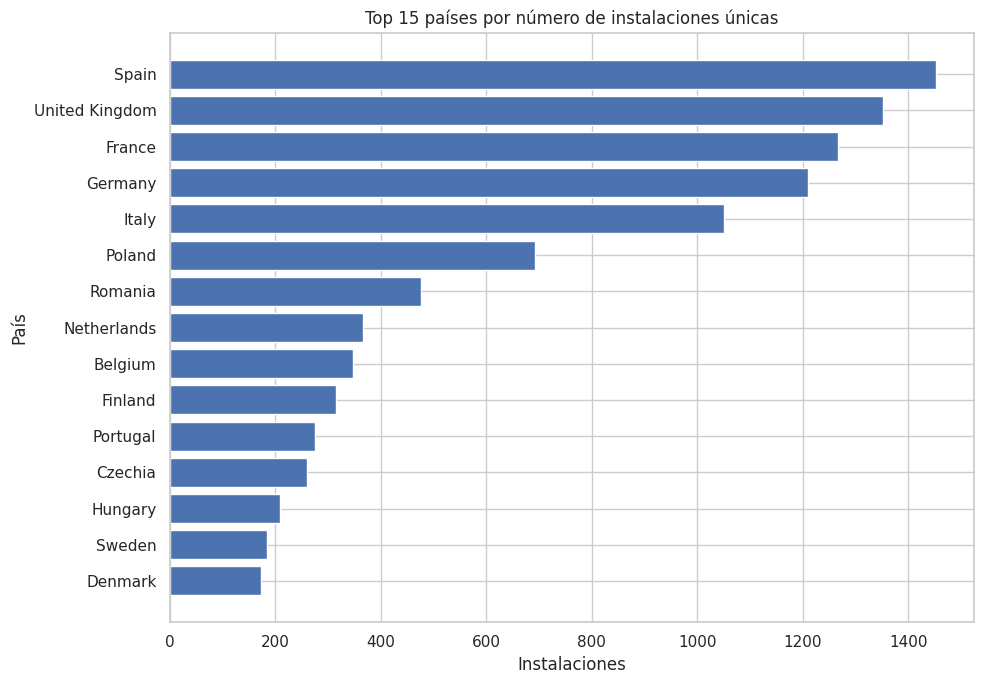

In [ ]:
# 2.2 Visualización: top 15 países por instalaciones
top_paises = inst_pais.head(15).sort_values("instalaciones")

plt.figure(figsize=(10, 7))
plt.barh(top_paises["countryName"], top_paises["instalaciones"])
plt.title("Top 15 países por número de instalaciones únicas")
plt.xlabel("Instalaciones")
plt.ylabel("País")
plt.tight_layout()
plt.show()

**Análisis de distribución por país**:

- España lidera el número de instalaciones industriales registradas (1.452),
  seguida de cerca por Reino Unido (1.353), Francia (1.267) y Alemania (1.210).
  Los cinco países más grandes concentran más del 60% de todas las instalaciones del dataset.
- Hay una diferencia muy notable entre los países grandes y los pequeños:
  Malta (9 instalaciones) e Islandia (6) tienen una presencia marginal,
  lo que refleja tanto el tamaño de su economía como su estructura industrial.
- Países con tradición industrial pesada como Polonia (692) y Rumanía (476)
  tienen una presencia significativa, debido a su base industrial heredada de la era soviética.
- El Reino Unido aparece con 1.353 instalaciones a pesar de haber abandonado
  la UE en 2020.

In [ ]:
# 3.3 Instalaciones únicas por sector
inst_sector = (
    df_merged.groupby("EPRTR_SectorName")["FacilityInspireId"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index(name="instalaciones")
)

display(inst_sector)

,EPRTR_SectorName,instalaciones
0,Waste and wastewater management,1996
1,Energy sector,1974
2,Intensive livestock production and aquaculture,1603
3,Mineral industry,1372
4,Chemical industry,1089
5,Production and processing of metals,1025
6,Other activities,647
7,Animal and vegetable products from the food an...,636
8,Paper and wood production and processing,446


In [ ]:
# 3.4 Instalaciones únicas por país y sector
pais_sector = (
    df_merged.groupby(["countryName", "EPRTR_SectorName"])["FacilityInspireId"]
      .nunique()
      .reset_index(name="instalaciones")
)

pivot_pais_sector = pais_sector.pivot_table(
    index="countryName",
    columns="EPRTR_SectorName",
    values="instalaciones",
    fill_value=0
)

display(pivot_pais_sector)

EPRTR_SectorName,Animal and vegetable products from the food and beverage sector,Chemical industry,Energy sector,Intensive livestock production and aquaculture,Mineral industry,Other activities,Paper and wood production and processing,Production and processing of metals,Waste and wastewater management
countryName,,,,,,,,,
Austria,3.000,9.000,27.000,0.000,15.000,8.000,19.000,14.000,19.000
Belgium,25.000,92.000,40.000,20.000,48.000,25.000,13.000,43.000,42.000
Bulgaria,2.000,4.000,24.000,9.000,16.000,4.000,5.000,8.000,8.000
Croatia,3.000,1.000,11.000,0.000,9.000,0.000,3.000,3.000,0.000
Cyprus,0.000,0.000,3.000,12.000,2.000,0.000,0.000,1.000,2.000
Czechia,16.000,27.000,70.000,43.000,28.000,12.000,6.000,35.000,24.000
Denmark,15.000,22.000,39.000,0.000,11.000,9.000,4.000,16.000,58.000
Estonia,0.000,2.000,18.000,7.000,7.000,1.000,2.000,2.000,7.000
Finland,4.000,19.000,82.000,68.000,19.000,12.000,31.000,14.000,66.000


**Análisis de distribución por sector**:

- Los sectores más representados en número de instalaciones son gestión
  de residuos (1.996) y sector energético (1.974). La Ganadería intensiva ocupa el tercer puesto (1.603 instalaciones).
- El sector de Papel y madera es el menos representado (446 instalaciones)
  junto con Alimentación (636).
- La tabla cruzada país-sector revela patrones industriales nacionales
  interesantes: España destaca en Ganadería intensiva, Alemania en
  Sector energético y Gestión de residuos, y Francia en Industria mineral.

In [ ]:
# 2.5 Actividades principales del Anexo I
actividad = (
    df_merged.groupby("EPRTRAnnexIMainActivity")["FacilityInspireId"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index(name="instalaciones")
)

display(actividad.head(20))

,EPRTRAnnexIMainActivity,instalaciones
0,1(c),1766
1,5(d),996
2,7(a)(ii),631
3,9(c),562
4,5(b),433
5,7(a)(i),418
6,3(e),340
7,6(b),334
8,7(a),316
9,3(g),297


In [ ]:
# Ver qué sector corresponde a cada actividad
df_merged.groupby(['EPRTRAnnexIMainActivity', 'EPRTR_SectorName'])\
         ['FacilityInspireId'].nunique()\
         .reset_index()\
         .sort_values('FacilityInspireId', ascending=False)\
         .head(20)

,EPRTRAnnexIMainActivity,EPRTR_SectorName,FacilityInspireId
2,1(c),Energy sector,1766
51,5(d),Waste and wastewater management,996
60,7(a)(ii),Intensive livestock production and aquaculture,631
70,9(c),Other activities,562
49,5(b),Waste and wastewater management,433
59,7(a)(i),Intensive livestock production and aquaculture,418
23,3(e),Mineral industry,340
56,6(b),Paper and wood production and processing,334
58,7(a),Intensive livestock production and aquaculture,316
25,3(g),Mineral industry,297


**Análisis de actividades principales**

- El dataset cubre 73 actividades distintas del Anexo I del dataset de
  E-PRTR, aunque las 20 primeras concentran la gran mayoría de instalaciones.
- La actividad más frecuente es 1(c): instalaciones de combustión del
  sector energético, con 1.766 instalaciones únicas.
- La gestión de residuos domina con varias actividades entre las más
  frecuentes: 5(d) vertederos (996), 5(b) instalaciones de eliminación
  (433) y 5(a) y 5(f) con más de 170 instalaciones cada una.
- La ganadería intensiva aparece fragmentada en cuatro subactividades
  (7(a), 7(a)(i), 7(a)(ii), 7(a)(iii)) que juntas suman 1.591 instalaciones, convirtiéndola en el sector más numeroso.


# 3.- Distribución y escala de contaminantes principales

El análisis principal se realizará con `air_long`, y se complementará con agua, residuos y transferencias.

**Importante:** los valores de contaminantes diferentes no se suman indiscriminadamente porque pueden tener unidades y escalas distintas.

In [ ]:
# 3.1 Número de instalaciones que reportan cada contaminante atmosférico
air_contaminants = (
    air_long.dropna(subset=["valor"])
    .groupby("contaminante")
    .agg(
        instalaciones=("FacilityInspireId", "nunique"),
        observaciones=("valor", "count"),
        emision_media=("valor", "mean"),
        emision_mediana=("valor", "median"),
        emision_total=("valor", "sum")
    )
    .sort_values("emision_total", ascending=False)
    .reset_index()
)

display(air_contaminants)

,contaminante,instalaciones,observaciones,emision_media,emision_mediana,emision_total
0,Carbon dioxide (CO2),3343,33842,"852,208,110.259","319,000,000.000","28,840,426,867,394.449"
1,Carbon dioxide (CO2) excluding biomass,777,6373,"673,884,454.828","168,000,000.000","4,294,665,630,617.470"
2,Carbon monoxide (CO),1198,8223,"6,085,910.143","1,140,000.000","50,044,439,103.950"
3,Sulphur oxides (SOX),2103,17416,"2,176,431.529","485,000.000","37,904,731,516.914"
4,Nitrogen oxides (NOX),4340,38496,"843,496.794","311,000.000","32,471,252,563.358"
5,Methane (CH4),1998,13416,"1,548,092.131","407,000.000","20,769,204,035.586"
6,Non-methane volatile organic compounds (NMVOC),1905,13832,"503,177.060","255,000.000","6,959,945,090.464"
7,Particulate matter (PM10),1258,7160,"257,626.106","106,142.500","1,844,602,918.973"
8,Nitrous oxide (N2O),1291,9024,"117,832.689","25,000.000","1,063,322,188.010"
9,Ammonia (NH3),2523,13195,"66,535.892","30,200.000","877,941,090.053"


**Análisis de contaminantes atmosféricos**:

- CO₂ domina las emisiones totales con 28,8 billones de Kg.
- NOX es el contaminante más reportado con 4.340 instalaciones únicas.
- Hay una gran diferencia entre media y mediana en todos los contaminantes.
- El mercurio tiene la menor emisión total (423.492 kg) pero lo reportan 1.139 instalaciones, su impacto es grande ya que tiene efectos graves incluso en cantidades pequeñas.
- Los HCFCs (compuestos fluorados usados en refrigeración) tienen la mediana más baja (42.1 kg7año).

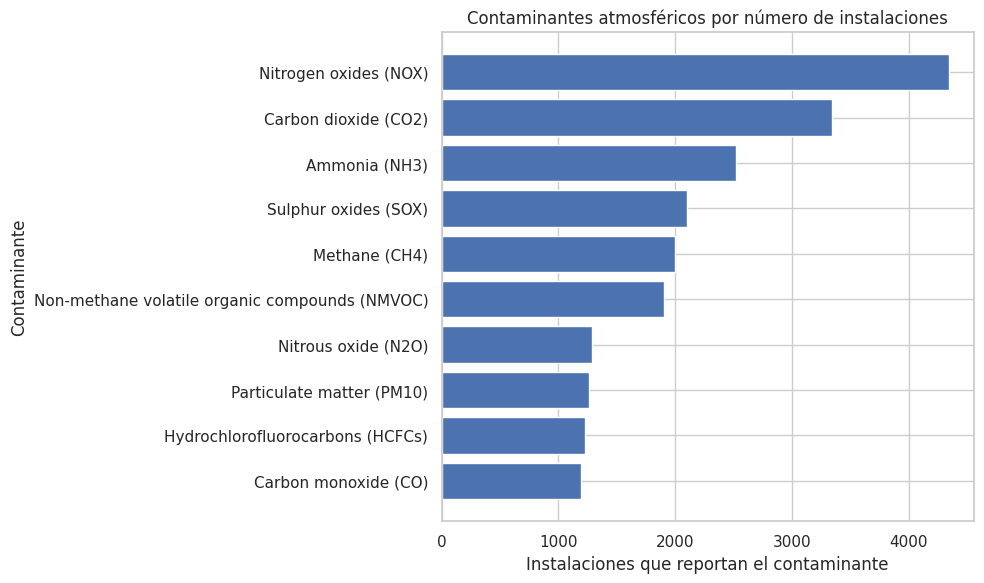

In [ ]:
# 3.2 Top contaminantes por número de instalaciones
top_air_inst = (
    air_contaminants
    .sort_values("instalaciones", ascending=False)
    .head(10)
    .sort_values("instalaciones")
)

plt.figure(figsize=(10, 6))
plt.barh(top_air_inst["contaminante"], top_air_inst["instalaciones"])
plt.title("Contaminantes atmosféricos por número de instalaciones")
plt.xlabel("Instalaciones que reportan el contaminante")
plt.ylabel("Contaminante")
plt.tight_layout()
plt.show()

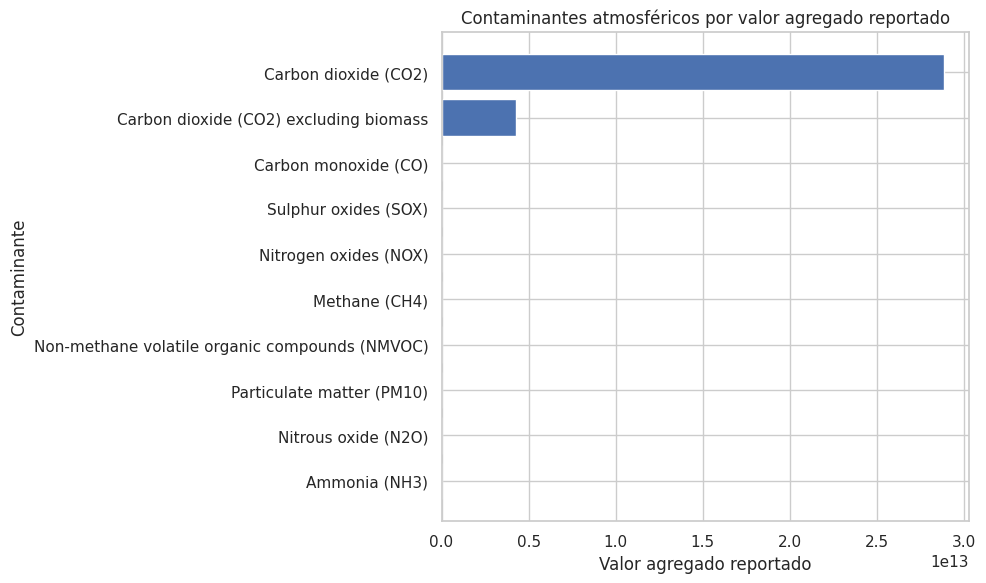

In [ ]:
# 3.3 Top contaminantes por volumen reportado
top_air_total = (
    air_contaminants
    .sort_values("emision_total", ascending=False)
    .head(10)
    .sort_values("emision_total")
)

plt.figure(figsize=(10, 6))
plt.barh(top_air_total["contaminante"], top_air_total["emision_total"])
plt.title("Contaminantes atmosféricos por valor agregado reportado")
plt.xlabel("Valor agregado reportado")
plt.ylabel("Contaminante")
plt.tight_layout()
plt.show()

**Contaminantes por volumen reportado**:

- CO₂ es el contaminante dominante.

In [ ]:
# 3.4 Distribución por medio ambiental
medio_contaminante = (
    ambiental_long.dropna(subset=["valor"])
    .groupby(["medio", "contaminante"])
    .agg(
        observaciones=("valor", "count"),
        instalaciones=("FacilityInspireId", "nunique"),
        total_reportado=("valor", "sum")
    )
    .reset_index()
)

display(medio_contaminante)


,medio,contaminante,observaciones,instalaciones,total_reportado
0,Agua,Arsenic and compounds (as As),4926,841,"631,435.855"
1,Agua,Chlorides (as total Cl),3855,497,"216,270,849,738.330"
2,Agua,Copper and compounds (as Cu),4581,798,"2,163,692.090"
3,Agua,Fluorides (as total F),3108,433,"105,258,221.456"
4,Agua,Lead and compounds (as Pb),3328,682,"849,438.549"
5,Agua,Nickel and compounds (as Ni),6537,1040,"1,710,057.720"
6,Agua,Total nitrogen,4503,610,"1,600,121,372.933"
7,Agua,Total organic carbon(as total C or COD/3) (TOC),5858,791,"3,625,321,095.396"
8,Agua,Total phosphorus,3161,508,"122,411,921.944"
9,Agua,Zinc and compounds (as Zn),7422,1133,"11,454,149.863"


**Distribución por medio ambiental:**

- El aire concentra la mayor magnitud de emisiones totales,
  dominado por CO₂ (28,8 billones de kg) y NOX (32,5 billones de kg).
- En agua, los cloruros destacan con 216 billones de kg.
- En residuos, la recuperación de no peligrosos (Recovery_NONHW)
  supera en volumen a la eliminación (Disposal_NONHW). Esto es
  señal positiva de economía circular en la industria europea.
- Las transferencias son el medio con menor volumen y cobertura
  menos del 4% de instalaciones las declaran, y el TOC
  (carbono orgánico total) es el contaminante transferido
  más significativo con 2,4 billones de kg.

In [ ]:
# 3.5 Escala relativa dentro de cada contaminante
# Normalización Min-Max para comparar perfiles, no para sumar magnitudes físicas.
scaler = MinMaxScaler()

air_positive = air_long.dropna(subset=["valor"]).copy()

air_positive["valor_normalizado"] = (
    air_positive.groupby("contaminante")["valor"]
    .transform(
        lambda x: MinMaxScaler().fit_transform(x.to_numpy().reshape(-1, 1)).ravel()
        if x.nunique() > 1 else 0
    )
)

display(
    air_positive[
        ["reportingYear", "countryName", "EPRTR_SectorName",
         "contaminante", "valor", "valor_normalizado"]
    ].head()
)

,reportingYear,countryName,EPRTR_SectorName,contaminante,valor,valor_normalizado
232,2014,Austria,Mineral industry,Ammonia (NH3),"27,200.000",0.008
234,2016,Austria,Mineral industry,Ammonia (NH3),"11,200.000",0.003
236,2018,Austria,Mineral industry,Ammonia (NH3),"12,900.000",0.004
237,2019,Austria,Mineral industry,Ammonia (NH3),"26,000.000",0.008
238,2020,Austria,Mineral industry,Ammonia (NH3),"11,200.000",0.003


**Normalización Min-Max por contaminante:**

- La normalización se aplica dentro de cada contaminante por separado y nos
  permite comparar el perfil relativo de emisiones entre instalaciones
  sin mezclar unidades ni magnitudes distintas.
- Un valor normalizado de 0 indica la instalación con menor emisión
  de ese contaminante y un valor de 1 indica la instalación con mayor emisión.
- Esta transformación es útil para comparar perfiles industriales
  pero no para sumar magnitudes físicas entre contaminantes distintos.

# 4. Evolución temporal agregada de emisiones (2007 - 2024)

Se utilizará `reportingYear` como eje temporal. El análisis se realiza por contaminante y sector, evitando crear una suma físicamente no interpretable entre sustancias diferentes.

In [ ]:
# 4.1 Evolución anual de contaminantes atmosféricos
air_year = (
    air_long.dropna(subset=["valor"])
    .groupby(["reportingYear", "contaminante"])["valor"]
    .sum()
    .reset_index()
)

display(air_year.head(20))

,reportingYear,contaminante,valor
0,2007,Ammonia (NH3),"53,980,800.000"
1,2007,Carbon dioxide (CO2),"2,050,285,000,000.000"
2,2007,Carbon dioxide (CO2) excluding biomass,"110,617,473,000.000"
3,2007,Carbon monoxide (CO),"3,779,192,000.000"
4,2007,Chlorine and inorganic compounds (as HCl),"37,159,300.000"
5,2007,Hydrochlorofluorocarbons (HCFCs),"1,023,201.290"
6,2007,Mercury and compounds (as Hg),"35,826.700"
7,2007,Methane (CH4),"1,373,232,000.000"
8,2007,Nickel and compounds (as Ni),"351,338.700"
9,2007,Nitrogen oxides (NOX),"3,083,764,000.000"


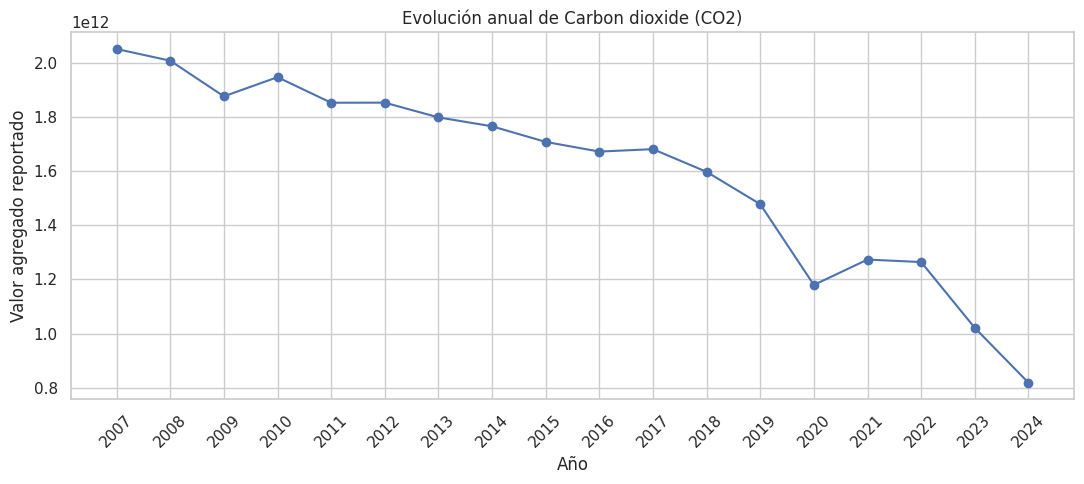

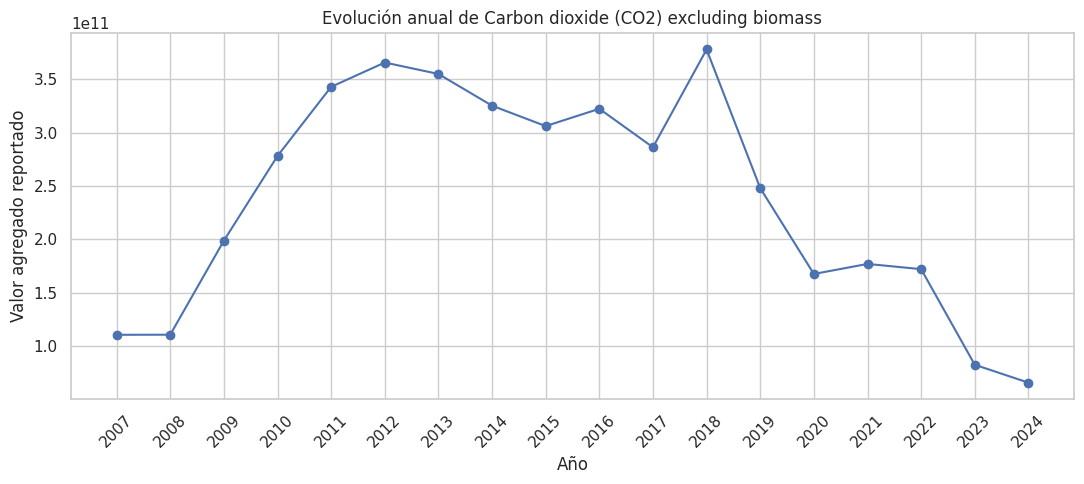

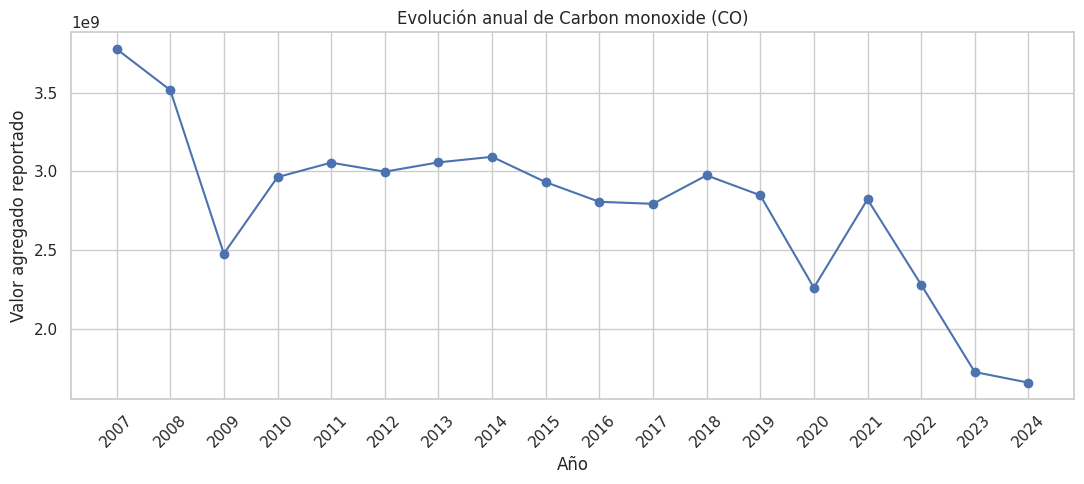

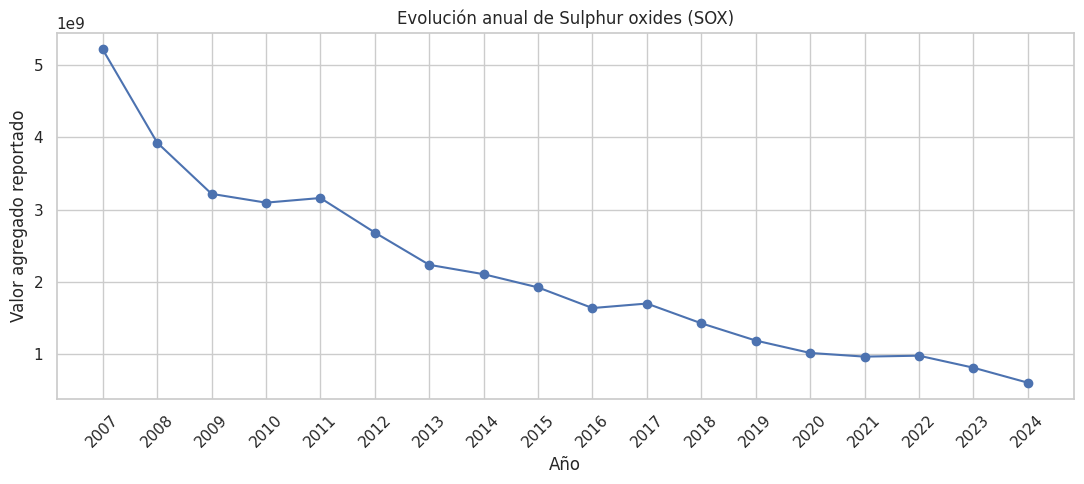

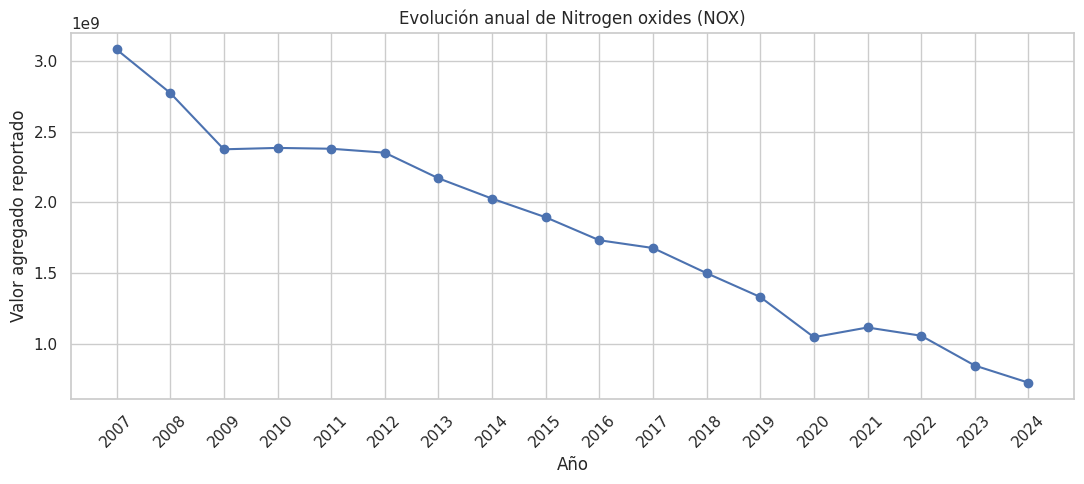

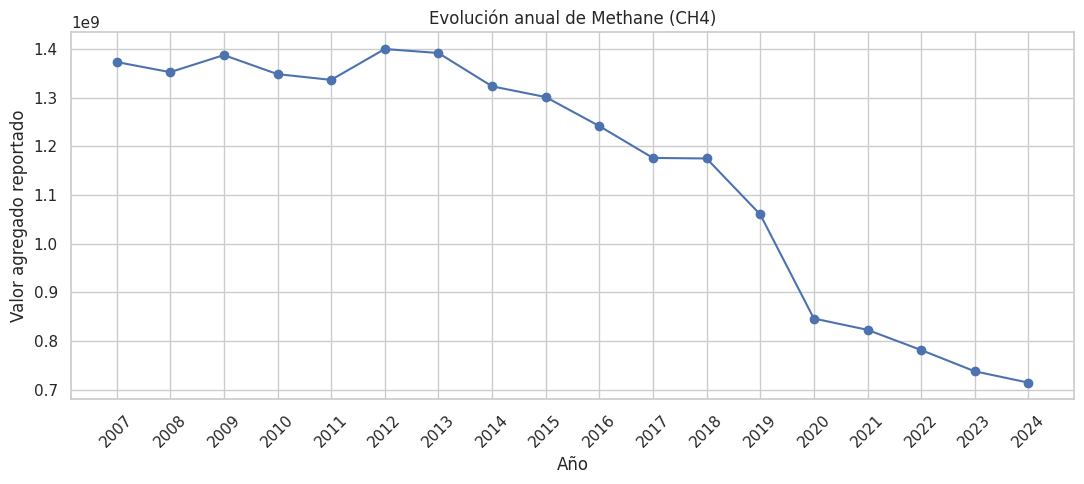

In [ ]:
# 4.2 Evolución de principales contaminantes atmosféricos
top_contaminants = (
    air_contaminants
    .sort_values("emision_total", ascending=False)
    .head(6)["contaminante"]
    .tolist()
)

for contaminante in top_contaminants:
    serie = air_year[air_year["contaminante"] == contaminante]
    plt.figure(figsize=(11, 5))
    plt.plot(serie["reportingYear"], serie["valor"], marker="o")
    plt.title(f"Evolución anual de {contaminante}")
    plt.xlabel("Año")
    plt.ylabel("Valor agregado reportado")
    plt.xticks(sorted(df_merged["reportingYear"].unique()), rotation=45)
    plt.tight_layout()
    plt.show()

**Análisis de evolución temporal de emisiones atmosféricas (2007-2024):**

- CO₂ total: tendencia bajista sostenida a lo largo del periodo,
con una caída especialmente notable a partir de 2020, coherente
con el impacto de la pandemia COVID-19 sobre la actividad industrial
y la aceleración de las políticas de descarbonización del Pacto Verde Europeo.

- CO₂ excluyendo biomasa: sigue la misma tendencia bajista que el CO₂ total,
con un repunte puntual en 2018 seguido de nueva reducción.
Esta variable excluye las emisiones procedentes de la quema de biomasa
(madera, residuos agrícolas, biogás) que se consideran neutras en carbono
según la contabilidad climática europea, al asumir que el CO₂ liberado
fue previamente capturado por la vegetación.

- SOX (óxidos de azufre): es el contaminante con la reducción más significativa
del periodo con parte de niveles muy elevados en 2007 y cae de forma muy
pronunciada hasta 2024. Esta reducción refleja el impacto de la Directiva
de Grandes Instalaciones de Combustión y las sucesivas revisiones de emisiones industriales, que impusieron límites cada vez más
estrictos a las emisiones de dióxido de azufre.

- NOX (óxidos de nitrógeno): sigue un patrón similar al SOX:  parte alta
en 2007 y muestra una reducción clara y progresiva hasta 2024, impulsada
por las mismas directivas regulatorias y la renovación tecnológica
de la UE.

- Metano (CH4): muestra una evolución más tranquila con niveles relativamente
estables entre 2007 y 2013, seguidos de una reducción progresiva que
se acelera a partir de 2020. La caída post-2020 es coherente con
la reducción general de actividad industrial y el mayor control
de fugas en instalaciones de gestión de residuos y ganadería.

**Conclusión**: Todos los contaminantes muestran una caída notable a partir del 2020, debido a la combinación del COVID y la actividad industrial así como la intensificación de políticas medioambientales del Pacto Verde. Hay que destacar que los datos del 2023 y 2024 muestran valores menores por retrasos en consolidar los informes por parte de la EEA (European Environment Agency):

In [ ]:
# 4.3 Variación interanual por contaminante
air_yoy = air_year.sort_values(["contaminante", "reportingYear"]).copy()
air_yoy["variacion_interanual_%"] = (
    air_yoy.groupby("contaminante")["valor"]
    .pct_change() * 100
)

display(air_yoy)

,reportingYear,contaminante,valor,variacion_interanual_%
0,2007,Ammonia (NH3),"53,980,800.000",NaN
15,2008,Ammonia (NH3),"53,288,000.000",-1.283
30,2009,Ammonia (NH3),"44,876,000.000",-15.786
45,2010,Ammonia (NH3),"44,694,100.000",-0.405
60,2011,Ammonia (NH3),"46,137,800.000",3.230
...,...,...,...,...
209,2020,Zinc and compounds (as Zn),"464,809.027",-28.418
224,2021,Zinc and compounds (as Zn),"540,075.199",16.193
239,2022,Zinc and compounds (as Zn),"579,002.052",7.208
254,2023,Zinc and compounds (as Zn),"472,046.890",-18.472


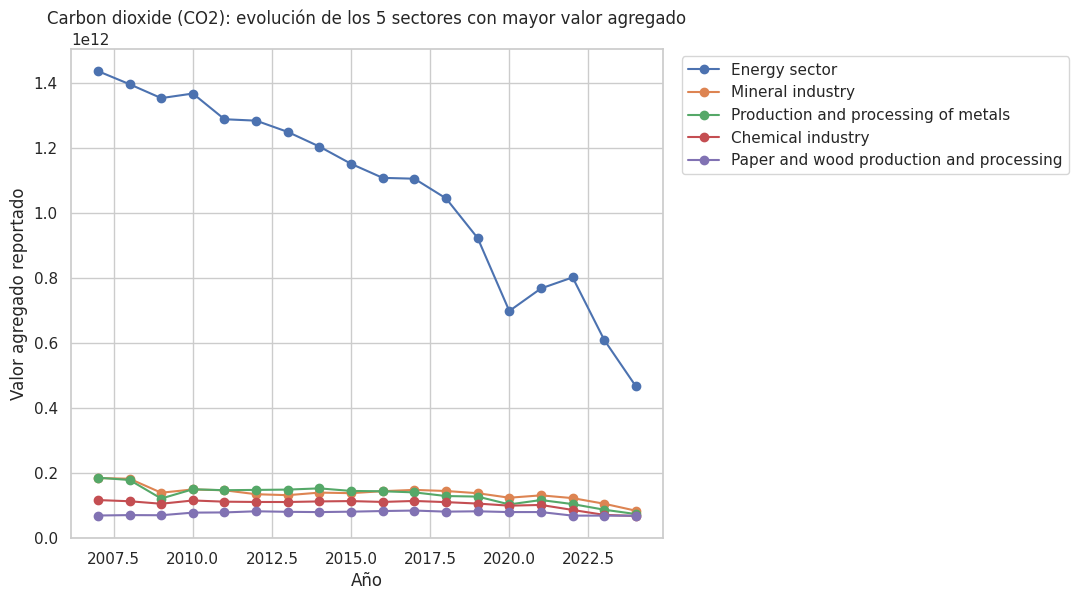

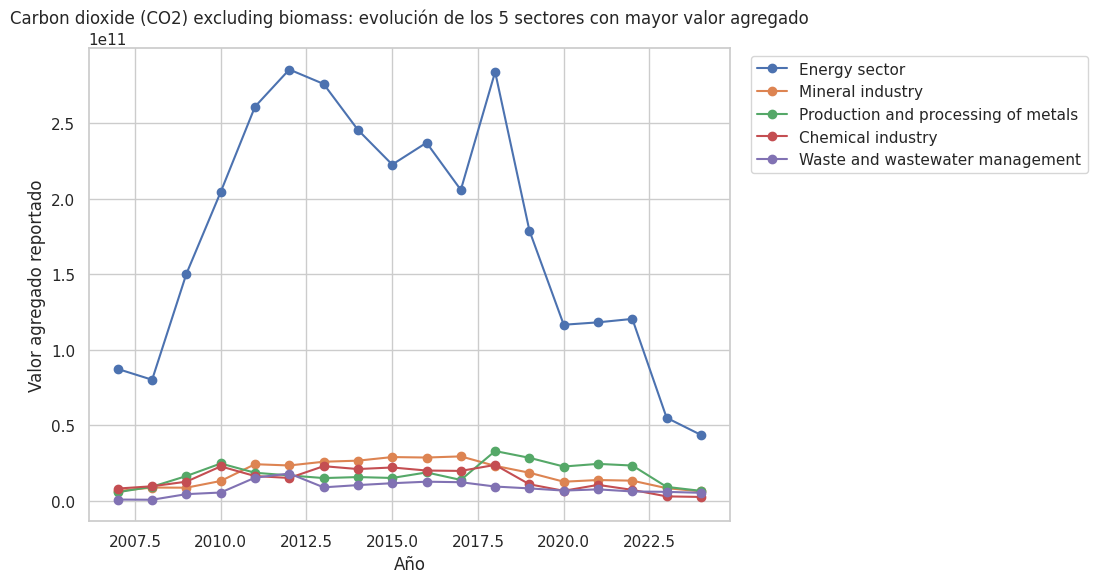

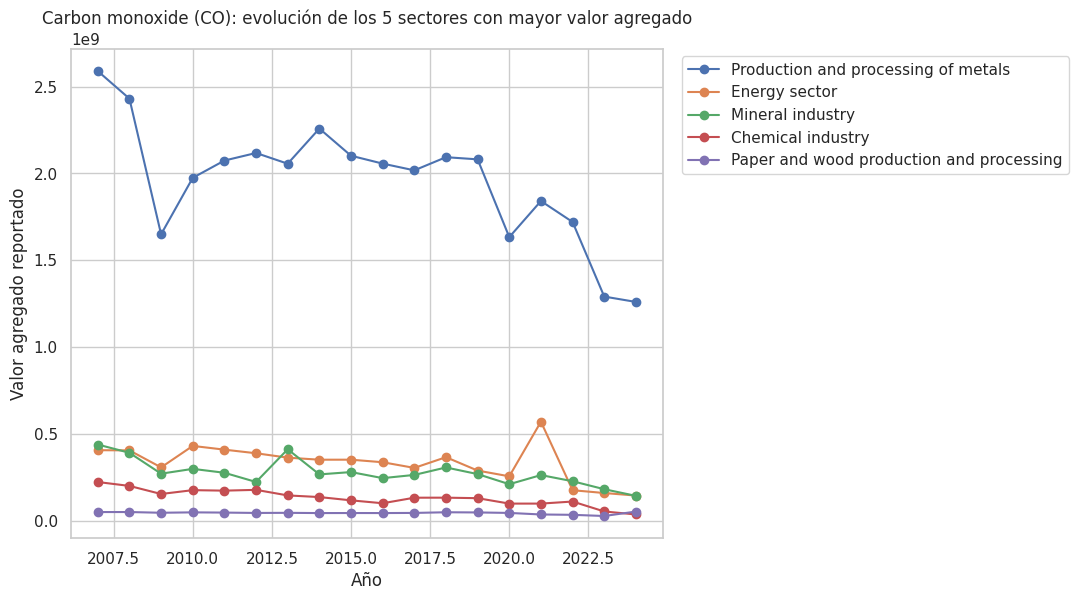

In [ ]:
# 4.4 Evolución por sector para los principales contaminantes
air_sector_year = (
    air_long.dropna(subset=["valor"])
    .groupby(["reportingYear", "EPRTR_SectorName", "contaminante"])["valor"]
    .sum()
    .reset_index()
)

for contaminante in top_contaminants[:3]:
    tmp = air_sector_year[
        air_sector_year["contaminante"] == contaminante
    ]

    sectores = (
        tmp.groupby("EPRTR_SectorName")["valor"]
        .sum()
        .nlargest(5)
        .index
    )

    plt.figure(figsize=(11, 6))
    for sector in sectores:
        s = tmp[tmp["EPRTR_SectorName"] == sector]
        plt.plot(s["reportingYear"], s["valor"], marker="o", label=sector)

    plt.title(f"{contaminante}: evolución de los 5 sectores con mayor valor agregado")
    plt.xlabel("Año")
    plt.ylabel("Valor agregado reportado")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

** Evolución de CO₂ por sector:**


- El sector energético domina de forma abrumadora:  las emisiones de CO₂
 (1,4 billones de kg en 2007) son prácticamente 10 veces
  superiores al resto de sectores, que se agrupan en la parte inferior
  del gráfico casi indistinguibles entre sí.

- La reducción del sector energético es la más pronunciada — pasa de
  1,4 billones de kg en 2008 a menos de 0,5 billones en 2024,
  una reducción de más del 65% en el periodo. Esta caída refleja
  la transición energética europea: cierre de centrales de carbón,
  expansión de renovables y mejora de la eficiencia energética.

- Caída brusca en 2020: es visible en todos los sectores,
  debido a la época de la pandemia.

- El resto de sectores (Minerales, Metales, Química, Papel)
  muestran niveles muy similares entre sí y una reducción
  moderada y progresiva a lo largo del periodo.

**CO₂ excluyendo biomasa por sector:**

- El sector energético domina también en CO₂ excluyendo biomasa,
  pero con un patrón distinto:  muestra un
  repunte pronunciado entre 2009 y 2012, seguido de una caída
  hasta 2015, un segundo repunte en 2018 y una caída muy brusca
  a partir de 2019 hasta 2024.

- Este patrón irregular nos indica que los repuntes coinciden con periodos de   mayor uso de combustibles fósiles no renovables, mientras que la caída
  a partir del 2019 refleja la aceleración del cierre de centrales de carbón.

- El resto de sectores (Minerales, Metales, Química, Residuos)
  muestran niveles muy bajos y estables.


**Monóxido de carbono (CO) por sector:**

- A diferencia del CO₂, el sector que domina las emisiones de CO
  es la Producción y transformación de metales,  muy por encima
  del resto, con valores entre 1,5 y 2,6 billones de kg/año.

- Esto es coherente con los procesos metalúrgicos (altos hornos,
  fundiciones) que generan grandes cantidades de CO como
  subproducto de la reducción del mineral de hierro.

- El sector energético ocupa el segundo puesto pero a gran distancia,
  con un pico anómalo en 2021 — posiblemente relacionado con
  la reactivación industrial post-COVID y el repunte del carbón
  durante la crisis energética de ese año.
  
- Todos los sectores muestran una tendencia bajista a partir de
  2022, con caídas más pronunciadas en 2023-2024.

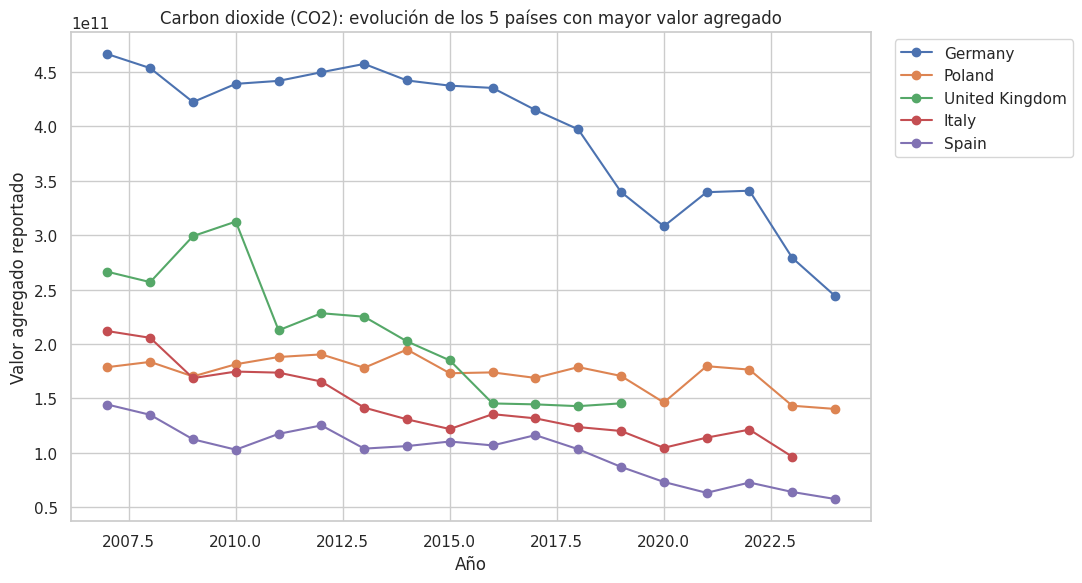

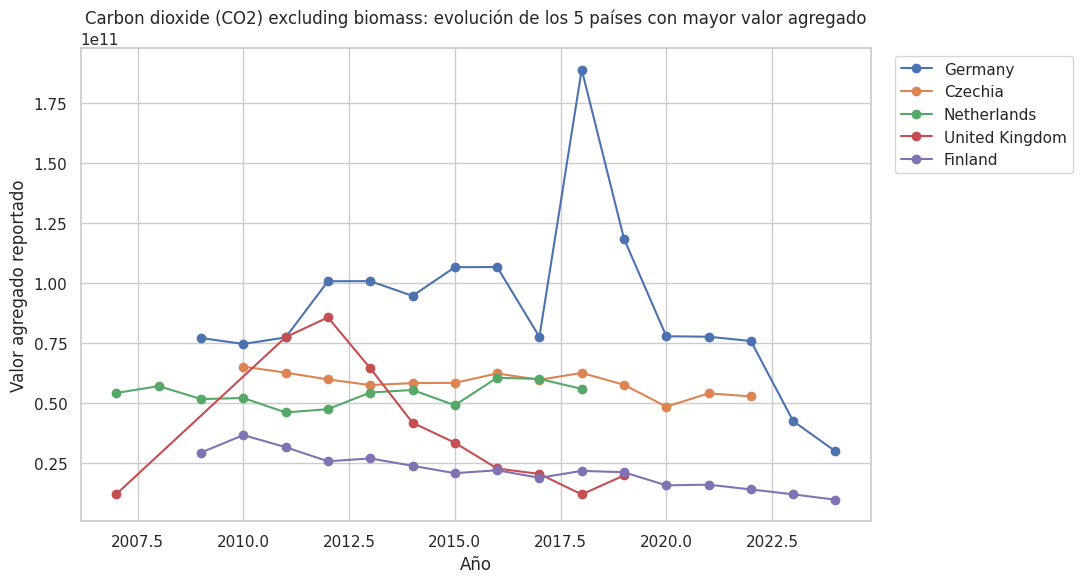

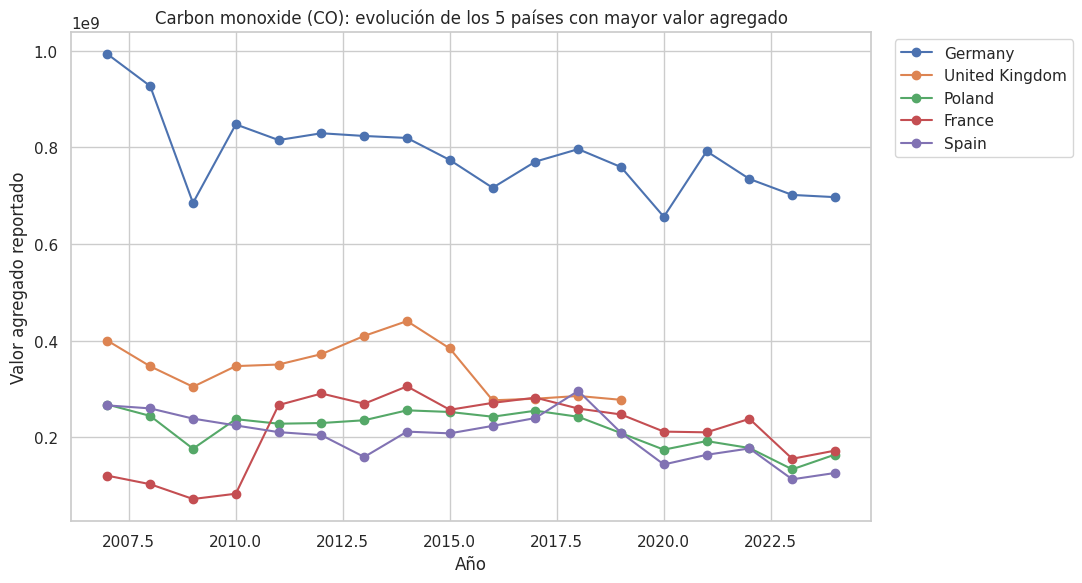

In [ ]:
# 5.5 Evolución por país para los principales contaminantes
air_country_year = (
    air_long.dropna(subset=["valor"])
    .groupby(["reportingYear", "countryName", "contaminante"])["valor"]
    .sum()
    .reset_index()
)

for contaminante in top_contaminants[:3]:
    top_countries = (
        air_country_year[
            air_country_year["contaminante"] == contaminante
        ]
        .groupby("countryName")["valor"]
        .sum()
        .nlargest(5)
        .index
    )

    plt.figure(figsize=(11, 6))
    for country in top_countries:
        s = air_country_year[
            (air_country_year["contaminante"] == contaminante) &
            (air_country_year["countryName"] == country)
        ]
        plt.plot(s["reportingYear"], s["valor"], marker="o", label=country)

    plt.title(f"{contaminante}: evolución de los 5 países con mayor valor agregado")
    plt.xlabel("Año")
    plt.ylabel("Valor agregado reportado")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

**Análisis de evolución por país**:

**CO₂ total por país:**
- Alemania lidera con las emisiones de CO₂ de forma muy destacada,
  con valores entre 4,5 y 2,4 billones de kg/año, prácticamente
  dobla al segundo país en todo el periodo. Refleja su gran base
  industrial y su histórica dependencia del carbón.

- Reino Unido muestra la reducción más pronunciada de los 5 países, de 2,6 billones en 2007 a prácticamente converger con Italia
  y España en 2020-2024, reflejando el cierre masivo de centrales
  de carbón y la desindustrialización progresiva.

- Polonia mantiene niveles relativamente estables durante todo
  el periodo, debido a su continuada dependencia del carbón
  como fuente energética principal.

- España muestra la reducción más gradual y constante de los 5,
  llegando a los niveles más bajos del grupo en 2024.

**CO₂ excluyendo biomasa por país:**
- Alemania domina también aquí, con un pico muy pronunciado
  en 2018 que casi duplica sus valores habituales.

- República Checa aparece como segundo país emisor en esta
  categoría (dependencia del carbón para
  generación eléctrica).

- Reino Unido muestra una caída muy pronunciada a partir de
  2010 indicando el cierre de centrales de carbón y la
  transición hacia el gas natural y las renovables.

**Monóxido de carbono (CO) por país:**
- Alemania lidera también las emisiones de CO, con niveles
  entre 0,65 y 1,0 billones de kg/año, mostrando su gran
  industria metalúrgica.

- Reino Unido ocupa el segundo puesto pero con una reducción
  clara y progresiva, mientras que Francia muestra los
  niveles más bajos y estables del grupo.

- A diferencia del CO₂, Polonia** no aparece entre los 5
  mayores emisores de CO. Esto nos confirma que sus altas emisiones
  de CO₂ provienen principalmente de la combustión en centrales
  eléctricas, no de procesos industriales metalúrgicos.

# 5. Visualizaciones geográficas

Se utilizarán las coordenadas `Longitude` y `Latitude` y se mantendrá `FacilityInspireId` como identificador de instalación.

Los mapas se construyen con los registros que poseen ambas coordenadas.

In [ ]:
# 5.1 Dataset geográfico
geo_df = df_merged.dropna(subset=["Latitude", "Longitude"]).copy()

print(f"Registros con coordenadas completas: {len(geo_df):,}")
print(f"Instalaciones georreferenciadas: {geo_df['FacilityInspireId'].nunique():,}")

# Comprobación básica de rangos
print("\nRangos:")
print("Latitud:", geo_df["Latitude"].min(), "a", geo_df["Latitude"].max())
print("Longitud:", geo_df["Longitude"].min(), "a", geo_df["Longitude"].max())

Registros con coordenadas completas: 80,838
Instalaciones georreferenciadas: 10,770

Rangos:
Latitud: -21.32212 a 71.56944
Longitud: -63.08026 a 55.63896


In [ ]:
# 5.2 GeoDataFrame
gdf = gpd.GeoDataFrame(
    geo_df,
    geometry=gpd.points_from_xy(
        geo_df["Longitude"],
        geo_df["Latitude"]
    ),
    crs="EPSG:4326"
)

display(gdf[[
    "FacilityInspireId",
    "facilityName",
    "countryName",
    "EPRTR_SectorName",
    "geometry"
]].head())

,FacilityInspireId,facilityName,countryName,EPRTR_SectorName,geometry
0,AT.CAED/9008390306826.FACILITY,Mondi Neusiedler GmbH & Co KG,Austria,Paper and wood production and processing,POINT (14.75333 48.02278)
1,AT.CAED/9008390306826.FACILITY,Mondi Neusiedler GmbH & Co KG,Austria,Paper and wood production and processing,POINT (14.75333 48.02278)
2,AT.CAED/9008390306826.FACILITY,Mondi Neusiedler GmbH & Co KG,Austria,Paper and wood production and processing,POINT (14.75333 48.02278)
3,AT.CAED/9008390317211.FACILITY,Mondi Neusiedler GmbH & Co KG,Austria,Paper and wood production and processing,POINT (14.82 48.07)
4,AT.CAED/9008390317211.FACILITY,Mondi Neusiedler GmbH & Co KG,Austria,Paper and wood production and processing,POINT (14.82 48.07)


**Configuración geográfica**:

- 80.838 registros tienen coordenadas completas.
  Solo 167 instalaciones carecen de georreferenciación y se excluyen
  de los mapas.
  
- Los rangos de coordenadas confirman la presencia de instalaciones
  en territorios de ultramar europeos (latitudes negativas y longitudes
  extremas) además de Europa continental.

- Cada instalación puede aparecer múltiples veces en el dataset
  (una por año de reporte) — para las visualizaciones geográficas
  se trabaja con instalaciones únicas para evitar duplicar puntos en el mapa.

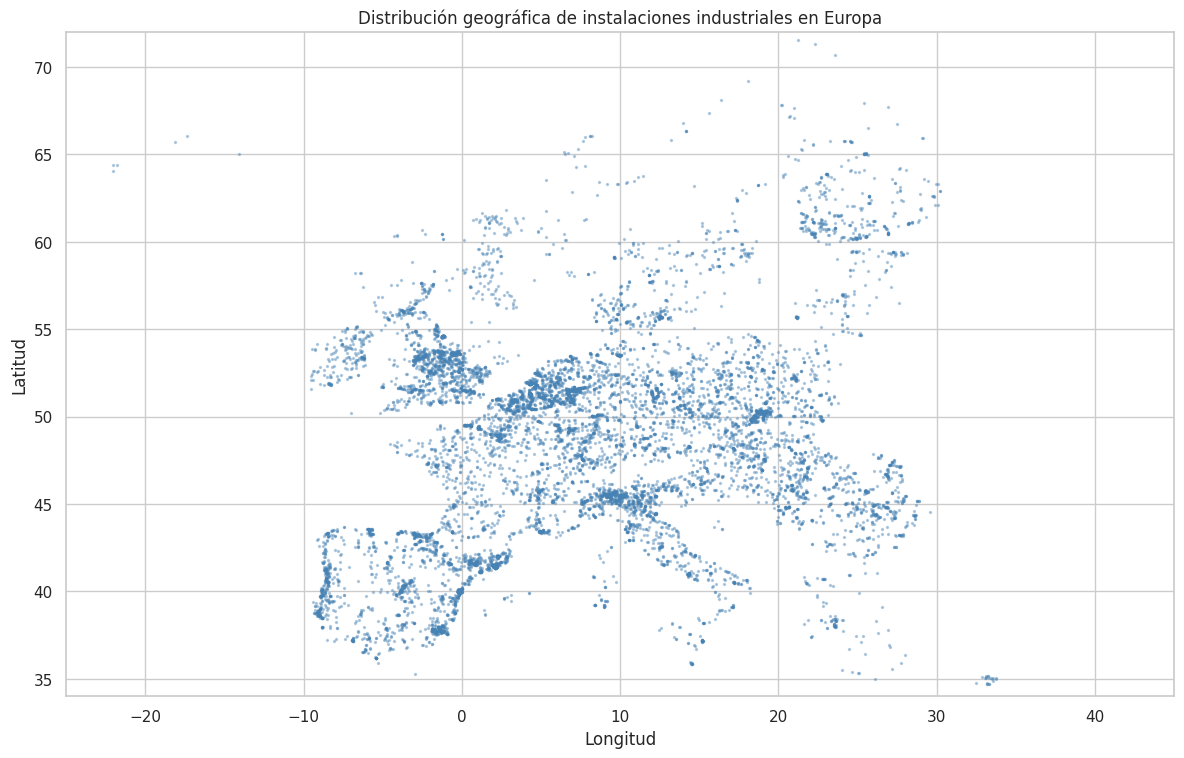

In [ ]:
# 5.3 Mapa estático de instalaciones
fig, ax = plt.subplots(figsize=(12, 8))
gdf_unique = gdf.drop_duplicates(subset=['FacilityInspireId'])
gdf_unique.plot(
    ax=ax,
    markersize=2,
    alpha=0.35,
    color='steelblue'
)
ax.set_xlim(-25, 45)   # longitud Europa
ax.set_ylim(34, 72)    # latitud Europa
ax.set_title("Distribución geográfica de instalaciones industriales en Europa")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
plt.show()

**Distribución geográfica de instalaciones**:

- Las instalaciones se concentran principalmente en Europa central
  y occidental: Alemania, Francia, Reino Unido, Polonia e Italia
  forman el núcleo más denso, puesto que poseen mayor número de
  instalaciones registradas.

- La Península Ibérica, los Países Bajos y el norte de Italia
  muestran alta densidad de puntos indicando su importante
  base industrial y agrícola intensiva.

- Los territorios de ultramar de Estados Miembros quedan fuera de esta visualización por escala y para facilitar su lectura.

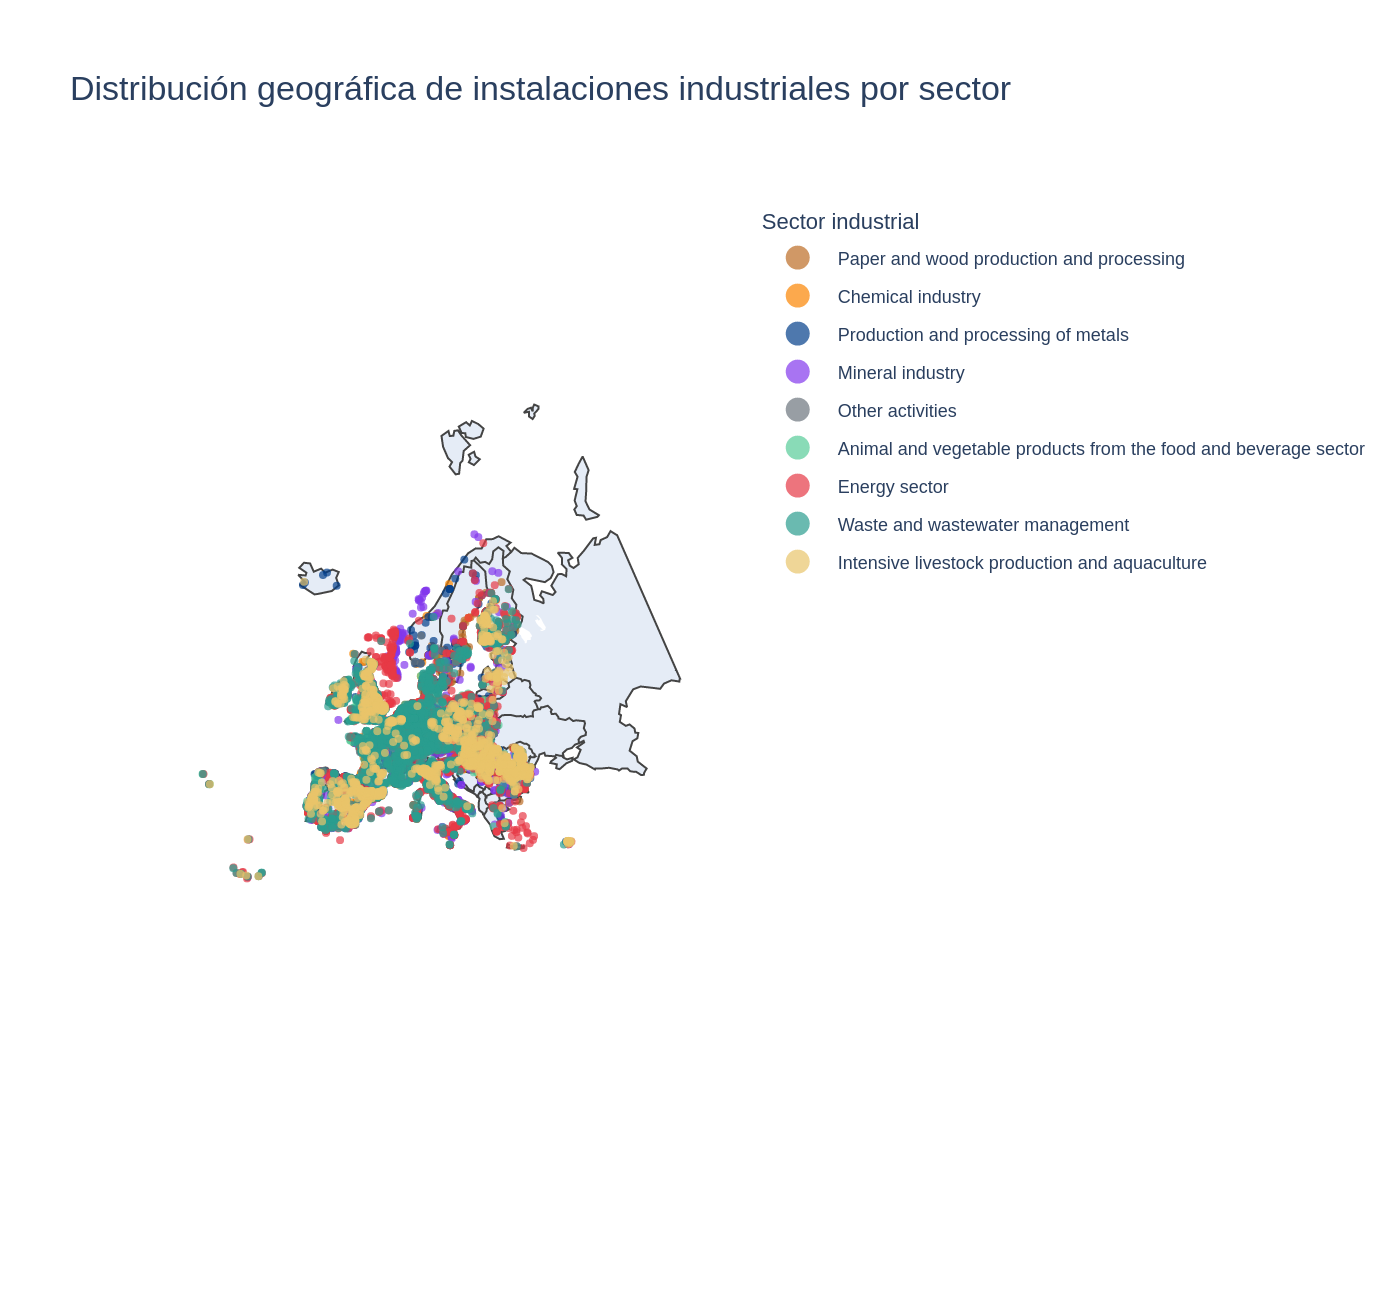

In [ ]:
sector_colors = {
    'Energy sector': '#E63946',
    'Waste and wastewater management': '#2A9D8F',
    'Intensive livestock production and aquaculture': '#E9C46A',
    'Mineral industry': '#8338EC',
    'Chemical industry': '#FB8500',
    'Production and processing of metals': '#023E8A',
    'Other activities': '#6C757D',
    'Animal and vegetable products from the food and beverage sector': '#57CC99',
    'Paper and wood production and processing': '#BC6C25'
}

fig = px.scatter_geo(
    gdf_unique,
    lat='Latitude',
    lon='Longitude',
    color='EPRTR_SectorName',
    hover_name='facilityName',
    hover_data={
        'countryName': True,
        'EPRTR_SectorName': True,
        'Latitude': False,
        'Longitude': False
    },
    scope='europe',
    title='Distribución geográfica de instalaciones industriales por sector',
    color_discrete_map=sector_colors,
    labels={'EPRTR_SectorName': 'Sector'}
)

fig.update_traces(marker=dict(size=4, opacity=0.7))
fig.update_layout(
    height=650,
    legend=dict(
        title='Sector industrial',
        font=dict(size=9),
        itemsizing='constant'
    )
)

fig.show(renderer='colab')


# Guardar como imagen estática
fig.write_image('/content/mapa_sectores.png', scale=2)
from IPython.display import Image
Image('/content/mapa_sectores.png')

**Distribución geográfica de instalaciones por sector:**

- El mapa confirma que la mayor densidad de instalaciones se concentra en Europa central y occidental (Alemania, Francia, Benelux, Reino Unido y Polonia).

- La ganadería intensiva (amarillo) domina visualmente en la
  Península Ibérica, Francia y Europa del Este.

- La gestión de residuos (verde azulado) aparece distribuida
  de forma homogénea por todo el continente: es una actividad presente en todas las regiones independientemente de su perfil industrial.

- El sector energético (rojo) se concentra en los países con
  mayor consumo industrial: Alemania, Polonia, Reino Unido
  e Italia, donde las grandes centrales térmicas son más numerosas.

- La industria química (naranja) y metalúrgica (azul oscuro)
  muestran clusters bien definidos en las regiones industriales
  tradicionales — cuenca del Ruhr en Alemania, norte de Francia
  y norte de Italia.

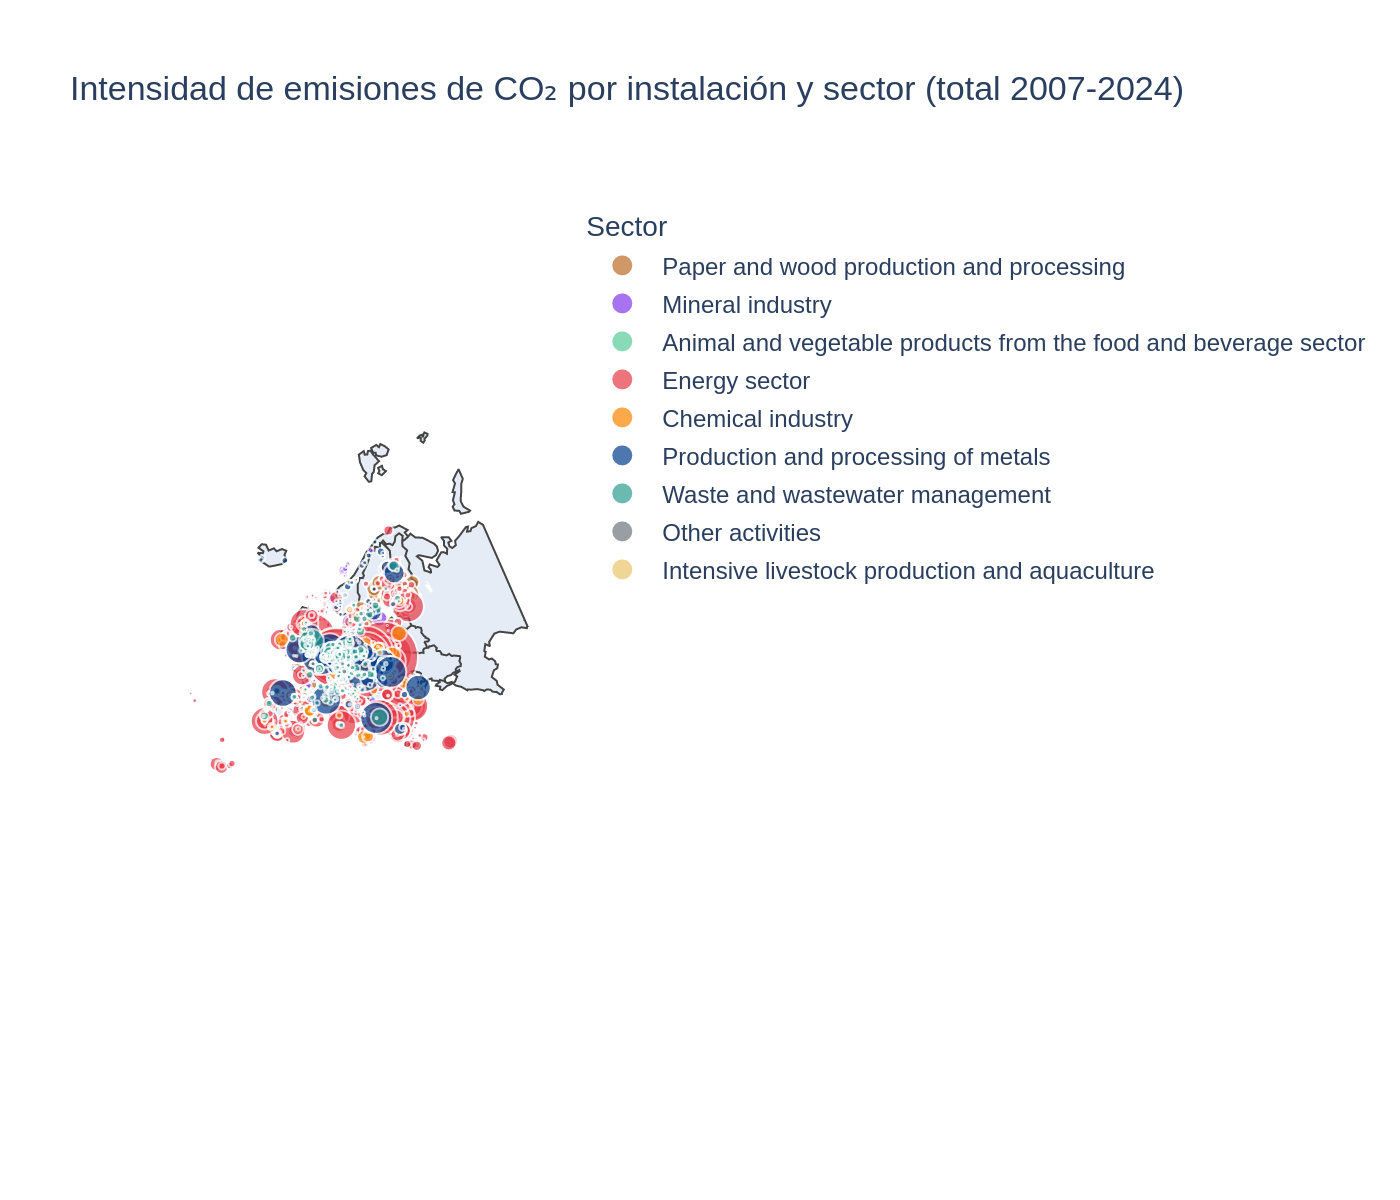

In [ ]:
## 5.5 Mapa de intensidad de emisiones

# Contaminante seleccionado para el mapa de intensidad
CONTAMINANTE_MAPA = 'AIR_Carbon dioxide (CO2)'

# Agregar emisiones totales por instalación (suma de todos los años)
map_data_agg = (
    geo_df[["FacilityInspireId", "facilityName", "countryName",
            "EPRTR_SectorName", "Latitude", "Longitude", CONTAMINANTE_MAPA]]
    .dropna(subset=[CONTAMINANTE_MAPA])
    .groupby(["FacilityInspireId", "facilityName", "countryName",
              "EPRTR_SectorName", "Latitude", "Longitude"])
    [CONTAMINANTE_MAPA].sum()
    .reset_index()
)

fig = px.scatter_geo(
    map_data_agg,
    lat="Latitude",
    lon="Longitude",
    size=CONTAMINANTE_MAPA,
    color="EPRTR_SectorName",
    hover_name="facilityName",
    hover_data={"countryName": True, CONTAMINANTE_MAPA: True,
                "Latitude": False, "Longitude": False},
    scope='europe',
    title="Intensidad de emisiones de CO₂ por instalación y sector (total 2007-2024)",
    color_discrete_map=sector_colors,
    size_max=25,
    labels={'EPRTR_SectorName': 'Sector'}
)

fig.update_layout(height=600)
fig.show(renderer='colab')

# Guardar como imagen estática
fig.write_image('/content/mapa_intensidad_co2.png', scale=2)
from IPython.display import Image
Image('/content/mapa_intensidad_co2.png')

# 6. Análisis complementario: agua, residuos y transferencias

Estas dimensiones se analizan por separado porque no representan exactamente la misma magnitud ambiental.


In [ ]:
# 6.1. Agua
water_summary = (
    water_long.dropna(subset=["valor"])
    .groupby("contaminante")
    .agg(
        observaciones=("valor", "count"),
        instalaciones=("FacilityInspireId", "nunique"),
        total_reportado=("valor", "sum"),
        mediana=("valor", "median")
    )
    .sort_values("total_reportado", ascending=False)
    .reset_index()
)
display(water_summary)

,contaminante,observaciones,instalaciones,total_reportado,mediana
0,Chlorides (as total Cl),3855,497,"216,270,849,738.330","7,290,000.000"
1,Total organic carbon(as total C or COD/3) (TOC),5858,791,"3,625,321,095.396","204,500.000"
2,Total nitrogen,4503,610,"1,600,121,372.933","135,000.000"
3,Total phosphorus,3161,508,"122,411,921.944","11,600.000"
4,Fluorides (as total F),3108,433,"105,258,221.456","7,399.935"
5,Zinc and compounds (as Zn),7422,1133,"11,454,149.863",506.000
6,Copper and compounds (as Cu),4581,798,"2,163,692.090",142.000
7,Nickel and compounds (as Ni),6537,1040,"1,710,057.720",70.400
8,Lead and compounds (as Pb),3328,682,"849,438.549",61.600
9,Arsenic and compounds (as As),4926,841,"631,435.855",19.800


**Análisis de vertidos al agua**:

- Los cloruros dominan ampliamente los vertidos al agua
  (216 billones de kg totales). Su origen principal son los procesos
  industriales que generan salmueras y aguas muy salinas
  (química, alimentación, tratamiento de aguas).

- El carbono orgánico total (TOC) y el nitrógeno total
  ocupan el segundo y tercer puesto, especialmente relevantes para la calidad ecológica de ríos y lagos.

- Los metales pesados (Zn, Cu, Ni, Pb, As) tienen volúmenes
  muy inferiores pero son reportados por más instalaciones,
  especialmente el Zinc (1.133 instalaciones) y Níquel (1.040),
  presentes en muchos procesos industriales distintos.

In [ ]:
# 6.2 Residuos
waste_summary = (
    waste_long.dropna(subset=["valor"])
    .groupby("contaminante")
    .agg(
        observaciones=("valor", "count"),
        instalaciones=("FacilityInspireId", "nunique"),
        total_reportado=("valor", "sum"),
        mediana=("valor", "median")
    )
    .sort_values("total_reportado", ascending=False)
    .reset_index()
)
display(waste_summary)

,contaminante,observaciones,instalaciones,total_reportado,mediana
0,Recovery_NONHW,41803,6307,"1,768,308,846.366","9,110.000"
1,Disposal_NONHW,32094,5490,"778,427,077.343","1,860.000"
2,Disposal_HW,56513,8152,"150,499,833.074",65.600
3,Recovery_HW,59570,8107,"132,305,905.888",52.600


**Análisis de transferencias de residuos:**

- Los residuos no peligrosos en recuperación (Recovery_NONHW)
  son el mayor flujo de residuos del dataset (1.768 millones de
  toneladas totales), indicativo positivo de economía circular,
  ya que la mayor parte de los residuos industriales europeos
  se destinan a valorización y no a eliminación.

- La comparación Recovery vs Disposal confirma este patrón:
  tanto en residuos peligrosos como no peligrosos, el volumen
  de recuperación supera al de eliminación (aunque la diferencia
  es mucho más pronunciada en los no peligrosos).

- Los residuos peligrosos (HW) tienen mediana muy baja
  (52-65 toneladas/año) comparada con los no peligrosos
  (1.860-9.110 toneladas/año), indicando que son sustancias
  más controladas y generadas en menor cantidad, aunque
  son reportadas por más instalaciones.

In [ ]:
# 6.3 Transferencias de contaminantes
transfer_summary = (
    transfer_long.dropna(subset=["valor"])
    .groupby("contaminante")
    .agg(
        observaciones=("valor", "count"),
        instalaciones=("FacilityInspireId", "nunique"),
        total_reportado=("valor", "sum"),
        mediana=("valor", "median")
    )
    .sort_values("total_reportado", ascending=False)
    .reset_index()
)
display(transfer_summary)

,contaminante,observaciones,instalaciones,total_reportado,mediana
0,Total organic carbon(as total C or COD/3) (TOC),3215,648,"2,426,246,362.415","194,241.000"
1,Total nitrogen,1400,280,"247,746,294.029","89,800.000"
2,Zinc and compounds (as Zn),1662,378,"29,966,212.124",248.215
3,Total phosphorus,871,234,"28,262,620.286","11,800.000"
4,Phenols (as total C),1356,292,"27,982,763.134",238.500
5,Nickel and compounds (as Ni),1592,338,"8,331,029.312",47.000


**Análisis de transferencias de contaminantes**:

- Las transferencias representan el medio con menor cobertura
  del dataset, con menos del 4% de instalaciones que las declaran,
  lo que indica que la mayoría gestiona sus contaminantes
  internamente o los vierte directamente sin transferencia a
  tratamiento externo.

- El carbono orgánico total (TOC) domina las transferencias
  (2.426 millones de kg totales, 648 instalaciones).

- El nitrógeno total ocupa el segundo puesto pero con muchas
  menos instalaciones (280) perteneciente a procesos específicos como la industria alimentaria y química.

- Los metales pesados (Zn, Ni) y los fenoles aparecen
  con volúmenes bajos y medianas muy pequeñas. Son contaminantes
  de nicho presentes en sectores concretos como metalurgia
  y química, donde su transferencia a gestores externos
  está muy regulada.
  
- La diferencia entre TOC en agua (3.625 millones de kg vertidos
  directamente) y TOC en transferencias (2.426 millones de kg
  transferidos a tratamiento externo) indica que una parte
  significativa de la carga orgánica industrial se gestiona
  internamente antes del vertido final.

# V. Conclusiones

Se genera indicadores para las conclusiones del EDA. Los valores son calculados directamente desde el dataset.

In [ ]:
# Indicadores generales
indicadores = {
    "Filas": len(df_merged),
    "Columnas": df_merged.shape[1],
    "Instalaciones únicas": df_merged["FacilityInspireId"].nunique(),
    "Países": df_merged["countryName"].nunique(),
    "Sectores E-PRTR": df_merged["EPRTR_SectorName"].nunique(),
    "Actividades Anexo I": df_merged["EPRTRAnnexIMainActivity"].nunique(),
    "Año inicial": df_merged["reportingYear"].min(),
    "Año final": df_merged["reportingYear"].max(),
    "Variables AIR": len(AIR_COLS),
    "Variables WATER": len(WATER_COLS),
    "Variables WASTE": len(WASTE_COLS),
    "Variables TRANSFER": len(TRANSFER_COLS),
    "Registros con coordenadas": geo_df.shape[0]
}

display(pd.Series(indicadores, name="valor").to_frame())

,valor
Filas,81005
Columnas,45
Instalaciones únicas,10788
Países,32
Sectores E-PRTR,9
Actividades Anexo I,73
Año inicial,2007
Año final,2024
Variables AIR,15
Variables WATER,10


In [ ]:
# Top país, sector y contaminante atmosférico
top_pais = inst_pais.iloc[0]
top_sector = inst_sector.iloc[0]
top_air = air_contaminants.iloc[0]

print("País con más instalaciones:", top_pais["countryName"], "->", int(top_pais["instalaciones"]))
print("Sector con más instalaciones:", top_sector["EPRTR_SectorName"], "->", int(top_sector["instalaciones"]))
print("Contaminante con mayor valor agregado reportado:", top_air["contaminante"])

País con más instalaciones: Spain -> 1452
Sector con más instalaciones: Waste and wastewater management -> 1996
Contaminante con mayor valor agregado reportado: Carbon dioxide (CO2)


**Conclusiones del análisis exploratorio**:

El análisis exploratorio del dataset de E-PRTR constituye una fuente de información sólida y representativa de la actividad industrial europea. Consta de 81.005 observaciones (instalación × año), 10.788 instalaciones
únicas en **32 países** y un periodo de 18 años (2007-2024).

**Estructura y calidad de los datos:**

- El dataset está limpio: sin duplicados, sin valores negativos
  en variables de emisiones y con un 99.8% de cobertura geográfica
  (80.838 registros con coordenadas).

- El alto porcentaje de nulos (84.5% en las variables de emisiones)
  no representa un problema de calidad sino una característica
  del registro E-PRTR: cada instalación solo declara
  los contaminantes que superan los umbrales legales de report.

**Patrones de emisiones:**

- El CO₂ domina las emisiones atmosféricas en volumen con
  28,8 billones de kg en el periodo, concentrados principalmente
  en el sector energético.

- Todos los contaminantes principales muestran una tendencia
  bajista sostenida entre 2007 y 2024, con una caída especialmente
  pronunciada a partir de 2020 (debido al impacto del COVID-19
  y la aceleración de las políticas del Pacto Verde Europeo).

- La reducción más espectacular corresponde a los SOX,
  resultado directo de su regulación y consiguiente reducción que impusieron las directivas europeas de emisiones industriales.

**Distribución geográfica y sectorial:**

- Alemania, España, Francia, Reino Unido y Polonia concentran
  el mayor número de instalaciones y el mayor volumen de emisiones.

- La ganadería intensiva es el tercer sector por número de
  instalaciones (1.603), dominante en la Península Ibérica,
  Francia y Europa del Este.

- Los residuos no peligrosos muestran un patrón positivo
  de economía circular: el volumen de recuperación supera
  al de eliminación tanto en residuos peligrosos como no peligrosos.

# 3. Predicción de emisiones anuales de CO₂ de instalaciones industriales
## Modelo de regresión aplicado a datos del registro europeo E-PRTR

---

**Versión:** Notebook consolidado v1 (primera versión completa de principio a fin)
**Fuente de datos:** European Pollutant Release and Transfer Register (E-PRTR)

---

### Objetivo del TFM

Desarrollar y comparar modelos de regresión —lineales regularizados (Lasso, Ridge) frente a modelos basados en árboles (Random Forest, XGBoost)— para predecir las emisiones anuales de CO₂ de instalaciones industriales europeas, a partir de otros contaminantes, residuos generados, sector de actividad, país y año.

### Cómo está organizado este notebook

Cada fase incluye, además del código:
- **Explicación conceptual**: qué es y por qué se usa cada técnica (útil para preparar la exposición/defensa)
- **Decisión metodológica**: qué se decidió y por qué, en este dataset concreto
- **Conclusión de la fase**: qué significan los resultados obtenidos

| Fase | Contenido |
|---|---|
| 1 | Carga y verificación de estructura |
| 2 | Diagnóstico del mecanismo de missingness (MNAR) |
| 3 | Variable objetivo: unidades y transformación |
| 4 | Selección de variables explicativas |
| 5 | Preprocesado final y partición train-test |
| 6 | Modelado: Lasso, Ridge, Random Forest, XGBoost |
| 7 | Evaluación: métricas globales y por segmento |
| 8 | Interpretabilidad: SHAP y coeficientes |
| 9 | Conclusiones generales del TFM |

In [ ]:
# ── Imports regresión
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (RandomizedSearchCV, KFold, GroupShuffleSplit)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from scipy import stats

import shap
import time
import joblib

# ── Reset semilla
SEED = 42
RANDOM_STATE = SEED
random.seed(SEED)
np.random.seed(SEED)

print(f"Semilla reseteada: SEED={SEED}")

Semilla reseteada: SEED=42


## Fase 1 — Carga y verificación de estructura

*Datos de panel.* este dataset combina una dimensión de corte transversal (distintas instalaciones industriales) con una dimensión temporal (distintos años de reporte). Cada fila representa una combinación única *instalación × año*. Esta estructura se conoce como **datos de panel** y tiene implicaciones directas en cómo se debe particionar el dataset más adelante (Fase 5), porque los registros de una misma instalación en años distintos no son observaciones independientes entre sí.

In [ ]:
print(f"Dimensiones: {df_merged.shape[0]:,} filas x {df_merged.shape[1]} columnas")
print(f"Instalaciones únicas (FacilityInspireId): {df_merged['FacilityInspireId'].nunique():,}")
print(f"Rango de años: {df_merged['reportingYear'].min()} - {df_merged['reportingYear'].max()}")
print(f"Duplicados exactos: {df_merged.duplicated().sum()}")
print(f"Duplicados por (instalación, año): {df_merged.duplicated(subset=['FacilityInspireId','reportingYear']).sum()}")


Dimensiones: 81,005 filas x 45 columnas
Instalaciones únicas (FacilityInspireId): 10,788
Rango de años: 2007 - 2024
Duplicados exactos: 0
Duplicados por (instalación, año): 0


**Conclusión de la fase:** el dataset contiene 81.005 registros de panel (instalación-año), correspondientes a 10.788 instalaciones industriales únicas, distribuidas entre 2007 y 2024, sin duplicados. La integridad estructural del dataset queda confirmada antes de cualquier análisis posterior.

## Fase 2 — Diagnóstico del mecanismo de missingness (MNAR)

*Tipos de datos faltantes.* en estadística se distinguen tres mecanismos de ausencia de datos:
- **MCAR** (Missing Completely At Random): la probabilidad de que falte un dato no depende de nada, ni del propio valor ni de otras variables. Es el caso "ideal", poco común en la práctica.
- **MAR** (Missing At Random): la probabilidad de que falte depende de OTRAS variables observadas, pero no del propio valor ausente.
- **MNAR** (Missing Not At Random): la probabilidad de que falte depende del PROPIO valor que falta. Es el caso más difícil de tratar, porque imputar sin más introduce sesgo.

**Por qué importa aquí:** el E-PRTR exige reportar un contaminante únicamente si la instalación supera un umbral legal específico para esa sustancia (para CO₂, 100.000 t/año). Esto significa que un valor nulo en AIR_Carbon dioxide (CO2) no es un fallo de medición: indica que la instalación emitió por debajo del umbral (o no aplica). **La probabilidad de que el dato falte depende directamente de la magnitud del propio valor** → es un caso claro de MNAR.

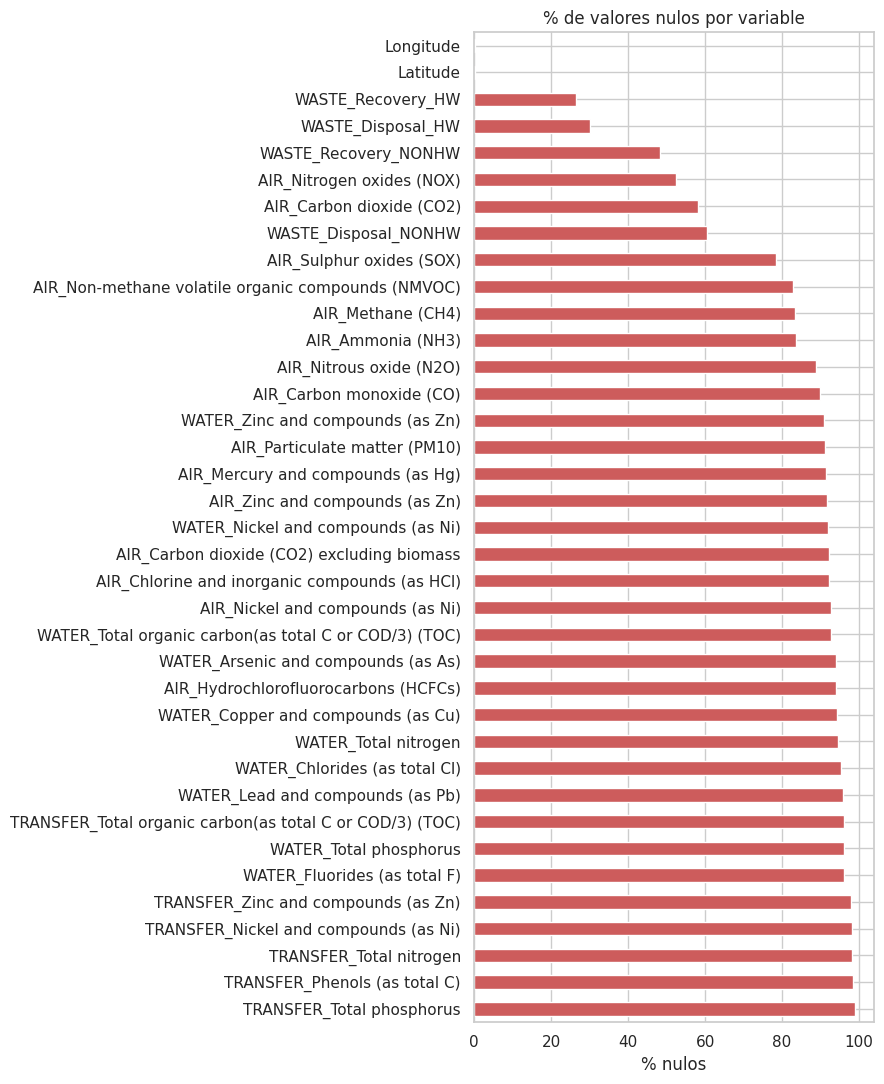

,0
TRANSFER_Total phosphorus,98.925
TRANSFER_Phenols (as total C),98.326
TRANSFER_Total nitrogen,98.272
TRANSFER_Nickel and compounds (as Ni),98.035
TRANSFER_Zinc and compounds (as Zn),97.948
WATER_Fluorides (as total F),96.163
WATER_Total phosphorus,96.098
TRANSFER_Total organic carbon(as total C or COD/3) (TOC),96.031
WATER_Lead and compounds (as Pb),95.892
WATER_Chlorides (as total Cl),95.241


In [ ]:
null_pct = (df_merged.isna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 11))
null_pct[null_pct > 0].plot(kind='barh', ax=ax, color='indianred')
ax.set_title('% de valores nulos por variable')
ax.set_xlabel('% nulos')
plt.tight_layout()
plt.show()

null_pct[null_pct > 0]

**Conclusión de la fase:** casi todas las variables de contaminantes muestran entre el 26% y el 99% de nulos, con un patrón jerárquico consistente con umbrales de reporte distintos por sustancia (sustancias más comunes/reguladas como CO₂ o NOX tienen menos nulos que sustancias raras como metales pesados en TRANSFER_). Esta interpretación del missingness como MNAR estructural, y no como error de captura, es la base metodológica que justifica redefinir el alcance del modelo en la fase siguiente.

## Fase 3 — Variable objetivo: definición, unidades y transformación

### 3.1 — Redefinición del alcance del modelo (Opción A)

Dado el mecanismo MNAR descrito en la Fase 2, el modelo se entrena únicamente sobre el subconjunto de instalaciones-año que **sí reportan** CO₂ (superan el umbral legal). Esto redefine la población objetivo del estudio:

> *No es "todas las instalaciones industriales europeas", sino "instalaciones industriales europeas cuyas emisiones de CO₂ superan el umbral legal de reporte obligatorio (100.000 t/año)".*

Esta es una limitación de alcance que debe declararse explícitamente al presentar resultados — es un sesgo de selección conocido y documentado, no un error metodológico.

In [ ]:
target = 'AIR_Carbon dioxide (CO2)'

n_total = len(df_merged)
n_null = df_merged[target].isna().sum()
n_zero = (df_merged[target] == 0).sum()

df_model = df_merged[df_merged[target].notna() & (df_merged[target] > 0)].copy()

print(f"Total de filas:                 {n_total:,}")
print(f"Nulos en target:                {n_null:,} ({n_null/n_total:.1%})")
print(f"Dataset de trabajo (Opción A):  {df_model.shape[0]:,} filas")
print(f"Instalaciones únicas:           {df_model['FacilityInspireId'].nunique():,}")

Total de filas:                 81,005
Nulos en target:                47,163 (58.2%)
Dataset de trabajo (Opción A):  33,831 filas
Instalaciones únicas:           3,342


### 3.2 — Verificación de unidades

*Validación de calidad de datos.* antes de modelar cualquier variable, es buena práctica verificar que sus valores son físicamente plausibles, no solo confiar en el nombre de la columna. Aquí, el nombre sugiere toneladas, pero los valores observados (hasta 43.200 millones) no son plausibles en esa unidad — superarían varias veces las emisiones anuales de CO₂ de todo el planeta. La hipótesis alternativa (kilogramos) sí es consistente con magnitudes reales de grandes instalaciones industriales (grandes centrales de carbón: 20-40 millones de toneladas/año).


In [ ]:
# Conversión de kg (unidad real de los datos) a toneladas
df_model['CO2_toneladas'] = df_model[target] / 1000

print(df_model['CO2_toneladas'].describe())
print(f"\nMáximo en toneladas/año: {df_model['CO2_toneladas'].max():,.0f}")
print("(Coherente con grandes centrales de carbón europeas: 20-40M t/año)")

count       33,831.000
mean       852,485.202
std      1,931,016.956
min              0.728
25%        167,897.000
50%        319,000.000
75%        782,000.000
max     43,200,000.000
Name: CO2_toneladas, dtype: float64

Máximo en toneladas/año: 43,200,000
(Coherente con grandes centrales de carbón europeas: 20-40M t/año)


### 3.3 — Transformación logarítmica

*Por qué transformar la variable objetivo.* muchas variables de escala industrial o económica (ingresos, población, emisiones) siguen una distribución muy asimétrica a la derecha (unas pocas observaciones enormes, la mayoría pequeñas) — esto se llama **distribución log-normal**. Modelar directamente esta variable en modelos lineales viola el supuesto de normalidad de los residuos y da excesivo peso a los valores extremos. La solución estándar es aplicar una **transformación logarítmica** (log10 o log natural), que comprime la escala y aproxima la distribución a una normal, mejorando el comportamiento de los modelos lineales y estabilizando la varianza (homocedasticidad).

### Por qué transformar: evidencia numérica antes de aplicar el logaritmo

Antes de aplicar la transformación, conviene mostrar por qué es necesaria, no solo asumirlo. Se calculan indicadores de forma de la distribución en escala original (toneladas).

In [ ]:

serie_original = df_model['CO2_toneladas']
skewness = stats.skew(serie_original)
kurtosis = stats.kurtosis(serie_original)
media, mediana = serie_original.mean(), serie_original.median()

print(f"Asimetría (skewness): {skewness:.2f}  (0 = simétrica; >1 ya se considera asimetría fuerte)")
print(f"Curtosis (exceso):    {kurtosis:.2f}  (0 = como una normal; valores altos = colas muy pesadas)")
print(f"Media:   {media:,.0f} t")
print(f"Mediana: {mediana:,.0f} t")
print(f"Ratio media/mediana: {media/mediana:.2f}  (en una distribución simétrica sería aprox. 1.0)")

top1 = serie_original.quantile(0.99)
peso_top1 = serie_original[serie_original >= top1].sum() / serie_original.sum()
print(f"El 1% de instalaciones más grandes concentra el {peso_top1:.1%} de las emisiones totales")

Asimetría (skewness): 8.64  (0 = simétrica; >1 ya se considera asimetría fuerte)
Curtosis (exceso):    110.22  (0 = como una normal; valores altos = colas muy pesadas)
Media:   852,485 t
Mediana: 319,000 t
Ratio media/mediana: 2.67  (en una distribución simétrica sería aprox. 1.0)
El 1% de instalaciones más grandes concentra el 17.8% de las emisiones totales


Un skewness de 8,64 está muy por encima del umbral de 1 que ya se considera asimetría fuerte, y la curtosis de 110 indica una concentración de valores extremos muy superior a la de una distribución normal. La media casi triplica la mediana (ratio 2,67), y el 1% de instalaciones más grandes concentra cerca del 18% de las emisiones totales del subconjunto — un patrón similar al que se observa en la distribución de ingresos o tamaños de empresa (pocas unidades muy grandes, mayoría pequeñas). Esta evidencia numérica, no solo visual, respalda la decisión de trabajar en escala logarítmica en el resto del análisis.

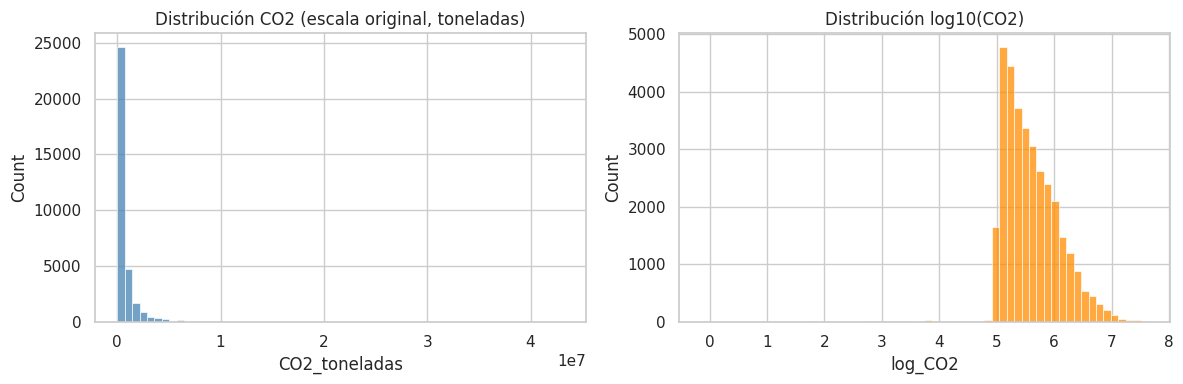

In [ ]:
df_model['log_CO2'] = np.log10(df_model['CO2_toneladas'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_model['CO2_toneladas'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución CO2 (escala original, toneladas)')
sns.histplot(df_model['log_CO2'], bins=60, ax=axes[1], color='darkorange')
axes[1].set_title('Distribución log10(CO2)')
plt.tight_layout()
plt.show()

**Conclusión de la fase:** se confirma que la unidad real de la columna es kilogramos (corregida a toneladas), y se justifica el uso de log10(toneladas) como variable objetivo del modelo, dada su distribución marcadamente asimétrica en escala original. Todo el modelado posterior se realiza sobre esta variable transformada, revirtiendo a escala real únicamente al calcular las métricas finales de evaluación.

## Fase 4 — Selección de variables explicativas

**Criterio de exclusión por nulos:** dado el mecanismo MNAR (Fase 2), las variables con muy alto % de nulos dentro del subconjunto de trabajo aportan poca señal fiable si se imputan masivamente. Se fija un umbral de corte razonado.

In [ ]:
NULL_THRESHOLD = 65  # % — variables con más nulos que esto se descartan como predictores

null_pct_model = (df_model.isna().mean() * 100).sort_values()
candidate_cols = null_pct_model[null_pct_model <= NULL_THRESHOLD].index.tolist()

exclude = ['FacilityInspireId', 'facilityName', 'city', target, 'log_CO2', 'CO2_toneladas',
           'AIR_Carbon dioxide (CO2) excluding biomass']
feature_candidates = [c for c in candidate_cols if c not in exclude]

print("Variables candidatas (NULL_THRESHOLD=65%):")
for c in feature_candidates:
    print(" -", c)

Variables candidatas (NULL_THRESHOLD=65%):
 - reportingYear
 - EPRTR_SectorCode
 - EPRTR_SectorName
 - countryName
 - EPRTRAnnexIMainActivity
 - Latitude
 - Longitude
 - WASTE_Recovery_HW
 - AIR_Nitrogen oxides (NOX)
 - WASTE_Disposal_HW
 - WASTE_Recovery_NONHW
 - WASTE_Disposal_NONHW
 - AIR_Sulphur oxides (SOX)


*Cardinalidad en variables categóricas.* la cardinalidad es el número de categorías distintas que toma una variable categórica. Es relevante porque, al codificar con One-Hot Encoding, cada categoría genera una nueva columna binaria — una variable con alta cardinalidad (por ejemplo, 66 categorías) puede disparar la dimensionalidad del modelo sin aportar proporcionalmente más información, además de generar categorías con muy pocas observaciones (riesgo de sobreajuste).

**Decisión:** se descarta EPRTRAnnexIMainActivity (66 categorías) en favor de EPRTR_SectorName (9 categorías), que agrupa la misma información a un nivel más manejable.

Multicolinealidad. ocurre cuando dos o más variables explicativas están altamente correlacionadas entre sí. Es un problema especialmente para los modelos lineales (Lasso/Ridge), porque dificulta separar el efecto individual de cada variable y puede hacer inestables los coeficientes estimados. Se revisa mediante la matriz de correlación antes de finalizar la selección de variables.

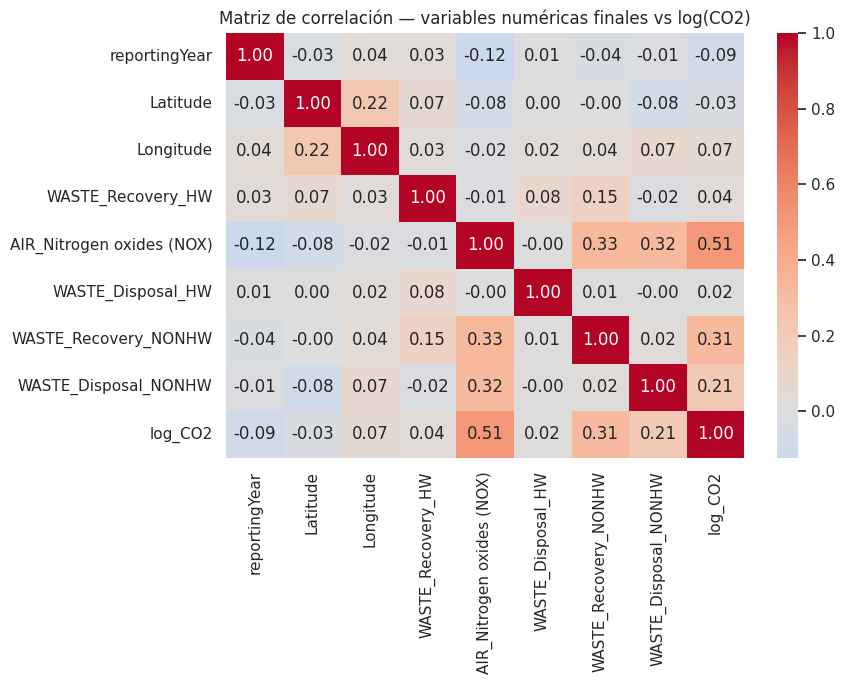

In [ ]:
FEATURES_FINAL_NUM = ['reportingYear', 'Latitude', 'Longitude',
                       'WASTE_Recovery_HW', 'AIR_Nitrogen oxides (NOX)',
                       'WASTE_Disposal_HW', 'WASTE_Recovery_NONHW', 'WASTE_Disposal_NONHW']
# AIR_Sulphur oxides (SOX) se excluye deliberadamente pese a cumplir el umbral de nulos,
# por riesgo de sesgo: comparte el mismo mecanismo de umbral de reporte que el target,
# lo que podría generar una correlación espuria basada en tamaño de instalación, no en
# relación causal real con las emisiones de CO2.

corr = df_model[FEATURES_FINAL_NUM + ['log_CO2']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de correlación — variables numéricas finales vs log(CO2)')
plt.tight_layout()
plt.show()

**Conclusión de la fase:** se seleccionan como variables explicativas finales: EPRTR_SectorName, countryName, reportingYear, Latitude, Longitude, y cinco variables numéricas de contaminación/residuos. No se detecta multicolinealidad severa entre predictores (correlaciones máximas ~0,33-0,35). AIR_Nitrogen oxides (NOX) muestra la correlación más alta con el target (0,51), anticipando su papel como variable más relevante en el modelado.

## Fase 5 — Preprocesado final y partición train-test

Esta fase integra las siguientes técnicas, cada una con su justificación conceptual:

| Técnica | Qué es | Por qué se usa aquí |
|---|---|---|
| Imputación condicionada | Rellenar nulos usando la mediana calculada dentro de cada sector, no globalmente | La escala de las variables varía mucho entre sectores; la mediana global sesgaría hacia el sector dominante (Energy) |
| Agrupación de categorías raras | Fusionar categorías con muy pocas observaciones en "Other" | Evita categorías casi vacías que distorsionan el One-Hot Encoding y aportan poca generalización |
| Partición agrupada por instalación (GroupShuffleSplit) | Asegurar que una misma instalación no aparezca en train y test simultáneamente | Con ~10 años por instalación en promedio, una partición aleatoria simple filtraría información entre train/test (fuga de datos), inflando artificialmente las métricas |
| One-Hot Encoding | Convertir variables categóricas en columnas binarias | Necesario para que los modelos (especialmente los lineales) puedan procesar variables no numéricas |
| Winsorización (capping) | Acotar valores extremos de variables explicativas a un percentil límite, sin eliminar la fila | Se detectó que un outlier multivariante en AIR_NOX provocaba extrapolación inestable en los modelos lineales al revertir la predicción de escala log a escala real (ver nota metodológica abajo) |
| Escalado (StandardScaler) | Normalizar variables numéricas a media 0 y desviación 1 | Obligatorio para Lasso/Ridge, cuya penalización depende de la escala de los coeficientes; innecesario para modelos de árbol |

**Nota metodológica — por qué se incluye winsorización:** durante el desarrollo de este TFM se detectó que una instalación con un valor de AIR_NOX ~40-60 veces por encima de la media provocaba, al aplicarse un coeficiente lineal, predicciones de CO₂ manifiestamente irreales (miles de millones de toneladas) que distorsionaban por completo las métricas de Lasso y Ridge en escala real, pese a que su error en escala logarítmica era moderado. Se optó por winsorizar (acotar al percentil 99 de train) las variables numéricas explicativas antes del escalado, preservando la fila pero limitando la influencia de valores extremos — una alternativa menos agresiva que eliminar la observación.

In [ ]:
CAT_FEATURES = ['EPRTR_SectorName', 'countryName']
NUM_FEATURES = FEATURES_FINAL_NUM
TARGET_LOG = 'log_CO2'

df_fe = df_model[CAT_FEATURES + NUM_FEATURES + [TARGET_LOG, 'FacilityInspireId']].copy()
print(f"Dataset previo a imputación: {df_fe.shape}")

# --- Imputación condicionada al sector ---
for col in NUM_FEATURES:
    if col == 'reportingYear':
        continue
    df_fe[col] = df_fe.groupby('EPRTR_SectorName')[col].transform(lambda x: x.fillna(x.median()))
    df_fe[col] = df_fe[col].fillna(df_fe[col].median())

# --- Agrupación de categorías con pocas observaciones ---
SMALL_SECTOR_THRESHOLD = 100
sector_counts = df_fe['EPRTR_SectorName'].value_counts()
small_sectors = sector_counts[sector_counts < SMALL_SECTOR_THRESHOLD].index.tolist()
df_fe['EPRTR_SectorName'] = df_fe['EPRTR_SectorName'].replace({s: 'Other activities' for s in small_sectors})

SMALL_COUNTRY_THRESHOLD = 50
country_counts = df_fe['countryName'].value_counts()
small_countries = country_counts[country_counts < SMALL_COUNTRY_THRESHOLD].index.tolist()
df_fe['countryName'] = df_fe['countryName'].replace({c: 'Other' for c in small_countries})

print(f"Sectores finales: {df_fe['EPRTR_SectorName'].nunique()} | Países finales: {df_fe['countryName'].nunique()}")

# --- Partición agrupada por instalación ---
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df_fe, groups=df_fe['FacilityInspireId']))
df_train = df_fe.iloc[train_idx].copy()
df_test = df_fe.iloc[test_idx].copy()

overlap = set(df_train['FacilityInspireId']) & set(df_test['FacilityInspireId'])
print(f"\nTrain: {df_train.shape[0]:,} filas | {df_train['FacilityInspireId'].nunique():,} instalaciones")
print(f"Test:  {df_test.shape[0]:,} filas | {df_test['FacilityInspireId'].nunique():,} instalaciones")
print(f"Instalaciones solapadas (debe ser 0): {len(overlap)}")

# --- One-Hot Encoding (fit solo en train, alineado con test) ---
df_train_enc = pd.get_dummies(df_train, columns=CAT_FEATURES, drop_first=True)
df_test_enc = pd.get_dummies(df_test, columns=CAT_FEATURES, drop_first=True)
df_train_enc, df_test_enc = df_train_enc.align(df_test_enc, join='left', axis=1, fill_value=0)

drop_cols = ['FacilityInspireId', TARGET_LOG]
X_train = df_train_enc.drop(columns=drop_cols)
y_train = df_train_enc[TARGET_LOG]
X_test = df_test_enc.drop(columns=drop_cols)
y_test = df_test_enc[TARGET_LOG]

print(f"\nX_train: {X_train.shape} | X_test: {X_test.shape}")

# --- Winsorización de variables numéricas explicativas (percentil 99 de TRAIN) ---
NUM_TO_CAP = ['WASTE_Recovery_HW', 'AIR_Nitrogen oxides (NOX)',
              'WASTE_Disposal_HW', 'WASTE_Recovery_NONHW', 'WASTE_Disposal_NONHW']
X_train_capped = X_train.copy()
X_test_capped = X_test.copy()
caps = {}
for col in NUM_TO_CAP:
    upper = X_train[col].quantile(0.99)
    caps[col] = upper
    X_train_capped[col] = X_train_capped[col].clip(upper=upper)
    X_test_capped[col] = X_test_capped[col].clip(upper=upper)
print("\nWinsorización aplicada (percentil 99 de train):")
for col, val in caps.items():
    print(f"  {col}: cap = {val:,.0f}")

# --- Escalado (sobre datos ya winsorizados) ---
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_capped), columns=X_train_capped.columns, index=X_train_capped.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_capped), columns=X_test_capped.columns, index=X_test_capped.index)

print("\nPreprocesado completo:")
print(" - X_train, X_test               -> Random Forest / XGBoost (sin escalar, sin winsorizar)")
print(" - X_train_scaled, X_test_scaled -> Lasso / Ridge (winsorizadas y escaladas)")
print(" - y_train, y_test               -> target en log10(toneladas CO2)")

Dataset previo a imputación: (33831, 12)
Sectores finales: 8 | Países finales: 29

Train: 27,113 filas | 2,673 instalaciones
Test:  6,718 filas | 669 instalaciones
Instalaciones solapadas (debe ser 0): 0

X_train: (27113, 43) | X_test: (6718, 43)

Winsorización aplicada (percentil 99 de train):
  WASTE_Recovery_HW: cap = 33,188
  AIR_Nitrogen oxides (NOX): cap = 10,641,360
  WASTE_Disposal_HW: cap = 36,700
  WASTE_Recovery_NONHW: cap = 432,880
  WASTE_Disposal_NONHW: cap = 251,880

Preprocesado completo:
 - X_train, X_test               -> Random Forest / XGBoost (sin escalar, sin winsorizar)
 - X_train_scaled, X_test_scaled -> Lasso / Ridge (winsorizadas y escaladas)
 - y_train, y_test               -> target en log10(toneladas CO2)


**Conclusión de la fase:** el pipeline de preprocesado queda validado sin fuga de información (0 instalaciones solapadas entre train y test, ajuste de encoding/escalado/winsorización realizado exclusivamente sobre train). Quedan definidos los cuatro conjuntos de datos necesarios para el modelado: versión sin escalar (árboles) y versión escalada+winsorizada (modelos lineales).

## Fase 6 — Modelado: Lasso, Ridge, Random Forest, XGBoost

### Conceptos clave de cada familia de modelos

**Lasso (Least Absolute Shrinkage and Selection Operator):** regresión lineal con penalización L1 (suma de valores absolutos de los coeficientes). Su característica distintiva es que puede llevar coeficientes exactamente a **cero**, funcionando como selector automático de variables. El hiperparámetro alpha controla la fuerza de la penalización: a mayor alpha, más coeficientes se anulan.

**Ridge:** regresión lineal con penalización L2 (suma de los coeficientes al cuadrado). A diferencia de Lasso, reduce los coeficientes hacia cero pero rara vez los anula por completo — es útil sobre todo cuando hay variables correlacionadas entre sí (multicolinealidad), repartiendo el peso entre ellas en vez de eliminar unas a favor de otras.

**Random Forest:** conjunto (ensemble) de múltiples árboles de decisión entrenados sobre submuestras aleatorias de los datos y de las variables (bagging), cuyas predicciones se promedian. Captura relaciones no lineales e interacciones entre variables sin necesidad de especificarlas manualmente.

**XGBoost (Extreme Gradient Boosting):** también un ensemble de árboles, pero construidos de forma secuencial (boosting): cada árbol nuevo se entrena para corregir los errores del conjunto de árboles anterior. Suele lograr mejor rendimiento que Random Forest en muchos problemas tabulares, a cambio de mayor riesgo de sobreajuste si no se regula bien (de ahí los hiperparámetros de regularización reg_alpha, reg_lambda).

**Validación cruzada (Cross-Validation):** técnica para evaluar un modelo de forma más robusta que una única partición train-test. Se divide el conjunto de entrenamiento en *k* particiones ("folds"); el modelo se entrena *k* veces, usando cada vez una partición distinta como validación y el resto como entrenamiento. El rendimiento final es el promedio de las *k* iteraciones — reduce el riesgo de que el resultado dependa de una partición concreta "afortunada" o "desafortunada".

In [ ]:
results = {}
predictions = {}
cv_scheme = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Baseline: predicción = media del train (referencia mínima exigible) ---
predictions['Baseline (media)'] = np.full_like(y_test, y_train.mean(), dtype=float)

# --- Lasso ---
t0 = time.time()
lasso = LassoCV(alphas=np.logspace(-4, 1, 50), cv=cv_scheme, random_state=RANDOM_STATE, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
print(f"Lasso  -> alpha óptimo: {lasso.alpha_:.5f} | tiempo: {time.time()-t0:.1f}s")
predictions['Lasso'] = lasso.predict(X_test_scaled)

# --- Ridge ---
t0 = time.time()
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=cv_scheme)
ridge.fit(X_train_scaled, y_train)
print(f"Ridge  -> alpha óptimo: {ridge.alpha_:.5f} | tiempo: {time.time()-t0:.1f}s")
predictions['Ridge'] = ridge.predict(X_test_scaled)

Lasso  -> alpha óptimo: 0.00010 | tiempo: 1.2s
Ridge  -> alpha óptimo: 19.30698 | tiempo: 11.3s


**Nota sobre tiempos de ejecución:** las búsquedas de hiperparámetros de Random Forest y XGBoost pueden tardar varios minutos en la CPU estándar de Colab gratuito. Se emplea RandomizedSearchCV (búsqueda aleatoria sobre un subconjunto de combinaciones) en vez de GridSearchCV (búsqueda exhaustiva) para acotar el tiempo de cómputo manteniendo una exploración representativa del espacio de hiperparámetros — una decisión razonada por restricciones computacionales, válida de documentar como tal en la memoria.

In [ ]:
cv_scheme_fast = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# --- Random Forest ---
t0 = time.time()
rf_param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [None, 10, 16],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.6]
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=2),
    param_distributions=rf_param_dist, n_iter=8, cv=cv_scheme_fast,
    scoring='neg_root_mean_squared_error', random_state=RANDOM_STATE, n_jobs=2
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
print(f"RF     -> mejores params: {rf_search.best_params_} | tiempo: {time.time()-t0:.1f}s")
predictions['Random Forest'] = rf_best.predict(X_test)

# --- XGBoost ---
t0 = time.time()
xgb_param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.7, 1.0]
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=2, objective='reg:squarederror'),
    param_distributions=xgb_param_dist, n_iter=8, cv=cv_scheme_fast,
    scoring='neg_root_mean_squared_error', random_state=RANDOM_STATE, n_jobs=2
)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_
print(f"XGBoost -> mejores params: {xgb_search.best_params_} | tiempo: {time.time()-t0:.1f}s")
predictions['XGBoost'] = xgb_best.predict(X_test)

print("\nModelado completo:", list(predictions.keys()))


RF     -> mejores params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None} | tiempo: 351.4s
XGBoost -> mejores params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.7} | tiempo: 22.7s

Modelado completo: ['Baseline (media)', 'Lasso', 'Ridge', 'Random Forest', 'XGBoost']


### Interpretación de los hiperparámetros seleccionados

Random Forest eligió la configuración más flexible posible dentro del espacio de búsqueda: árboles sin límite de profundidad y con el mínimo de observaciones permitido para dividir nodos. Esto genera árboles individuales muy detallados, cuya predicción final se promedia entre 200 árboles distintos. Es la estrategia típica de Random Forest: reducir el error promediando muchos árboles complejos y algo distintos entre sí (bagging).

XGBoost eligió la estrategia opuesta: árboles mucho más simples, de solo 4 niveles de profundidad, mostrando además solo el 70% de las variables en cada árbol, pero encadenados de forma secuencial a lo largo de 300 iteraciones, donde cada árbol nuevo corrige los errores del conjunto anterior a un ritmo moderado. Es la estrategia típica de boosting: construir la solución de forma incremental con piezas simples, en vez de piezas individuales muy complejas.

Ambos modelos alcanzan buen desempeño por caminos distintos: Random Forest promediando complejidad, XGBoost acumulando simplicidad de forma secuencial. En este dataset, la estrategia de XGBoost resultó ligeramente más efectiva, un resultado habitual en datos tabulares de este tamaño, donde el boosting suele generalizar mejor que el bagging.

**Conclusión de la fase:** los cuatro modelos (más el baseline) quedan entrenados con hiperparámetros ajustados por validación cruzada. Lasso selecciona un alpha muy bajo (~0,0001), indicando que apenas penaliza — casi todas las variables mantienen coeficiente no nulo. Random Forest selecciona árboles sin límite de profundidad (max_depth=None), lo que explica su mayor coste computacional frente a XGBoost.

## Fase 7 — Evaluación: métricas globales y por segmento

### Conceptos clave de las métricas de regresión

| Métrica | Fórmula (idea) | Cómo se interpreta |
|---|---|---|
| **MAE** (Mean Absolute Error) | Promedio del valor absoluto de los errores | Error medio típico, en las mismas unidades que el target (toneladas). Fácil de interpretar, poco sensible a valores extremos |
| **RMSE** (Root Mean Squared Error) | Raíz cuadrada del promedio de errores al cuadrado | Como el MAE, pero penaliza más los errores grandes (al elevarlos al cuadrado). Si RMSE >> MAE, indica presencia de errores puntuales muy grandes |
| **R²** (Coeficiente de determinación) | Proporción de la varianza del target explicada por el modelo | Va de -∞ a 1. R²=1 es predicción perfecta; R²=0 equivale a predecir siempre la media; R²<0 significa que el modelo es peor que predecir la media |
| **MAPE** (Mean Absolute Percentage Error) | Promedio del error relativo (%) | Útil para comparar error en términos porcentuales, pero se distorsiona mucho cuando hay valores del target muy cercanos a cero (denominador pequeño) |

**Por qué se reportan métricas tanto en escala real como en log10:** el target se modela en escala logarítmica, pero las decisiones de negocio/política ambiental se toman en toneladas reales. Reportar ambas escalas permite ver si el buen (o mal) desempeño del modelo depende de la escala de medición.

In [ ]:
y_test_real = 10 ** y_test
metrics_rows = []
predictions_real = {}

for name, y_pred_log in predictions.items():
    y_pred_real = 10 ** y_pred_log
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2 = r2_score(y_test_real, y_pred_real)
    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
    mae_log = mean_absolute_error(y_test, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    r2_log = r2_score(y_test, y_pred_log)
    metrics_rows.append({'Modelo': name, 'MAE (t)': mae, 'RMSE (t)': rmse, 'R2': r2, 'MAPE (%)': mape,
                          'MAE (log10)': mae_log, 'RMSE (log10)': rmse_log, 'R2 (log10)': r2_log})
    predictions_real[name] = y_pred_real

metrics_df = pd.DataFrame(metrics_rows).set_index('Modelo').sort_values('RMSE (t)')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print(metrics_df)

                     MAE (t)      RMSE (t)     R2  MAPE (%)  MAE (log10)  \
Modelo                                                                     
XGBoost          389,236.258 1,085,607.113  0.608   184.140        0.216   
Random Forest    419,816.906 1,197,334.378  0.524   202.532        0.215   
Ridge            625,562.828 1,653,664.027  0.092 1,153.941        0.320   
Lasso            625,854.133 1,655,291.589  0.090 1,154.745        0.320   
Baseline (media) 725,719.291 1,813,499.023 -0.093 5,510.363        0.413   

                  RMSE (log10)  R2 (log10)  
Modelo                                      
XGBoost                  0.306       0.675  
Random Forest            0.298       0.692  
Ridge                    0.410       0.416  
Lasso                    0.410       0.416  
Baseline (media)         0.538      -0.006  


### Análisis de residuos (diagnóstico clásico de regresión lineal)

*Homocedasticidad.* un supuesto clave de la regresión lineal es que la varianza de los residuos (errores) sea constante a lo largo de todo el rango de predicción. Si se observa un patrón (forma de embudo, tendencia creciente/decreciente) en el gráfico de residuos vs predicciones, indica **heterocedasticidad** — la varianza del error no es constante — lo cual es una señal de que el modelo lineal no captura bien toda la estructura de los datos.

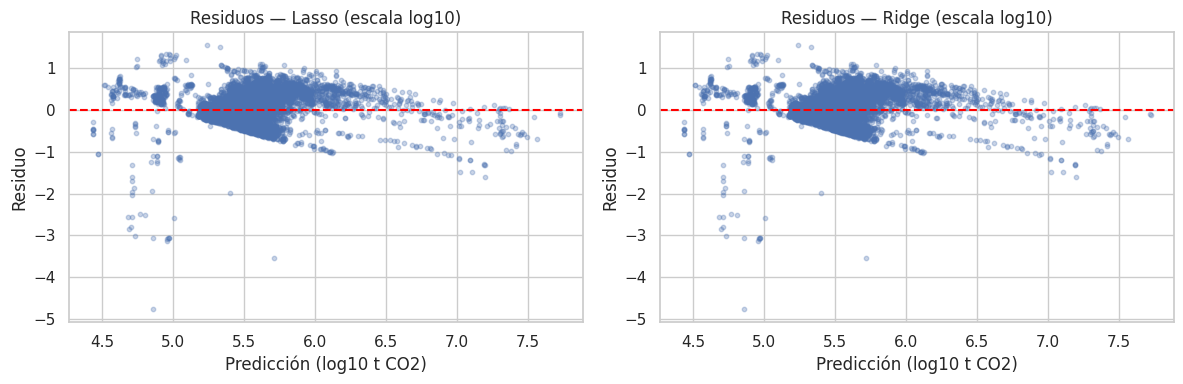

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, model_preds) in zip(axes, [('Lasso', predictions['Lasso']), ('Ridge', predictions['Ridge'])]):
    residuos = y_test - model_preds
    ax.scatter(model_preds, residuos, alpha=0.3, s=10)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f'Residuos — {name} (escala log10)')
    ax.set_xlabel('Predicción (log10 t CO2)')
    ax.set_ylabel('Residuo')
plt.tight_layout()
plt.show()

### Cómo leer este resultado

Se observa una tendencia descendente: a medida que crece la predicción, los residuos tienden a volverse negativos, es decir, el modelo sobreestima sistemáticamente en el rango de predicciones altas. También se aprecia una dispersión no constante (más ancha en el centro, más estrecha en los extremos), signo de heterocedasticidad.

Este patrón no se interpreta como un error del preprocesado, sino como consecuencia directa de la relación no lineal ya detectada entre los óxidos de nitrógeno y las emisiones de CO2 (ver el dependence plot de SHAP en la Fase 8): un modelo lineal no puede capturar una relación que se aplana a partir de cierto punto, y esa limitación se traduce visualmente en este patrón de residuos. Es la misma limitación estructural que explica por qué Random Forest y XGBoost obtienen mejor desempeño que Lasso y Ridge en este problema.

### Gráfico predicción vs. valores reales

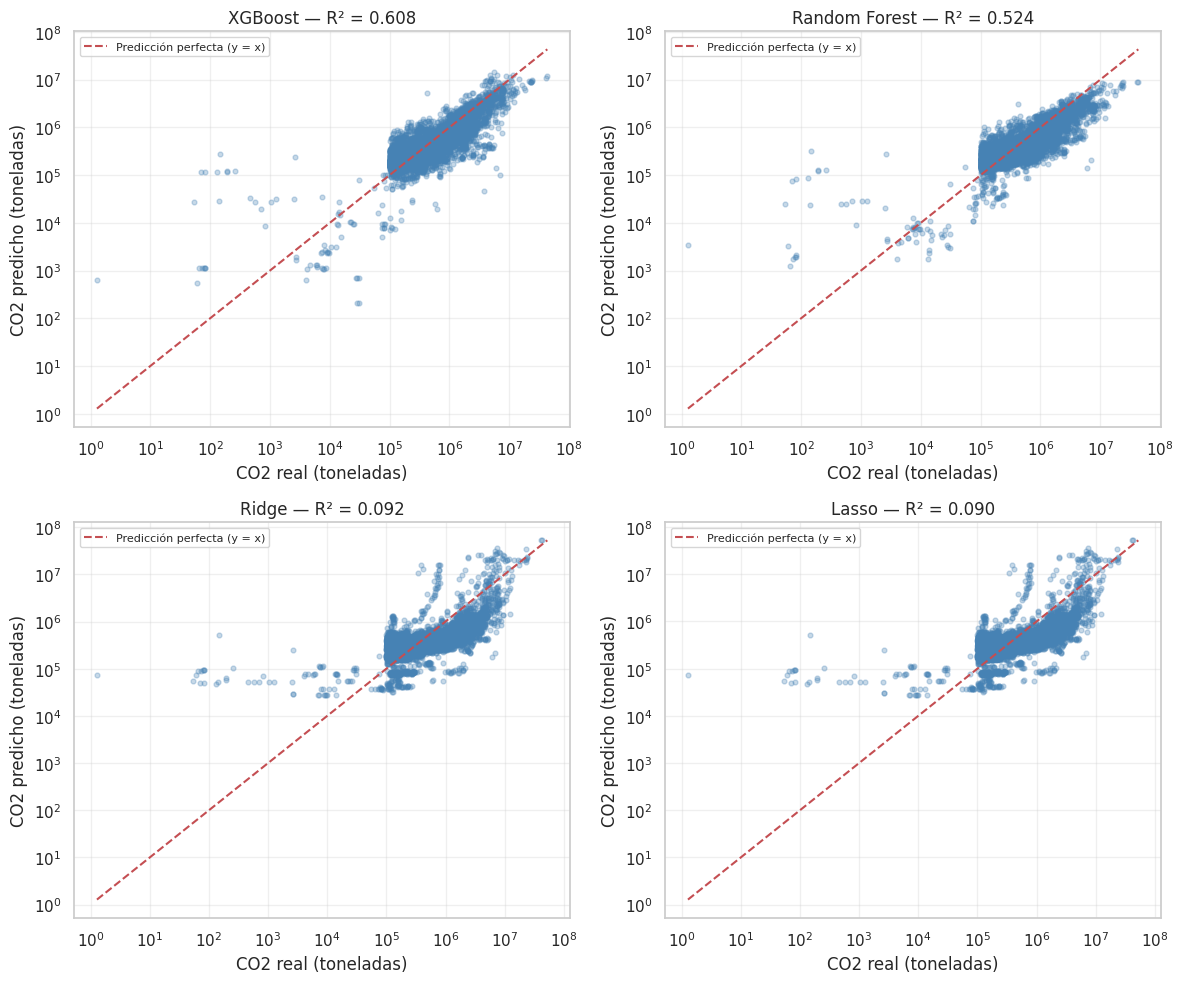

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, name in zip(axes, ['XGBoost', 'Random Forest', 'Ridge', 'Lasso']):
    y_pred_real = predictions_real[name]
    ax.scatter(y_test_real, y_pred_real, alpha=0.3, s=12, color='steelblue')
    lims = [min(y_test_real.min(), y_pred_real.min()), max(y_test_real.max(), y_pred_real.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta (y = x)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('CO2 real (toneladas)'); ax.set_ylabel('CO2 predicho (toneladas)')
    ax.set_title(f'{name} — R² = {metrics_df.loc[name, "R2"]:.3f}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Análisis por segmento de tamaño de instalación

*Regresión hacia la media.* es un fenómeno estadístico por el cual los modelos predictivos tienden a "suavizar" sus predicciones hacia el valor promedio del target, subestimando los casos extremadamente altos y sobreestimando los extremadamente bajos. Es especialmente frecuente cuando el target tiene una distribución muy asimétrica (como aquí) y el modelo prioriza minimizar el error global, que está dominado por las observaciones más numerosas (rango medio).

                                          n       MAE (t)      R2   MAPE (%)  \
Modelo        Segmento                                                         
XGBoost       1. Muy pequeñas (<=P10)   679    95,509.347 -16.740  1,431.061   
              2. Pequeñas (P10-P33)    1547    86,402.297 -28.111     55.727   
              3. Medianas (P33-P66)    2208   142,396.577  -2.519     39.547   
              4. Grandes (>P66)        2284   920,298.747   0.465     40.206   
Random Forest 1. Muy pequeñas (<=P10)   679   100,888.980 -18.701  1,622.995   
              2. Pequeñas (P10-P33)    1547    85,148.540 -24.224     55.259   
              3. Medianas (P33-P66)    2208   127,648.524  -1.558     34.995   
              4. Grandes (>P66)        2284 1,023,753.778   0.345     41.961   
Ridge         1. Muy pequeñas (<=P10)   679   174,238.273 -45.634 10,797.295   
              2. Pequeñas (P10-P33)    1547   164,418.847 -68.796    108.273   
              3. Medianas (P33-P66)    2

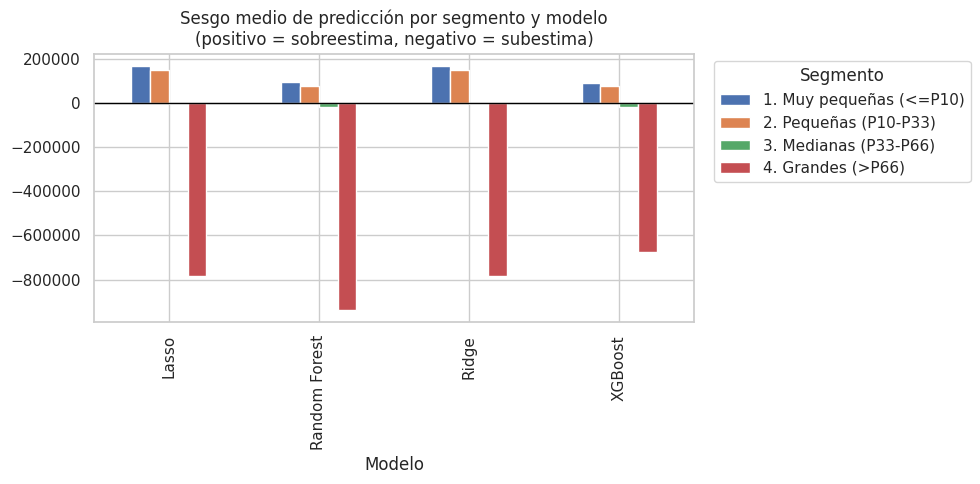

In [ ]:
p10, p33, p66 = np.percentile(y_test_real, [10, 33, 66])

def segmentar(v):
    if v <= p10: return '1. Muy pequeñas (<=P10)'
    elif v <= p33: return '2. Pequeñas (P10-P33)'
    elif v <= p66: return '3. Medianas (P33-P66)'
    else: return '4. Grandes (>P66)'

segmentos = pd.Series(y_test_real).apply(segmentar)

rows = []
for name in ['XGBoost', 'Random Forest', 'Ridge', 'Lasso']:
    y_pred_real = predictions_real[name]
    for seg in sorted(segmentos.unique()):
        mask = (segmentos == seg).values
        y_true_seg, y_pred_seg = y_test_real[mask], y_pred_real[mask]
        rows.append({
            'Modelo': name, 'Segmento': seg, 'n': mask.sum(),
            'MAE (t)': mean_absolute_error(y_true_seg, y_pred_seg),
            'R2': r2_score(y_true_seg, y_pred_seg) if mask.sum() > 1 else np.nan,
            'MAPE (%)': np.mean(np.abs((y_true_seg - y_pred_seg) / y_true_seg)) * 100,
            'Sesgo medio (t)': np.mean(y_pred_seg - y_true_seg)
        })

segment_df = pd.DataFrame(rows).set_index(['Modelo', 'Segmento'])
print(segment_df)

fig, ax = plt.subplots(figsize=(10, 5))
segment_df['Sesgo medio (t)'].unstack('Segmento').plot(kind='bar', ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Sesgo medio de predicción por segmento y modelo\n(positivo = sobreestima, negativo = subestima)')
ax.legend(title='Segmento', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Conclusión de la fase:** XGBoost es el modelo con mejor desempeño global (R²=0,608 en escala real, RMSE=0,306 en log10), seguido de Random Forest. Ambos superan ampliamente a Lasso/Ridge (R²≈0,09) y al baseline. Sin embargo, el análisis por segmento revela una limitación importante: **el R² dentro de cada segmento de tamaño es mucho más bajo que el R² global**, y todos los modelos muestran un patrón sistemático de regresión hacia la media (sobreestiman instalaciones pequeñas, subestiman las grandes). Esto indica que el buen R² global proviene principalmente de distinguir correctamente entre categorías de tamaño, más que de una precisión fina dentro de cada categoría — una matización importante a declarar honestamente en la memoria.

## Fase 8 — Interpretabilidad: SHAP y coeficientes lineales

### Conceptos clave

**Interpretabilidad vs. rendimiento:** los modelos de árbol (RF, XGBoost) suelen tener mejor rendimiento predictivo que los lineales, pero son "cajas menos transparentes" — no basta con mirar un coeficiente para saber el efecto de una variable. **SHAP (SHapley Additive exPlanations)** resuelve esto aplicando un concepto de teoría de juegos (valores de Shapley) para asignar, a cada variable y cada predicción individual, una contribución numérica a esa predicción concreta, de forma consistente y aditiva (la suma de todas las contribuciones + el valor base = la predicción final).

**TreeExplainer:** implementación eficiente de SHAP específica para modelos basados en árboles, que calcula los valores exactos (no aproximados) de forma mucho más rápida que el método general.

**Cómo leer un summary plot (beeswarm):** cada punto es una observación del conjunto de test. La posición horizontal indica el impacto de esa variable en esa predicción concreta (a la derecha = aumenta la predicción, a la izquierda = la reduce). El color indica si el valor de la variable en esa fila es alto (rojo) o bajo (azul). Las variables se ordenan de mayor a menor importancia global (de arriba a abajo).

**Cómo leer un dependence plot:** muestra, para una variable concreta, cómo cambia su efecto SHAP a medida que cambia su propio valor. Permite detectar si la relación es lineal, saturada, con umbral, etc. — información que un coeficiente lineal por sí solo no puede mostrar.

In [ ]:
explainer_xgb = shap.TreeExplainer(xgb_best)

SAMPLE_SIZE = 2000
X_test_sample = X_test.sample(SAMPLE_SIZE, random_state=RANDOM_STATE) if len(X_test) > SAMPLE_SIZE else X_test
shap_values_xgb = explainer_xgb.shap_values(X_test_sample)

print(f"SHAP values calculados sobre {X_test_sample.shape[0]} filas de test.")

SHAP values calculados sobre 2000 filas de test.


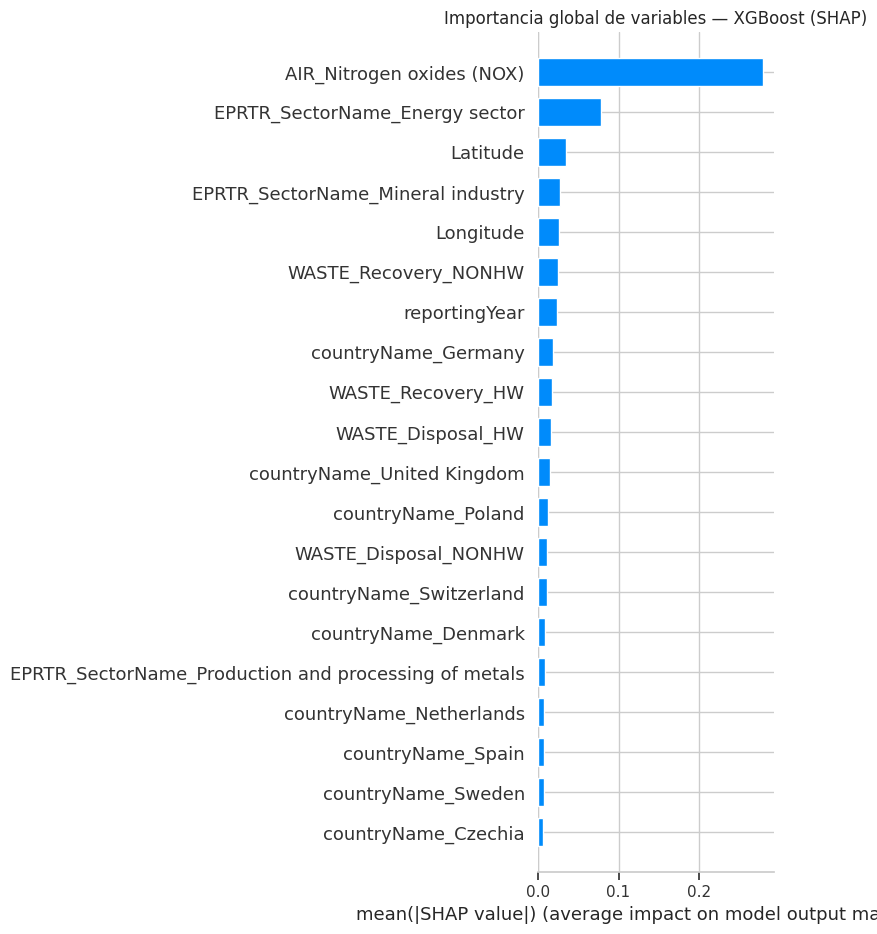

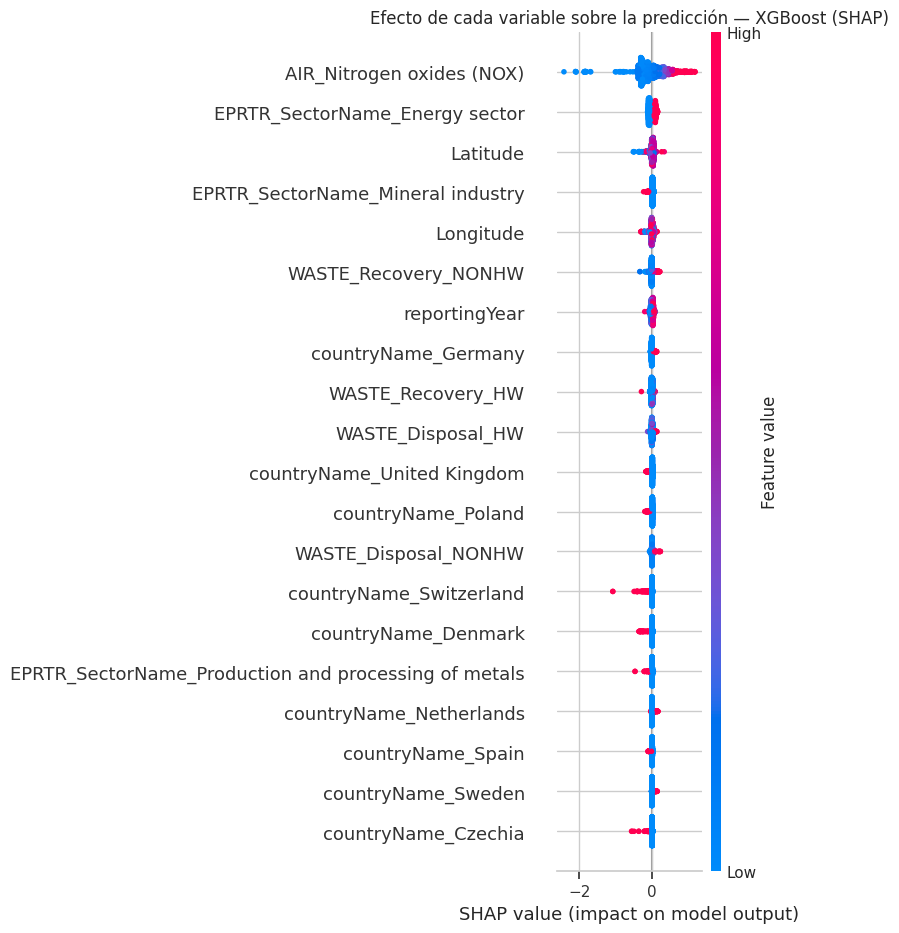

In [ ]:
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values_xgb, X_test_sample, plot_type='bar', show=False)
plt.title('Importancia global de variables — XGBoost (SHAP)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values_xgb, X_test_sample, show=False)
plt.title('Efecto de cada variable sobre la predicción — XGBoost (SHAP)')
plt.tight_layout()
plt.show()

Variable más importante según SHAP: AIR_Nitrogen oxides (NOX)


<Figure size 800x500 with 0 Axes>

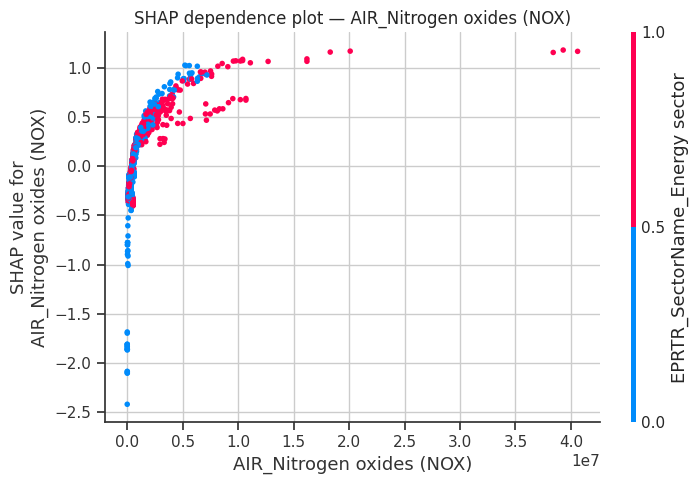

In [ ]:
top_feature = X_test_sample.columns[np.argsort(-np.abs(shap_values_xgb).mean(axis=0))[0]]
print(f"Variable más importante según SHAP: {top_feature}")

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature, shap_values_xgb, X_test_sample, show=False)
plt.title(f'SHAP dependence plot — {top_feature}')
plt.tight_layout()
plt.show()

Top 15 variables por magnitud de coeficiente (Lasso vs Ridge):
                                                    Coef_Lasso  Coef_Ridge
Variable                                                                  
AIR_Nitrogen oxides (NOX)                                0.237       0.237
EPRTR_SectorName_Energy sector                           0.180       0.182
EPRTR_SectorName_Mineral industry                        0.090       0.091
countryName_Denmark                                     -0.089      -0.090
EPRTR_SectorName_Paper and wood production and ...       0.062       0.063
WASTE_Recovery_NONHW                                     0.059       0.059
EPRTR_SectorName_Chemical industry                       0.055       0.056
countryName_Switzerland                                 -0.044      -0.045
Longitude                                                0.032       0.033
WASTE_Disposal_HW                                        0.032       0.032
countryName_Netherlands              

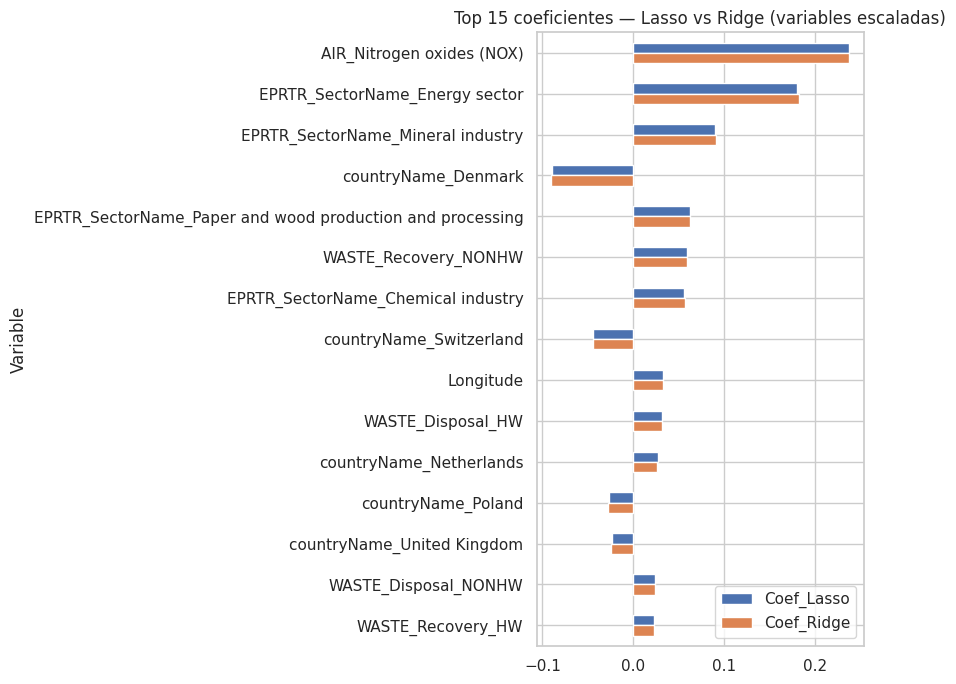

In [ ]:
coef_df = pd.DataFrame({
    'Variable': X_train.columns, 'Coef_Lasso': lasso.coef_, 'Coef_Ridge': ridge.coef_
}).set_index('Variable')
coef_df['Abs_Lasso'] = coef_df['Coef_Lasso'].abs()
coef_df_sorted = coef_df.sort_values('Abs_Lasso', ascending=False)

print("Top 15 variables por magnitud de coeficiente (Lasso vs Ridge):")
print(coef_df_sorted.head(15)[['Coef_Lasso', 'Coef_Ridge']])
print(f"\nVariables con coeficiente Lasso = 0 (eliminadas): {(coef_df['Coef_Lasso'] == 0).sum()} de {len(coef_df)}")

fig, ax = plt.subplots(figsize=(9, 7))
coef_df_sorted.head(15)[['Coef_Lasso', 'Coef_Ridge']].plot(kind='barh', ax=ax)
ax.set_title('Top 15 coeficientes — Lasso vs Ridge (variables escaladas)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Conclusión de la fase:** AIR_Nitrogen oxides (NOX) es, de forma consistente entre SHAP y los coeficientes lineales, el predictor más relevante de las emisiones de CO₂ — resultado coherente con la física de la combustión industrial (ambos gases son subproductos del mismo proceso de quema de combustible). El dependence plot revela que esta relación **no es lineal**, sino cóncava/saturada (el efecto crece rápido a valores bajos de NOX y luego se aplana) — esto explica por qué los modelos de árbol superan a los lineales: un modelo lineal fuerza una relación proporcional constante que no existe realmente en los datos. El sector de actividad (especialmente Energy sector) y la ubicación geográfica (probablemente como proxy de la mezcla energética nacional) actúan como factores secundarios pero consistentes en ambos métodos de interpretabilidad.

## Fase 9 — Conclusiones generales del TFM

### Síntesis de resultados

1. **Alcance del modelo:** el estudio se circunscribe a instalaciones industriales europeas cuyas emisiones de CO₂ superan el umbral legal de reporte del E-PRTR (100.000 t/año) — una limitación de alcance derivada de un mecanismo de missingness no aleatorio (MNAR), documentada explícitamente.

2. **Mejor modelo:** XGBoost obtiene el mejor desempeño predictivo (R²=0,608 en escala real; R²=0,675 en log10), seguido de cerca por Random Forest. Ambos superan claramente a los modelos lineales regularizados (Lasso/Ridge, R²≈0,09-0,42 según la escala).

3. **Por qué los modelos de árbol superan a los lineales:** la relación entre el predictor más importante (NOX) y el target no es lineal, sino saturada — un patrón que solo los modelos basados en árboles pueden capturar sin transformaciones adicionales.

4. **Limitación relevante — regresión hacia la media:** pese al buen R² global, el análisis por segmento de tamaño revela que todos los modelos sobreestiman sistemáticamente instalaciones pequeñas y subestiman las grandes, con R² mucho más bajos dentro de cada segmento que el R² agregado. Esto matiza la interpretación del desempeño del modelo: es bueno distinguiendo "categorías de tamaño", pero menos preciso dentro de cada categoría.

5. **Variable más relevante:** AIR_Nitrogen oxides (NOX) domina la importancia de variables tanto en SHAP como en los coeficientes lineales, seguido del sector de actividad (especialmente energético) y, en menor medida, la ubicación geográfica.

### Limitaciones del estudio

- Población de estudio acotada a grandes emisores (sesgo de selección por umbral de reporte)
- Variables explicativas limitadas a las disponibles con baja tasa de nulos; se descartaron variables con potencial relevancia (ej. SOX) por riesgo de sesgo circular
- Regresión hacia la media en los extremos de la distribución del target
- Búsqueda de hiperparámetros acotada por restricciones computacionales de la infraestructura gratuita utilizada

### Líneas futuras

- Modelo en dos etapas (clasificación de "reporta/no reporta" + regresión), para extender el estudio a instalaciones bajo el umbral de reporte
- Tratamiento específico para el segmento de instalaciones pequeñas, dado el sesgo de sobreestimación detectado
- Ampliación de la búsqueda de hiperparámetros con mayor capacidad computacional
- Incorporación de variables adicionales del E-PRTR con menor tasa de nulos si se identifican en versiones futuras del registro

---

### Glosario rápido para la exposición

| Término | Definición breve |
|---|---|
| MNAR | Missing Not At Random — el dato falta porque su propio valor determina si se reporta o no |
| Panel de datos | Estructura con dimensión transversal (instalaciones) y temporal (años) |
| Log-transformación | Aplicar logaritmo a una variable muy asimétrica para normalizar su distribución |
| Regularización L1/L2 | Penalización que reduce coeficientes en modelos lineales para evitar sobreajuste (L1=Lasso, elimina variables; L2=Ridge, las reduce sin eliminar) |
| Validación cruzada | Evaluar un modelo repetidamente sobre distintas particiones de los datos para un resultado más robusto |
| GroupShuffleSplit | Partición train-test que respeta grupos (aquí, instalaciones), evitando fuga de información |
| Winsorización | Acotar valores extremos a un percentil límite, sin eliminar la observación |
| R², MAE, RMSE, MAPE | Métricas de error de un modelo de regresión (ver Fase 7 para definiciones detalladas) |
| SHAP | Método de interpretabilidad basado en teoría de juegos que asigna una contribución a cada variable en cada predicción |
| Regresión hacia la media | Tendencia de un modelo a predecir cerca del promedio, subestimando extremos altos y sobreestimando extremos bajos |

In [ ]:
joblib.dump(xgb_best, MODELOS + 'model_co2.pkl')
print(f"\n  Modelo guardado en: {MODELOS}model_co2.pkl")

if os.path.exists(MODELOS + 'model_co2.pkl'):
    size = os.path.getsize(MODELOS + 'model_co2.pkl') / 1024**2
    print(f"  ✓ model_co2.pkl — {size:.1f} MB")
else:
    print(f"  ✗ Error — fichero no encontrado")


  Modelo guardado en: /content/drive/MyDrive/TFM/modelos/model_co2.pkl
  ✓ model_co2.pkl — 0.5 MB


# 4. Clasificación de sector industrial a partir del perfil de emisiones
### Red neuronal aplicada a datos del registro europe E-PRTR

**Fuente de datos:** European Pollutant Release and Transfer Register (E-PRTR)

**Objetivo:** Determinar si es posible identificar el sector industrial de una instalación únicamente a partir de su perfil de emisiones de contaminantes, sin usar ningún dato descriptivo.


### Cómo está organizado este contenido

| Fase | Contenido |
|------|-----------|
| 1 | Carga y verificación del dataset |
| 2 | Variable objetivo: codificación del sector industrial |
| 3 | Selección y transformación de features |
| 4 | Partición train / validation / test |
| 5 | Escalado con StandardScaler |
| 6 | Pesos de clase: compensación del desbalanceo |
| 7 | Construcción de la red neuronal |
| 8 | Entrenamiento del modelo |
| 9 | Evaluación: métricas globales y matriz de confusión |
| 10 | Curva de entrenamientoAnálisis  |
| 11 | SHAP: importancia de features por sector |
| 12 | Conclusiones |
| 13 | Guardar modelo y scaler |

In [ ]:
# ── Imports clasificación
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (f1_score, accuracy_score,
                             confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import shap

# ── Reset semilla (incluye TensorFlow)
SEED = 42
RANDOM_STATE = SEED
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"Librerías clasificación cargadas | SEED reseteado: {SEED}")

Librerías clasificación cargadas | SEED reseteado: 42


## Fase 1 - Carga y verificación del dataset

El dataset combina una dimensión transversal
(distintas instalaciones industriales) con una dimensión temporal
(distintos años de reporte). Cada fila representa una combinación
única instalación × año.

In [ ]:

assert df_merged.shape == (81005, 45), "Error: dimensiones inesperadas en df_merged"
print(f"✓ Dataset verificado: {df_merged.shape[0]:,} filas x {df_merged.shape[1]} columnas")

✓ Dataset verificado: 81,005 filas x 45 columnas


## Fase 2 - Variable objetivo: codificación del sector industrial

**Objetivo de la clasificación:** predecir a qué sector industrial
pertenece una instalación únicamente a partir de su perfil de emisiones.

**Variable target:** `EPRTR_SectorCode` — 9 sectores industriales
según la clasificación E-PRTR (Energía, Metales, Minerales, Química,
Residuos, Papel, Ganadería, Alimentación, Otras actividades).


In [ ]:
df_merged['EPRTR_SectorCode'] = df_merged['EPRTR_SectorCode'].astype(int)

print('Distribución de sectores')

sector_counts = df_merged.groupby(['EPRTR_SectorCode', 'EPRTR_SectorName']).size().reset_index(name='count')
sector_counts['pct'] = (sector_counts['count'] /len(df_merged) * 100)

print(sector_counts.to_string(index=False))

Distribución de sectores
 EPRTR_SectorCode                                                EPRTR_SectorName  count    pct
                1                                                   Energy sector  19318 23.848
                2                             Production and processing of metals   7201  8.890
                3                                                Mineral industry  11862 14.644
                4                                               Chemical industry   8738 10.787
                5                                 Waste and wastewater management  15115 18.659
                6                        Paper and wood production and processing   4380  5.407
                7                  Intensive livestock production and aquaculture   6639  8.196
                8 Animal and vegetable products from the food and beverage sector   3357  4.144
                9                                                Other activities   4395  5.426


**Decisión con LabelEncoder:** Keras requiere que las
clases empiecen en 0 y sean consecutivas. Como los sectores van
de 1 a 9, se aplica LabelEncoder para convertirlos a índices 0-8.
Esto no introduce ningún sesgo en la red neuronal porque
la capa de salida softmax trata cada índice como una categoría
independiente, no como un valor numérico ordenado.

**Desbalanceo entre clases:** la distribución no es uniforme. El sector de  
Energía representa el 23.8% del dataset mientras que Alimentación
solo el 4.1%. Este desbalanceo se compensará en la Fase 6 con
pesos de clase.

In [ ]:
le = LabelEncoder()
y = le.fit_transform(df_merged['EPRTR_SectorCode'])

print(f'Clases originales: {le.classes_}')
print(f'Índices resultantes: 0 a {len(le.classes_)-1}')
print(f'Total ejemplos: {len(y):,}')

Clases originales: [1 2 3 4 5 6 7 8 9]
Índices resultantes: 0 a 8
Total ejemplos: 81,005


## Fase 3 — Selección y transformación de features

### 3.1 Selección de variables explicativas

Las features son exclusivamente las columnas de emisiones y residuos
(prefijos AIR_, WATER_, WASTE_, TRANSFER_) con 35 variables en total.

Se excluyen deliberadamente:
- `facilityName`, `city`, `FacilityInspireId`: son identificadores,
  no aportan información significativa.
- `Longitude`, `Latitude`: la ubicación geográfica no debería
  determinar el sector industrial.
- `countryName`: podría introducir sesgo geográfico.
- `reportingYear`: el sector no cambia según el año.
- `EPRTR_SectorName`, `EPRTRAnnexIMainActivity`: son el target
  expresado de otra forma y usarlas sería un error.

In [ ]:
VALUE_COLS = [c for c in df_merged.columns if c.startswith(('AIR_', 'WATER_', 'WASTE_', 'TRANSFER_'))]

print(f'número de features seleccionadas: {len(VALUE_COLS)}')

for c in VALUE_COLS:
    print(c)

número de features seleccionadas: 35
AIR_Ammonia (NH3)
AIR_Carbon dioxide (CO2)
AIR_Carbon dioxide (CO2) excluding biomass
AIR_Carbon monoxide (CO)
AIR_Chlorine and inorganic compounds (as HCl)
AIR_Hydrochlorofluorocarbons (HCFCs)
AIR_Mercury and compounds (as Hg)
AIR_Methane (CH4)
AIR_Nickel and compounds (as Ni)
AIR_Nitrogen oxides (NOX)
AIR_Nitrous oxide (N2O)
AIR_Non-methane volatile organic compounds (NMVOC)
AIR_Particulate matter (PM10)
AIR_Sulphur oxides (SOX)
AIR_Zinc and compounds (as Zn)
WASTE_Disposal_HW
WASTE_Disposal_NONHW
WASTE_Recovery_HW
WASTE_Recovery_NONHW
WATER_Arsenic and compounds (as As)
WATER_Chlorides (as total Cl)
WATER_Copper and compounds (as Cu)
WATER_Fluorides (as total F)
WATER_Lead and compounds (as Pb)
WATER_Nickel and compounds (as Ni)
WATER_Total nitrogen
WATER_Total organic carbon(as total C or COD/3) (TOC)
WATER_Total phosphorus
WATER_Zinc and compounds (as Zn)
TRANSFER_Nickel and compounds (as Ni)
TRANSFER_Phenols (as total C)
TRANSFER_Total nitroge

### 3.2 Mecanismo de missingness y creación de flags

**Mecanismo MNAR (Missing Not At Random):** el E-PRTR exige reportar
un contaminante únicamente si la instalación supera un umbral legal
específico. Un valor nulo no es un error de medición sino un indicativo de que
la instalación no supera el umbral o que ese contaminante no aplica
a su actividad.

**Decisión aplicada de flags de reporte:** en vez de imputar
directamente, se crea una columna binaria `reported_X` por cada
contaminante que indica si la instalación reportó ese valor (1)
o no (0). Esto preserva la información de "qué reporta y qué no
reporta" cada instalación, que es en sí misma informativa del
sector.

El resultado son **70 features** (35 valores + 35 flags).

In [ ]:
X = df_merged[VALUE_COLS].copy()

flag_cols = []
for c in VALUE_COLS:
    flag_name = f'reported_{c}'
    X[flag_name] = X[c].notna().astype(int)
    flag_cols.append(flag_name)

print(f'flag creados: {len(flag_cols)}')

flag creados: 35


Veamos los NaN por columna

In [ ]:
nan_count = X[VALUE_COLS].isnull().sum()
nan_pct = (nan_count / len(X) * 100).round(1)

summary = pd.DataFrame({
    'Nan': nan_count,
    '% Nan': nan_pct,
    'nº de reportados': len(X) - nan_count,
    '% reportados': (100 -nan_pct)
}).sort_values('% Nan', ascending= False)

print(summary)
print("=" * 60)


print(f'Total celdas: {X[VALUE_COLS].size:,}')
print(f'Total NaN: {X[VALUE_COLS].isnull().sum().sum():,}')
print(f"Total con valor: {X[VALUE_COLS].notna().sum().sum():,}")
print(f"% NaN global: {X[VALUE_COLS].isnull().sum().sum() / X[VALUE_COLS].size * 100:.1f}%")

                                                      Nan  % Nan  \
TRANSFER_Total phosphorus                           80134 98.900   
TRANSFER_Phenols (as total C)                       79649 98.300   
TRANSFER_Total nitrogen                             79605 98.300   
TRANSFER_Nickel and compounds (as Ni)               79413 98.000   
TRANSFER_Zinc and compounds (as Zn)                 79343 97.900   
WATER_Fluorides (as total F)                        77897 96.200   
WATER_Total phosphorus                              77844 96.100   
TRANSFER_Total organic carbon(as total C or COD...  77790 96.000   
WATER_Lead and compounds (as Pb)                    77677 95.900   
WATER_Chlorides (as total Cl)                       77150 95.200   
WATER_Total nitrogen                                76502 94.400   
WATER_Copper and compounds (as Cu)                  76424 94.300   
AIR_Hydrochlorofluorocarbons (HCFCs)                76214 94.100   
WATER_Arsenic and compounds (as As)             

Comprobamos que las columnas Transfer son las más vacías (entre 97% y 99% de NaN), lo que nos indica que menos del 3% de las instalaciones transfieren contaminantes fuera de la planta. Aunque no es mucha información, vamos a mantener estas columnas.
Los contaminantes Waste son los que contienen más valores completos, entre 30% y 74% de instalaciones que sí reportan residuos. Cabe destacar las siguientes columnas:

- Waste_Recovery_HW: las toneladas de residuos peligrosos enviados a reciclaje, es la columna más completa con 73.5% de valores reales.

- Waste_Disposal_HW: toneladas de residuos peligrosos enviados para su eliminación, con un 69.7% de valores.

- Waste_Recovery_NOHW: toneladas de residuos no peligrosos enviados a reciclaje, con un 51.6% de valores reportados.

- Waste_Disposal_NOHW: toneladas de residuos no peligrosos enviados para su eliminación, con un 39.6%

Los contaminantes más reportados son Air_Nitrogen oxides (NOX) y Air_Carbon Dioxide (CO2) con un 47% y 41% respectivamente.

Importante tener en cuenta que hay un 84.5% de NaN en este conjunto de features, y al haber creado las columnas de qué instalación reporta contaminates y la que no, nos proporciona información valiosa para distinguir entre sectores.

### 3.3 Imputación y transformación logarítmica

Una vez creados los flags, los NaN se imputan a 0 (interpretación:
"no aplica o no supera el umbral") y se aplica **log1p** para
suavizar la escala. Como las emisiones industriales van de unidades
a millones de kg/año, una escala sin transformar haría que
el modelo prestara toda su atención a los valores extremos.

**`log1p(x) = log(x+1)`** — el +1 evita el problema de log(0)
para instalaciones que no reportaron ese contaminante.

In [ ]:
# Imputación a 0

X[VALUE_COLS] = X[VALUE_COLS].fillna(0)

# aplicamos un log1p para suavizar la escala
X[VALUE_COLS] = np.log1p(X[VALUE_COLS])

print(f'Nan restantes tras imputación: {X.isnull().sum().sum()}')
print(X.shape)
print("=" * 60)
print(X.head(5))

Nan restantes tras imputación: 0
(81005, 70)
   AIR_Ammonia (NH3)  AIR_Carbon dioxide (CO2)  \
0              0.000                    18.479   
1              0.000                    18.440   
2              0.000                    18.440   
3              0.000                    18.488   
4              0.000                    18.460   

   AIR_Carbon dioxide (CO2) excluding biomass  AIR_Carbon monoxide (CO)  \
0                                       0.000                     0.000   
1                                       0.000                     0.000   
2                                       0.000                     0.000   
3                                       0.000                     0.000   
4                                       0.000                     0.000   

   AIR_Chlorine and inorganic compounds (as HCl)  \
0                                          0.000   
1                                          0.000   
2                                          0.00

## Fase 4 — División de train, validation & test

Se separan explícitamente
tres conjuntos con propósitos distintos:

| Conjunto | Tamaño | Propósito |
|----------|--------|-----------|
| Train | 64% (51.843 filas) | La red aprende y ajusta sus pesos |
| Validation | 16% (12.961 filas) | Monitoriza el entrenamiento y activa EarlyStopping |
| Test | 20% (16.201 filas) | Evaluación final: la red nunca lo ve durante el entrenamiento |

**stratify=y** en ambos splits garantiza que la proporción de los
9 sectores se mantiene igual en los tres conjuntos, especialmente
importante para los sectores minoritarios como Alimentación (4.1%)
que sin stratify podrían quedar mal representados en alguno de ellos.

Se separa el conjunto de validación con `train_test_split` antes del entrenamiento: es más riguroso que usar `validation_split` en `model.fit`, porque garantiza que el split sea estratificado y reproducible con la semilla que se ha fijado anteriormente.

In [ ]:
#separación del set de test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train_val: {X_train_val.shape}")
print(f"X_test:      {X_test.shape}")

X_train_val: (64804, 70)
X_test:      (16201, 70)


In [ ]:
#separación de validación del train (64% de train y 16% de validación)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_train_val
)

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")

X_train: (51843, 70)
X_val:   (12961, 70)


## Fase 5 — Escalado con StandardScaler

**Qué hace:** normaliza cada feature para que tenga media 0 y
desviación típica 1, algo imprescindible para redes neuronales,
ya que asume que los pesos están aproximadamente en ese rango.

**Decisión de aplicar fit solo sobre train:** el scaler
aprende la media y desviación típica exclusivamente de `X_train`.  
Aplicar `fit` sobre validation o test introduciría fuga de datos y por lo tanto, el modelo estaría usando información de datos que no debería
haber visto durante el preprocesado.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'X_train_scaled: {X_train_scaled.shape}')
print(f'X_val_scaled: {X_val_scaled.shape}')
print(f'X_test_scaled: {X_test_scaled.shape}')

print(f"\n  Media de X_train_scaled (debe ser ~0): {X_train_scaled.mean():.4f}")
print(f"  Std de X_train_scaled (debe ser ~1):   {X_train_scaled.std():.4f}")

X_train_scaled: (51843, 70)
X_val_scaled: (12961, 70)
X_test_scaled: (16201, 70)

  Media de X_train_scaled (debe ser ~0): 0.0000
  Std de X_train_scaled (debe ser ~1):   1.0000


## Fase 6 — Pesos de clase: compensación del desbalanceo

La distribución de sectores no es uniforme.
La realidad es:

| Sector | % real | Desviación |
|--------|--------|------------|
| Energía (1) | 23.8% | +12.7pp — sobrerrepresentado |
| Alimentación (8) | 4.1% | -7.0pp — infrarrepresentado |

Sin compensación, la red aprendería a ignorar los sectores
minoritarios.

**Solución con `compute_class_weight='balanced'`:** calcula
automáticamente un peso inversamente proporcional al número
de ejemplos de cada clase. Durante el entrenamiento, un error
en una instalación de Alimentación penalizará 2.68 veces más
que un error en Energía, forzando a la red a aprender también
los patrones de los sectores pequeños.

**Importante:** los pesos se calculan sobre `y_train` únicamente —
usar el dataset completo introduciría información de validation
y test en el proceso de entrenamiento.

**Resultado:**
- Sector más penalizado: Alimentación (peso 2.68) — menos representado
- Sector menos penalizado: Energía (peso 0.47) — más representado

In [ ]:
clases = np.unique(y_train)
pesos= compute_class_weight(
    class_weight='balanced',
    classes = clases,
    y= y_train
)

class_weight_dict = dict(zip(clases, pesos))

for idx, peso in class_weight_dict.items():
    nombre = le.inverse_transform([idx])[0]
    sector_name = df_merged[df_merged['EPRTR_SectorCode'] == nombre]['EPRTR_SectorName'].iloc[0]


    print(f"  {nombre} | {sector_name:<30} | {peso:.4f}")

  1 | Energy sector                  | 0.4659
  2 | Production and processing of metals | 1.2498
  3 | Mineral industry               | 0.7587
  4 | Chemical industry              | 1.0301
  5 | Waste and wastewater management | 0.5955
  6 | Paper and wood production and processing | 2.0551
  7 | Intensive livestock production and aquaculture | 1.3557
  8 | Animal and vegetable products from the food and beverage sector | 2.6805
  9 | Other activities               | 2.0478


## Fase 7 - Construcción de la red neuronal

**Tipo de red:** red neuronal densa (fully connected) con arquitectura
de embudo: las capas van reduciendo progresivamente el número de
neuronas hasta llegar a la capa de salida con 9 neuronas (una por sector).

**Arquitectura elegida:**

| Capa | Neuronas | Activación | Regularización |
|------|----------|------------|----------------|
| Input | 70 | — | — |
| Dense 1 | 256 | ReLU | BatchNorm + Dropout 0.3 |
| Dense 2 | 128 | ReLU | BatchNorm + Dropout 0.3 |
| Dense 3 | 64 | ReLU | BatchNorm + Dropout 0.3 |
| Output | 9 | Softmax | — |

**Uso de ReLU en capas ocultas:** evita el problema del
vanishing gradient que afecta a sigmoid y tanh en redes profundas,
y es computacionalmente más eficiente.

**Uso de Softmax en la capa de salida:** convierte las 9
activaciones en probabilidades que suman 1, es decir, cada neurona
representa la probabilidad de que la instalación pertenezca
a ese sector. La clase predicha es la de mayor probabilidad.

**BatchNormalization:** normaliza las activaciones
entre capas en cada batch, estabilizando el entrenamiento
y actuando como regularizador implícito.

**Dropout (0.3):** desactiva aleatoriamente
el 30% de las neuronas en cada paso de entrenamiento,
forzando a la red a no depender de neuronas concretas
y reduciendo el overfitting. Solo se activa durante
el entrenamiento ya que en evaluación y predicción todas
las neuronas están activas.

**`tf.keras.backend.clear_session()`** al principio:
limpia el grafo global de Keras antes de construir el modelo,
evitando errores de nombres duplicados si se reejcuta la celda.

In [ ]:
n_features = X_train_scaled.shape[1]
n_clases = len(le.classes_)

tf.keras.backend.clear_session()

inputs = tf.keras.Input(shape=(n_features,), name='input')

capa_densa_1 = layers.Dense(256, activation='relu', name='dense_1')(inputs)
norm_1 =layers.BatchNormalization()(capa_densa_1)
dropout_1 = layers.Dropout(0.3)(norm_1)


capa_densa_2 = layers.Dense(128, activation='relu', name='dense_2')(dropout_1)
norm_2 =layers.BatchNormalization()(capa_densa_2)
dropout_2 = layers.Dropout(0.3)(norm_2)


capa_densa_3 = layers.Dense(64, activation='relu', name='dense_3')(dropout_2)
norm_3 =layers.BatchNormalization()(capa_densa_3)
dropout_3 = layers.Dropout(0.3)(norm_3)

outputs= layers.Dense(n_clases, activation='softmax', name='output')(dropout_3)

model = keras.Model(inputs=inputs, outputs=outputs, name='clasificador_sector')

model.summary()

Model: "clasificador_sector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,705 (241.04 KB)

 Trainable params: 60,809 (237.54 KB)

 Non-trainable params: 896 (3.50 KB)

## Fase 8 — Compilación y entrenamiento

**Función de pérdida usada `sparse_categorical_crossentropy`:**
adecuada para clasificación multiclase cuando las etiquetas
son enteros (0-8), no vectores one-hot.

**Optimizador Adam:** algoritmo de optimización
que ajusta el learning rate automáticamente durante el
entrenamiento. Es el estándar para redes neuronales densas.

**EarlyStopping con `restore_best_weights=True`:** monitoriza
la `val_loss` en cada época y para el entrenamiento si no
mejora durante 5 épocas consecutivas y evita el
sobreentrenamiento sin necesidad de ajustar manualmente
el número de épocas.

**`class_weight`:** pesos calculados en la Fase 6 que
penalizan más los errores en sectores minoritarios
durante el entrenamiento.

**Resultado del entrenamiento:**
- épocas entrenadas: 50 (alcanzó el límite sin que EarlyStopping parase)
- Mejor época: 49 (val_loss = 0.6452, val_accuracy = 0.7854)
- El modelo siguió mejorando prácticamente hasta el final.

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callback= keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history= model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[callback],
    verbose=1
)

Epoch 1/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.5856 - loss: 1.2400 - val_accuracy: 0.7042 - val_loss: 0.9059
Epoch 2/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6731 - loss: 0.9700 - val_accuracy: 0.7282 - val_loss: 0.8282
Epoch 3/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.6951 - loss: 0.9033 - val_accuracy: 0.7375 - val_loss: 0.8039
Epoch 4/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7034 - loss: 0.8752 - val_accuracy: 0.7433 - val_loss: 0.7839
Epoch 5/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7132 - loss: 0.8481 - val_accuracy: 0.7486 - val_loss: 0.7647
Epoch 6/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7188 - loss: 0.8333 - val_accuracy: 0.7525 - val_loss: 0.7546
Epoch 7/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7221 - loss: 0.8209 - val_accuracy: 0.7571 - val_loss: 0.7405
Epoch 8/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7254 - loss: 0.8080 - val_

## Fase 9 — Evaluación: métricas globales y matriz de confusión.

**Métricas utilizadas:**

| Métrica | Fórmula (idea) | Cómo se interpreta |
|---------|---------------|-------------------|
| Accuracy | % de predicciones correctas | Fácil de interpretar pero engañosa con desbalanceo |
| F1-macro | Media del F1 de cada clase, sin ponderar por tamaño | Más justa con clases desbalanceadas — trata igual a todos los sectores |
| Precision | De las predicciones de clase X, ¿cuántas son correctas? | Mide los falsos positivos |
| Recall | De los ejemplos reales de clase X, ¿cuántos detectó el modelo? | Mide los falsos negativos |

En este caso se aplica el F1-macro en lugar de accuracy porque el F1-macro penaliza igualmente los errores en sectores grandes y pequeños, mientras que accuracy se fijaría en sectores más grandes con estas 9 clases desbalanceadas.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test loss: {test_loss:.4f}')

Test accuracy: 0.7827
Test loss: 0.6504


In [ ]:
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred_sector = np.argmax(y_pred_proba, axis=1)

f1 = f1_score(y_test, y_pred_sector, average='macro')
print(f'F1-macro: {f1:.4f}')

print('Informe de clasificación')
target_names = [f"Sector {le.classes_[i]} - {df_merged[df_merged['EPRTR_SectorCode']==le.classes_[i]]['EPRTR_SectorName'].iloc[0][:25]}"
                for i in range(len(le.classes_))]
print(classification_report(y_test, y_pred_sector, target_names=target_names))

F1-macro: 0.7651
Informe de clasificación
                                      precision    recall  f1-score   support

            Sector 1 - Energy sector       0.84      0.72      0.78      3864
Sector 2 - Production and processing       0.80      0.75      0.78      1440
         Sector 3 - Mineral industry       0.72      0.71      0.72      2372
        Sector 4 - Chemical industry       0.78      0.64      0.70      1748
Sector 5 - Waste and wastewater mana       0.87      0.91      0.89      3023
Sector 6 - Paper and wood production       0.71      0.80      0.75       876
Sector 7 - Intensive livestock produ       0.90      0.99      0.94      1328
Sector 8 - Animal and vegetable prod       0.51      0.75      0.61       671
         Sector 9 - Other activities       0.62      0.87      0.72       879

                            accuracy                           0.78     16201
                           macro avg       0.75      0.79      0.77     16201
                    

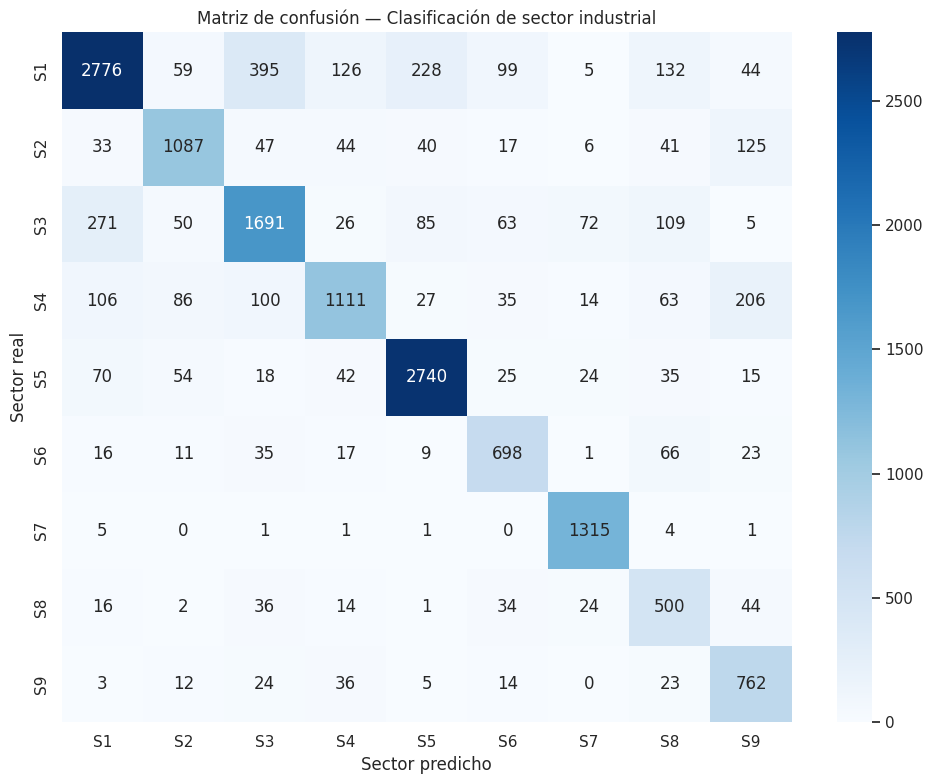

In [ ]:
cm = confusion_matrix(y_test, y_pred_sector)

sector_labels = [f"S{le.classes_[i]}" for i in range(len(le.classes_))]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sector_labels,
            yticklabels=sector_labels)
plt.title('Matriz de confusión — Clasificación de sector industrial')
plt.ylabel('Sector real')
plt.xlabel('Sector predicho')
plt.tight_layout()
plt.show()

**Resultados sobre el conjunto de test (16.201 instalaciones):**

- Test accuracy: 0.7827
- F1-macro: 0.7651
- Test loss: 0.6504


**Análisis por sector:**
- **Mejor resultado:** Ganadería intensiva (F1=0.94, recall=0.99)
  este sector tiene un perfil de emisiones muy característico y distintivo
  del resto, lo que facilita su identificación.
- **Peor resultado:** Alimentación y bebidas (F1=0.61) —
  sector minoritario (4.1%) cuyo perfil de emisiones se solapa
  con Minerales y Otras actividades.
- **Sectores bien identificados:** Residuos (F1=0.89),
  Ganadería (F1=0.94) y Metales (F1=0.78).

En resumen, el modelo identifica correctamente el sector industrial en el 78% de los casos, a partir de su perfil de emisiones. Esto indica que cada sector produce contaminantes característicos que la red neuronal es capaz de aprender y generalizar.
La confusión entre sectores con contaminantes similares (Alimentación vs Minerales) es coherente con la realidad industrial y no representa un error metodológico.

## Fase 10 — Curva de entrenamiento

La evolución de accuracy y loss en train
y validation a lo largo de las épocas nos facilita cómo interpretar el comportamiento del entrenamiento.


**Resultado:** la val_accuracy es ligeramente
superior a la train_accuracy a lo largo del entrenamiento, lo que indica ausencia de overfitting. El Dropout y BatchNormalization han funcionado
correctamente como regularizadores. El modelo entrenó
50 épocas completas alcanzando el mejor resultado en la 49 (val_loss=0.6452), lo que sugiere que con más épocas podría seguir mejorando marginalmente.

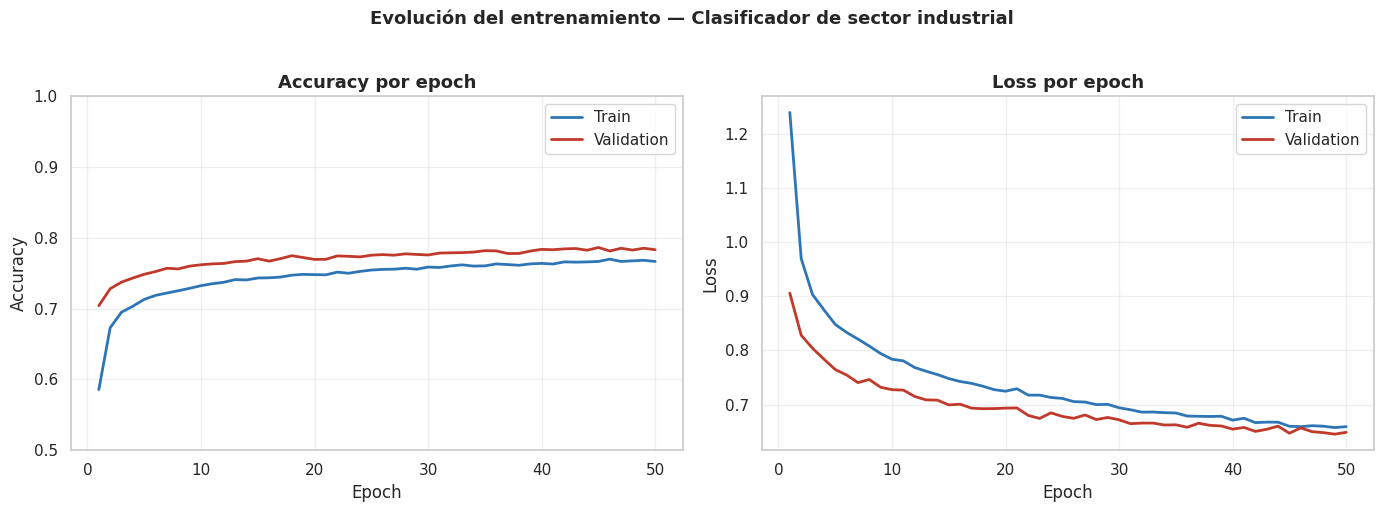


  Epochs entrenados: 50
  Mejor val_accuracy: 0.7864
  Mejor val_loss:     0.6452
  Epoch del mejor resultado: 49


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['accuracy']) + 1)

# Accuracy
ax1.plot(epochs_range, history.history['accuracy'],
         label='Train', color='#2E75B6', linewidth=2)
ax1.plot(epochs_range, history.history['val_accuracy'],
         label='Validation', color='#C0392B', linewidth=2)
ax1.set_title('Accuracy por epoch', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.5, 1.0)

# Loss
ax2.plot(epochs_range, history.history['loss'],
         label='Train', color='#2E75B6', linewidth=2)
ax2.plot(epochs_range, history.history['val_loss'],
         label='Validation', color='#C0392B', linewidth=2)
ax2.set_title('Loss por epoch', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Evolución del entrenamiento — Clasificador de sector industrial',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


print(f"\n  Epochs entrenados: {len(history.history['accuracy'])}")
print(f"  Mejor val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  Mejor val_loss:     {min(history.history['val_loss']):.4f}")
print(f"  Epoch del mejor resultado: {history.history['val_loss'].index(min(history.history['val_loss'])) + 1}")

## Fase 11 — Análisis SHAP: importancia de features por sector

**Uso de SHAP:** SHapley Additive exPlanations es un método de
interpretabilidad basado en teoría de juegos que asigna a cada
feature y cada predicción individual una contribución numérica
(cuánto ha influenciado esa variable para predecir un sector concreto).

**Implementación:** se usa `DeepExplainer`, la implementación
de SHAP específica para redes neuronales, calculada
sobre 300 ejemplos de test con 100 ejemplos de background de train.

In [ ]:
background = X_train_scaled[:100]
explainer = shap.DeepExplainer(model, background)

# sobre un sample de test, calcula la contribución de cada feature para cada predicción
X_test_sample = X_test_scaled[:300]
shap_values = explainer.shap_values(X_test_sample)

shap_array = np.array(shap_values).transpose(2, 0, 1)

print(f"Shape original:      {np.array(shap_values).shape}")
print(f"Shape reorganizado:  {shap_array.shape}")
print(f"Ejemplos de test:    {shap_array.shape[1]}")
print(f"Features:            {shap_array.shape[2]}")
print(f"Clases (sectores):   {shap_array.shape[0]}")

Shape original:      (300, 70, 9)
Shape reorganizado:  (9, 300, 70)
Ejemplos de test:    300
Features:            70
Clases (sectores):   9


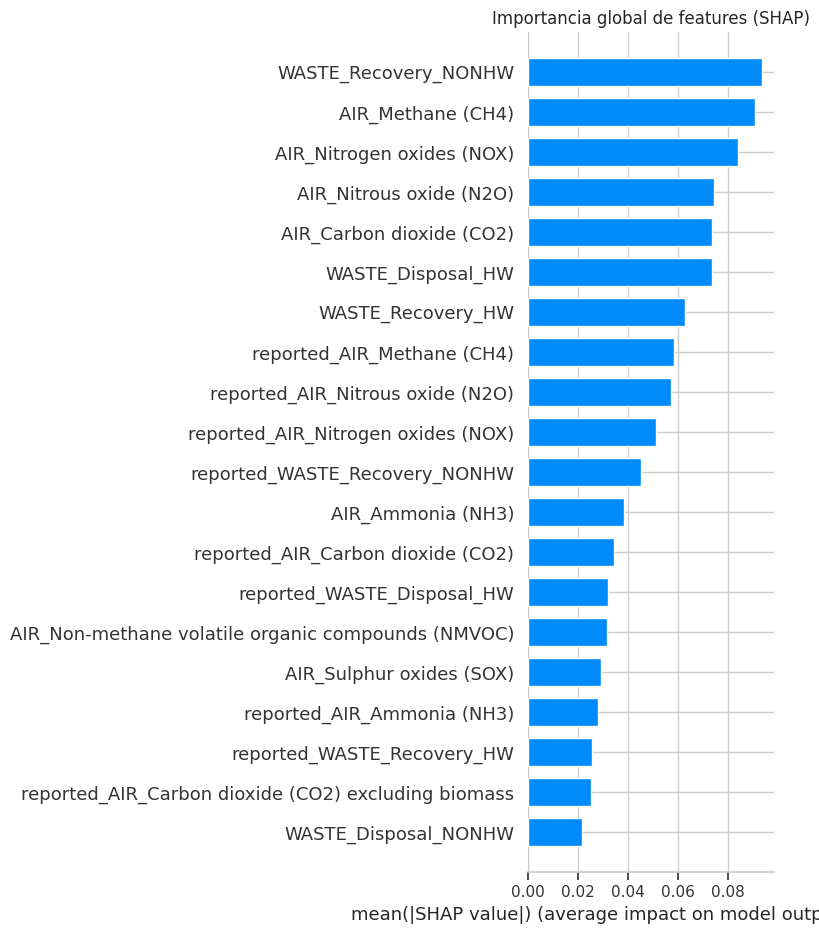

In [ ]:
#importancia promedio sobre todas las clases
shap_abs_mean = np.mean(np.abs(shap_array), axis=0)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_abs_mean,
    X_test_sample,
    feature_names=list(X_train.columns),
    plot_type='bar',
    show=False,
    max_display=20
)
plt.title('Importancia global de features (SHAP)')
plt.tight_layout()
plt.show()

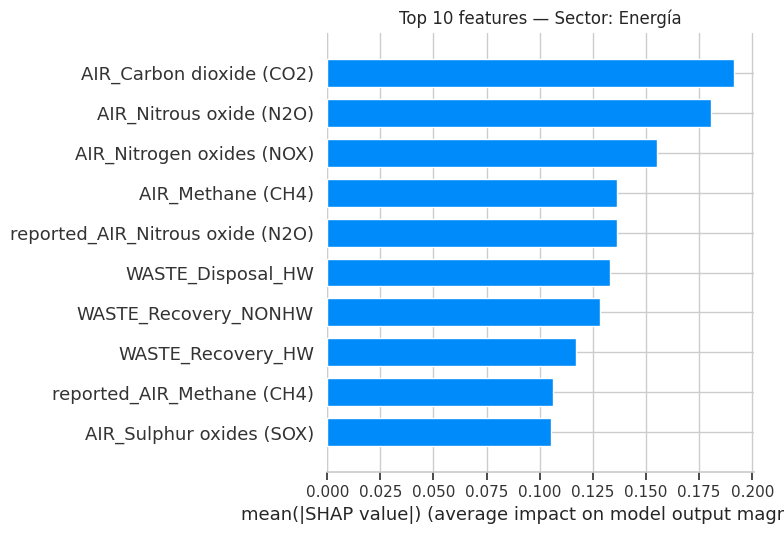

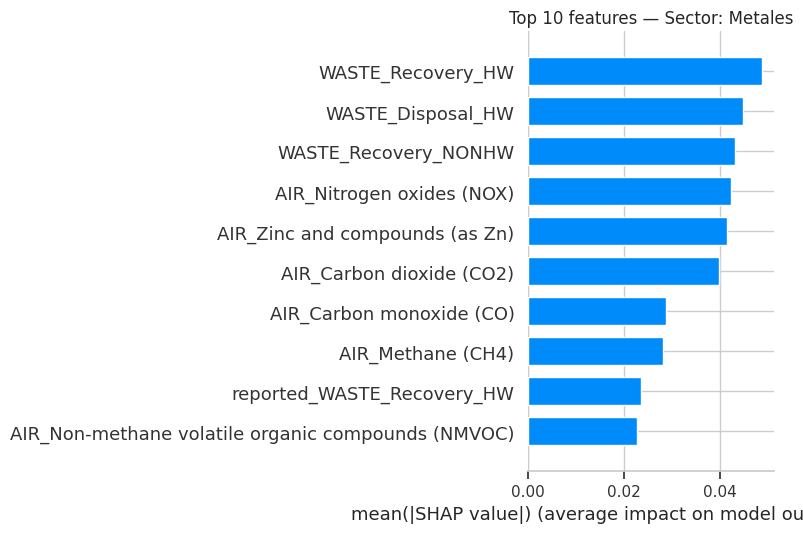

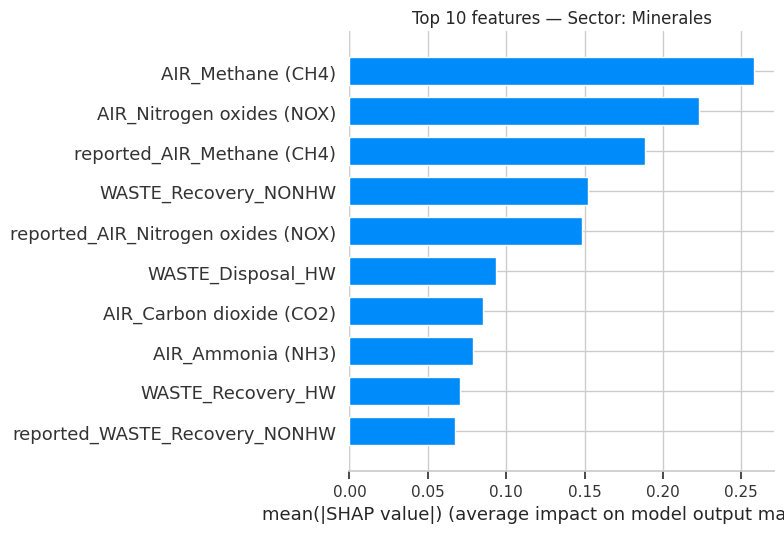

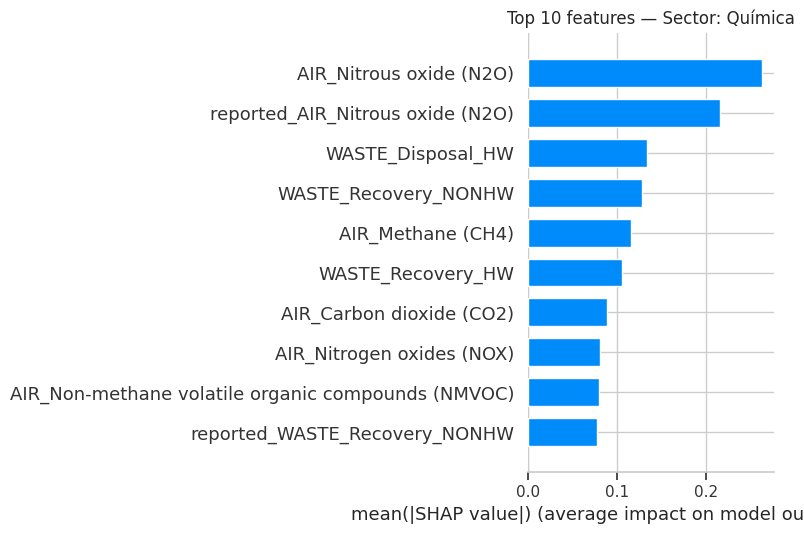

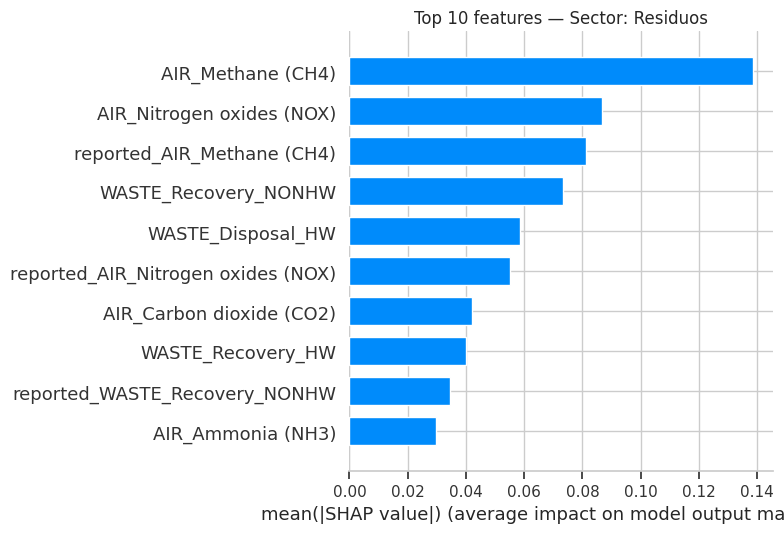

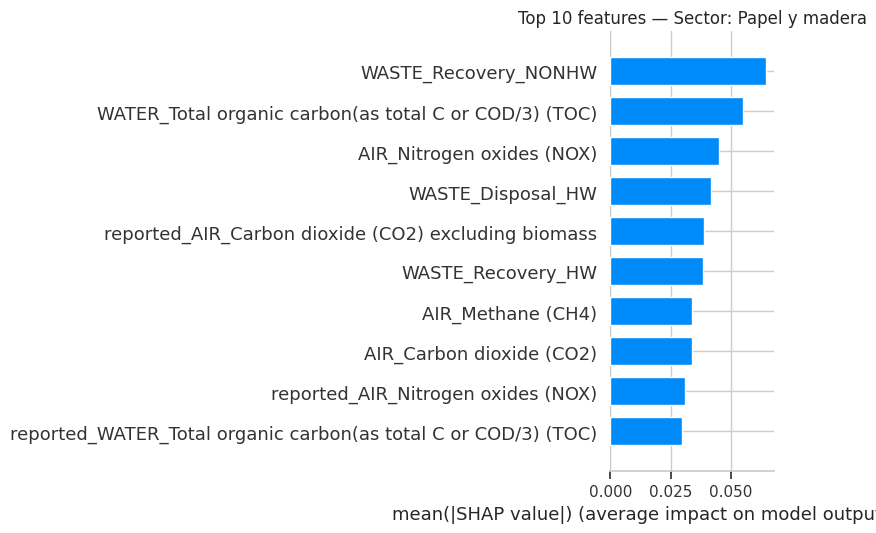

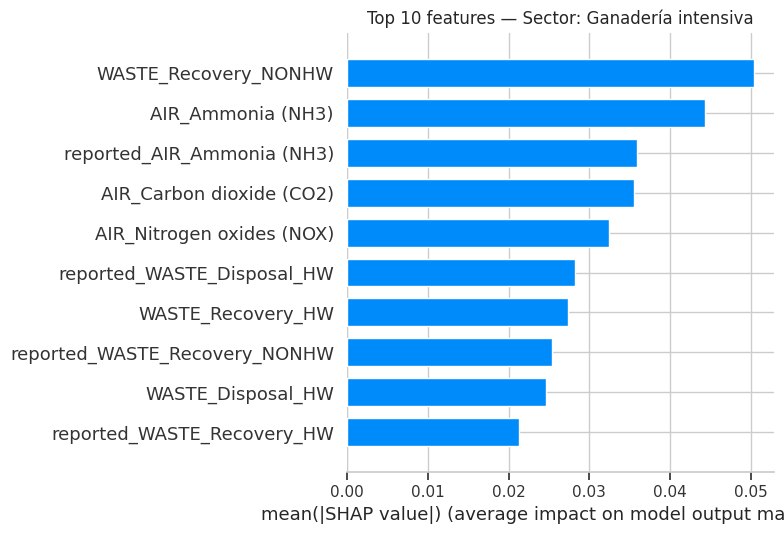

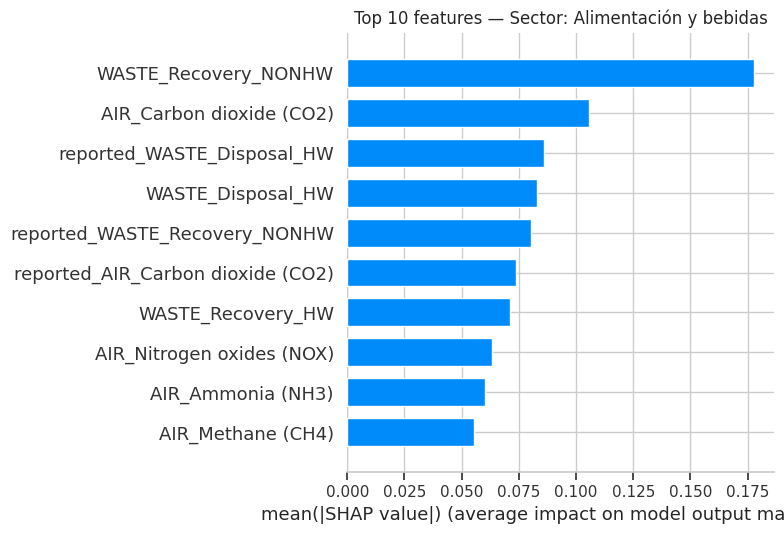

In [ ]:
sector_names = {
    0: 'Energía',
    1: 'Metales',
    2: 'Minerales',
    3: 'Química',
    4: 'Residuos',
    5: 'Papel y madera',
    6: 'Ganadería intensiva',
    7: 'Alimentación y bebidas',
    8: 'Otras actividades'
}

# Top 10 features para todos los sectores excepto Otras actividades
for clase_idx in [0, 1, 2, 3, 4, 5, 6, 7]:
    plt.figure(figsize=(14, 10))
    shap.summary_plot(
        shap_array[clase_idx],
        X_test_sample,
        feature_names=list(X_train.columns),
        plot_type='bar',
        max_display=10,
        show=False,

    )
    plt.title(f'Top 10 features — Sector: {sector_names[clase_idx]}')
    plt.tight_layout()
    plt.show()

Recordemos que además de los valores numéricos de emisiones, se crearon los `reported_X`, es decir, las columnas binarias si un sector reportó o no contaminantes. Que aparezcan en como `reported_AIR_Methane (CH4)`como feature importante significa que el hecho de reportar ese contaminante específico ya es una señal suficiente para identificar de qué sector se trata.

**Resultados por sector:**

| Sector | Top features | Interpretación |
|--------|-------------|----------------|
| Energía | CO2, N2O, NOX | Gases de combustión, típico de centrales térmicas |
| Metales | WASTE_Recovery_HW, WASTE_Disposal_HW, WASTE_Recovery_NONHW, NOX | Industria intensiva en residuos peligrosos y semipeligrosos |
| Minerales | CH4, NOX, flag CH4 | Procesos de extracción y calcinación generan metano y óxidos de nitrógeno |
| Química | N2O, flag N2O | El óxido nitroso es un subproducto característico de algunos procesos químicos |
| Residuos | CH4, NOX, flag CH4 | La fermentación de residuos orgánicos genera metano de forma característica |
| Papel y madera | WASTE_Recovery_NONHW, TOC, NOX | Residuos no peligrosos y materia orgánica disuelta (TOC) |
| Ganadería | WASTE_Recovery_NONHW, NH3, flag NH3 | El amoniaco es la señal más característica — confirma el recall de 0.99 |
| Alimentación | WASTE_Recovery_NONHW, CO2 | Residuos orgánicos y algo de combustión, perfil poco diferenciado |

**Conclusión:**

Los resultados nos muestran que la red neuronal ha aprendido patrones coherentes con la realiadad de casa sector industrial. El caso que mejor lo demuestra es la Ganadería intensiva con el amoniaco como contaminante dominante con un recall de 0.99. En cambio, el sector de Alimentación y bebidas es la industria menos diferenciada ya que sus features más importantes son compartidas con otros sectores, lo que explica su F1 de 0.61 y la confusión con la industria de Minerales y Otras actividades.

## Fase 11 — Conclusiones

**Pregunta de investigación:** ¿es posible identificar el sector
industrial de una instalación únicamente a partir de su perfil
de emisiones, sin usar ningún dato descriptivo?

**Respuesta:** sí, con una precisión del 78% (accuracy) y un
F1-macro de 0.77 sobre 9 sectores industriales, un resultado
sólido teniendo en cuenta que algunos sectores tienen perfiles
de emisiones que se solapan.

**Resultados clave:**

- Test accuracy: 0.7827
- F1-macro: 0.7651
- Mejor sector: Ganadería intensiva (F1: 0.94, recall: 0.99)
- Sector más difícil de clasificar: Alimentación y bebidas (F1: 0.61)

**Limitaciones:**

- El sector Alimentación y bebidas (4.1% del dataset) sigue
  siendo el más difícil de identificar, su perfil de emisiones
  se solapa con Minerales y Otras actividades de forma inherente.
- El análisis SHAP revela que el modelo usa principalmente
  residuos y gases de combustión (NOX, CO2, CH4)
  como señales discriminantes.
  
- La red neuronal fue el modelo seleccionado para clasificación por su  capacidad de capturar relaciones no lineales entre los 70 features. Como línea futura, una comparación con XGBoost o Random Forest permitiría cuantificar el valor añadido de la arquitectura neuronal sobre modelos de árbol.

## Fase 12 — Guardar modelo y scaler

Se guardan los artefactos necesarios para la productivización
del modelo con FastAPI:

- **`model_sector.keras`:** modelo de red neuronal en formato
  nativo de Keras.
- **`scaler.pkl`: ** objeto StandardScaler ajustado sobre
  `X_train` — necesario para normalizar los datos de entrada
  antes de pasarlos al modelo en producción

In [ ]:
model.save(MODELOS + 'model_sector.keras')
print(f'modelo guardado en:{MODELOS}model_sector.keras')

joblib.dump(scaler, MODELOS + 'scaler.pkl')
print(f'scaler guardado en:{MODELOS}scaler.pkl')

import os
for fichero in ['model_sector.keras', 'scaler.pkl']:
    ruta = MODELOS + fichero
    if os.path.exists(ruta):
        size = os.path.getsize(ruta) / 1024**2
        print(f"\n  ✓ {fichero} — {size:.1f} MB")
    else:
        print(f"\n  ✗ {fichero} — NO encontrado, revisar ruta")

modelo guardado en:/content/drive/MyDrive/TFM/modelos/model_sector.keras
scaler guardado en:/content/drive/MyDrive/TFM/modelos/scaler.pkl

  ✓ model_sector.keras — 0.8 MB

  ✓ scaler.pkl — 0.0 MB


# 5. Clustering de países — Emisiones industriales en Europa (E-PRTR)

**Objetivo:** agrupar países europeos según su perfil de emisiones industriales (aire, agua, residuos y transferencias de contaminantes) mediante técnicas de *clustering* no supervisado, para identificar patrones comunes de comportamiento ambiental entre países.

**Pregunta de investigación:** ¿qué países tienen perfiles de
emisiones industriales similares, y qué los diferencia?

### Partes del análisis
I.    Verificación del dataset  
II.   Selección de variables (`AIR_*`, `WATER_*`, `WASTE_*`, `TRANSFER_*`)  
III.  Construcción del panel de características por país y año  
IV.   Agregación y normalización a nivel país  
V.    Preprocesamiento para clustering (transformación y escalado)  
VI.   Reducción de dimensionalidad para visualización (PCA)  
VII.  Determinación del número óptimo de clusters  
VIII. Clustering K-Means  
IX.   Clustering jerárquico  
X.    Comparación entre métodos  
XI.   Interpretación de los grupos resultantes  
XII.  Extensión: evolución de los clusters por país y año  
XIII. Conclusiones

**Nota sobre reproducibilidad:** en todo el notebook se utiliza una semilla fija `SEED = 42` en cada paso estocástico (K-Means, PCA, muestreos), de manera que los resultados del clustering **no varían entre ejecuciones**.

In [ ]:
# Imports clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Reset semilla
SEED = 42
RANDOM_STATE = SEED
random.seed(SEED)
np.random.seed(SEED)

print(f"Librerías clustering cargadas | SEED reseteado: {SEED}")

Librerías clustering cargadas | SEED reseteado: 42


##I. Verificación del dataset

In [ ]:
# Verificación rápida
assert df_merged.shape == (81005, 45), "Error: dimensiones inesperadas en df_merged"
print(f"✓ Dataset verificado: {df_merged.shape[0]:,} filas x {df_merged.shape[1]} columnas")

✓ Dataset verificado: 81,005 filas x 45 columnas


## II. Selección de variables

Para caracterizar a cada país se utilizan **todas las dimensiones ambientales disponibles**: emisiones al aire (`AIR_*`), vertidos al agua (`WATER_*`), residuos (`WASTE_*`) y transferencias de contaminantes fuera de la instalación (`TRANSFER_*`).

Se excluyen del clustering las columnas identificadoras, geográficas y de clasificación industrial (`FacilityInspireId`, `facilityName`, `city`, `Longitude`, `Latitude`, `EPRTR_SectorCode`, `EPRTR_SectorName`, `EPRTRAnnexIMainActivity`), ya que no son variables de emisión sino metadatos de la instalación.

In [ ]:
# Grupos de columnas de contaminantes
AIR_COLS      = [c for c in df_merged.columns if c.startswith("AIR_")]
WATER_COLS    = [c for c in df_merged.columns if c.startswith("WATER_")]
WASTE_COLS    = [c for c in df_merged.columns if c.startswith("WASTE_")]
TRANSFER_COLS = [c for c in df_merged.columns if c.startswith("TRANSFER_")]

POLLUTANT_COLS = AIR_COLS + WATER_COLS + WASTE_COLS + TRANSFER_COLS

# Mapa variable -> grupo ambiental, usado más adelante para la interpretación
GROUP_MAP = {}
for c in AIR_COLS:      GROUP_MAP[c] = "AIR"
for c in WATER_COLS:    GROUP_MAP[c] = "WATER"
for c in WASTE_COLS:    GROUP_MAP[c] = "WASTE"
for c in TRANSFER_COLS: GROUP_MAP[c] = "TRANSFER"

print(f"Variables AIR:      {len(AIR_COLS)}")
print(f"Variables WATER:    {len(WATER_COLS)}")
print(f"Variables WASTE:    {len(WASTE_COLS)}")
print(f"Variables TRANSFER: {len(TRANSFER_COLS)}")
print(f"Total variables de contaminantes: {len(POLLUTANT_COLS)}")

Variables AIR:      15
Variables WATER:    10
Variables WASTE:    4
Variables TRANSFER: 6
Total variables de contaminantes: 35


## III. Construcción del panel de características por país y año

Se construye una tabla agregada `país x año`, donde cada celda representa la **suma de las emisiones/transferencias reportadas** por todas las instalaciones de ese país en ese año, para cada uno de los 35 contaminantes.

**Tratamiento de valores faltantes:** un valor nulo en el dataset original significa que la instalación no reportó ese contaminante (habitualmente porque no supera el umbral de reporte obligatorio de E-PRTR, no porque el dato se perdiera). Por ello:
- Al agregar con `sum(min_count=1)`, un país-año donde **ninguna** instalación reportó un contaminante queda como `NaN` (en vez de 0), diferenciando "no reportado por nadie" de "reportado como cero".
- Se conserva además el número de instalaciones únicas que reportaron en cada país-año (`n_facilities`), necesario para normalizar por tamaño del país en el siguiente paso.

In [ ]:
# Agregación país-año: suma de emisiones + conteo de instalaciones
grp_pais_anio = df_merged.groupby(["countryName", "reportingYear"])

panel_sum = grp_pais_anio[POLLUTANT_COLS].sum(min_count=1)
panel_nfac = grp_pais_anio["FacilityInspireId"].nunique().rename("n_facilities")

panel_pais_anio = panel_sum.join(panel_nfac).reset_index()

print(f"Panel país-año: {panel_pais_anio.shape[0]} combinaciones país-año, {panel_pais_anio.shape[1]} columnas")
panel_pais_anio.head()

Panel país-año: 536 combinaciones país-año, 38 columnas


,countryName,reportingYear,AIR_Ammonia (NH3),AIR_Carbon dioxide (CO2),AIR_Carbon dioxide (CO2) excluding biomass,AIR_Carbon monoxide (CO),AIR_Chlorine and inorganic compounds (as HCl),AIR_Hydrochlorofluorocarbons (HCFCs),AIR_Mercury and compounds (as Hg),AIR_Methane (CH4),...,WASTE_Disposal_NONHW,WASTE_Recovery_HW,WASTE_Recovery_NONHW,TRANSFER_Nickel and compounds (as Ni),TRANSFER_Phenols (as total C),TRANSFER_Total nitrogen,TRANSFER_Total organic carbon(as total C or COD/3) (TOC),TRANSFER_Total phosphorus,TRANSFER_Zinc and compounds (as Zn),n_facilities
0,Austria,2007,"119,200.000","26,391,000,000.000",NaN,"89,974,000.000","24,200.000","1,169.000",394.000,"6,915,000.000",...,"558,568.800","116,460.280","426,960.000",936.700,"265,022.300","808,000.000","32,590,000.000","55,500.000","1,371,082.000",62
1,Austria,2008,"132,600.000","27,374,000,000.000",NaN,"73,731,000.000","23,000.000","1,217.000",244.400,"6,584,000.000",...,"661,102.000","119,557.340","457,469.000",175.300,"282,622.400","887,000.000","32,241,000.000","61,370.000","1,292,983.000",63
2,Austria,2009,"133,100.000","24,681,000,000.000",NaN,"60,902,000.000","25,700.000","1,703.000",149.300,"5,830,000.000",...,"747,600.000","108,987.600","373,633.000",182.200,"266,246.000","756,300.000","27,833,900.000","61,700.000","1,403,233.000",59
3,Austria,2010,"129,200.000","28,519,000,000.000",NaN,"58,737,000.000","17,900.000",652.000,258.700,"5,364,000.000",...,"701,009.920","114,096.980","543,632.000",128.800,"251,400.000","744,600.000","27,653,000.000","63,170.000","484,724.000",64
4,Austria,2011,"142,100.000","28,284,000,000.000",NaN,"63,310,000.000","53,800.000",293.000,296.000,"5,530,000.000",...,"767,387.150","111,780.900","645,046.000",101.600,"250,900.000","423,400.000","27,751,000.000","35,820.000","592,779.000",61


In [ ]:
# Cobertura del panel: combinaciones país-año observadas por país
cobertura = (
    panel_pais_anio.groupby("countryName")
    .agg(n_years=("reportingYear", "nunique"),
         n_facilities_total=("n_facilities", "sum"))
    .sort_values("n_years", ascending=False)
)
display(cobertura)

,n_years,n_facilities_total
countryName,,
Austria,18,1159
Belgium,18,2750
Denmark,18,1174
Estonia,18,368
Greece,18,823
Germany,18,12077
France,18,9704
Finland,18,2707
Hungary,18,1087


- 18 países tienen cobertura completa de los 18 años disponibles (2007-2024).
- Reino Unido solo tiene 13 años de cobertura como consecuencia del Brexit a partir del 2020.
- Croacia y Noruega tienen solo 11 años: Croacia se incorporó a la UE en 2013 y Noruega, aunque no es miembro de la UE, participa de forma voluntaria en este registro desde el 2013.
- Alemania y Francia son los países con mayor número de instalaciones (12.077 y 9.704 respectivamente).

## IV. Agregación y normalización a nivel país

El objetivo final es **agrupar países**, no combinaciones país-año. Para pasar del panel país-año a un vector único por país es necesario resolver dos problemas:

1. **Tamaño del país / número de instalaciones:** un país con muchas instalaciones reportará totales más altos solo por su tamaño industrial, no porque sea más "intensivo" en emisiones. Se normaliza dividiendo cada valor por el número de instalaciones que reportaron ese año (`n_facilities`), obteniendo una **emisión media por instalación**.
2. **Dimensión temporal:** cada país tiene una cantidad distinta de años reportados. Se resume el perfil de cada país como el **promedio de sus años disponibles** de la magnitud ya normalizada por instalación.

El resultado es `country_df`: una matriz de **32 países x 35 variables**, donde cada valor representa la emisión/transferencia media anual por instalación de ese contaminante en ese país.

Los NaN se imputan a 0 antes de dividir por `n_facilities`.

In [ ]:
# Normalización por instalación (emisión media por instalación en cada país-año)
panel_norm = panel_pais_anio.copy()
panel_norm[POLLUTANT_COLS] = (
    panel_norm[POLLUTANT_COLS]
    .fillna(0)                                   # sin reporte -> 0 unidades reportadas
    .div(panel_norm["n_facilities"], axis=0)      # por instalación
)

# Agregación a nivel país: promedio de los años disponibles
country_df = panel_norm.groupby("countryName")[POLLUTANT_COLS].mean()

# Metadatos de apoyo (no se usan como variables de clustering, solo para interpretar)
country_meta = panel_pais_anio.groupby("countryName").agg(
    n_years=("reportingYear", "nunique"),
    n_facilities_total=("n_facilities", "sum")
)

print(f"country_df: {country_df.shape[0]} países x {country_df.shape[1]} variables")
country_df.head()

country_df: 32 países x 35 variables


,AIR_Ammonia (NH3),AIR_Carbon dioxide (CO2),AIR_Carbon dioxide (CO2) excluding biomass,AIR_Carbon monoxide (CO),AIR_Chlorine and inorganic compounds (as HCl),AIR_Hydrochlorofluorocarbons (HCFCs),AIR_Mercury and compounds (as Hg),AIR_Methane (CH4),AIR_Nickel and compounds (as Ni),AIR_Nitrogen oxides (NOX),...,WASTE_Disposal_HW,WASTE_Disposal_NONHW,WASTE_Recovery_HW,WASTE_Recovery_NONHW,TRANSFER_Nickel and compounds (as Ni),TRANSFER_Phenols (as total C),TRANSFER_Total nitrogen,TRANSFER_Total organic carbon(as total C or COD/3) (TOC),TRANSFER_Total phosphorus,TRANSFER_Zinc and compounds (as Zn)
countryName,,,,,,,,,,,,,,,,,,,,,
Austria,"2,237.376","427,055,915.568",0.000,"1,625,582.063",603.986,5.874,5.082,"69,890.498",4.436,"215,069.357",...,"2,136.249","13,374.869","1,886.043","14,293.472",3.973,"3,459.241","8,015.194","383,999.493",683.044,"9,382.411"
Belgium,"9,280.434","279,909,678.440",0.000,"1,166,530.670","4,102.406",76.082,4.711,"22,495.379",20.931,"282,018.350",...,"5,361.935","3,397.992","1,791.756","18,883.188",1.072,2.847,"2,198.098","6,021.055",132.865,3.640
Bulgaria,"46,485.880","864,085,158.485","26,030,388.876","1,510,347.221",360.750,0.000,12.443,"161,974.111",34.509,"1,154,688.388",...,600.348,"233,473.109",763.695,"30,786.879",0.356,35.428,"20,298.201","12,306.760","1,166.294",24.950
Croatia,"85,373.039","330,144,696.705",0.000,"303,616.803",147.179,0.000,2.638,"1,221.344",0.000,"389,325.458",...,223.428,"1,149.263",44.664,"3,723.139",1.104,0.000,0.000,0.000,0.000,0.000
Cyprus,"5,877.878","816,263,725.490","495,314,319.667","315,494.682",0.000,0.000,12.275,"85,235.933","1,368.435","1,392,626.144",...,2.026,200.588,149.352,"3,446.532",10.668,0.159,577.778,"2,464.235",149.608,0.000


In [ ]:
# Estadística descriptiva de la matriz país
country_df.describe().T[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
AIR_Ammonia (NH3),"14,663.103","18,508.063",466.865,"7,861.752","85,373.039"
AIR_Carbon dioxide (CO2),"361,929,458.673","219,207,986.135","78,885,984.023","304,259,114.588","985,944,864.847"
AIR_Carbon dioxide (CO2) excluding biomass,"76,218,693.199","138,606,835.201",0.000,0.000,"495,314,319.667"
AIR_Carbon monoxide (CO),"778,984.934","1,357,760.486",0.000,"396,414.910","7,674,880.952"
AIR_Chlorine and inorganic compounds (as HCl),"3,570.330","6,783.051",0.000,"1,471.558","32,787.116"
AIR_Hydrochlorofluorocarbons (HCFCs),33.281,90.041,0.000,3.141,440.394
AIR_Mercury and compounds (as Hg),5.430,6.677,0.000,3.106,27.913
AIR_Methane (CH4),"175,999.444","273,444.745",0.000,"107,687.749","1,454,669.419"
AIR_Nickel and compounds (as Ni),109.706,284.305,0.000,15.525,"1,368.435"
AIR_Nitrogen oxides (NOX),"506,010.589","474,438.895",0.000,"338,393.212","1,971,552.677"


**Análisis de estadística descriptiva**

- Existen escalas muy dispares entre variables: CO₂ tiene una media
  de 362 millones de kg/instalación mientras que el mercurio (Hg)
  tiene una media de 5.4 kg/instalación. Esta diferencia hace imprescindible el escalado antes de hacer el clustering, si no lo hiciéramos el CO₂ y SOX dominarían el resultado final.

- Alta variabilidad entre países: los coeficientes de variación son elevados en casi todas las variables, lo que nos dice que sí existen diferencias reales entre países.

- Varios mínimos en cero: en contaminantes como CO₂.

- SOX tiene el máximo más extremo: (13.6 millones de kg/instalación), es probable que pertenezca a Polonia o a un país con alta dependencia de carbón.

## V. Preprocesamiento para clustering

Las variables de emisión tienen **escalas y distribuciones muy distintas** (desde miligramos de mercurio hasta cientos de millones de kg de CO2) y una fuerte asimetría positiva. Para que el algoritmo de clustering no quede dominado por las variables de mayor magnitud, se aplican dos transformaciones:

1. **Transformación logarítmica (`log1p`)**, que reduce la asimetría y el peso de los valores extremos.
2. **Estandarización (`StandardScaler`)**, que lleva todas las variables a media 0 y desviación estándar 1.


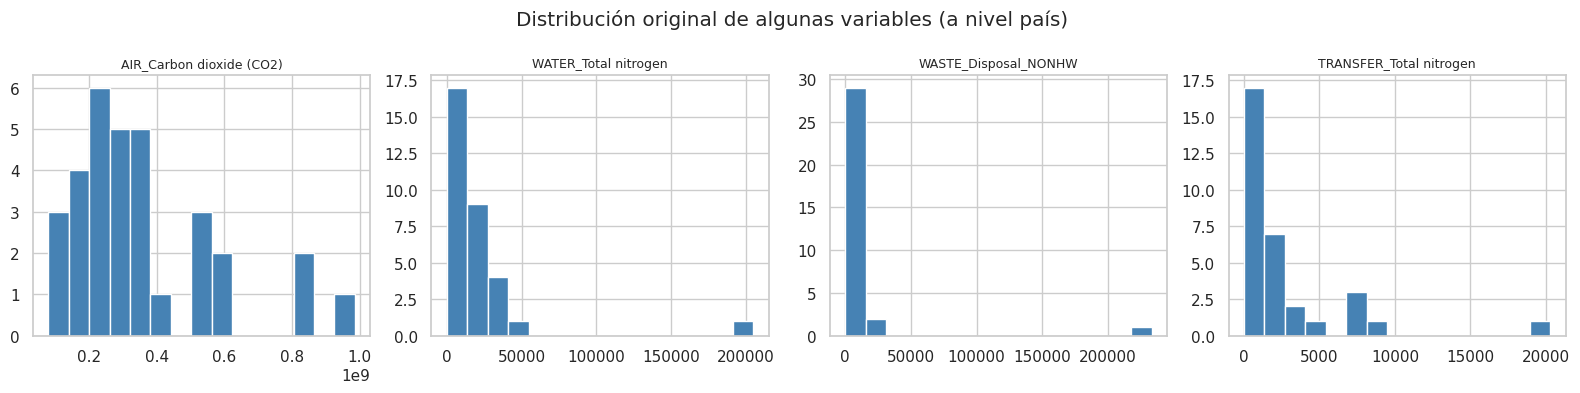

In [ ]:
# Distribución antes de transformar de algunas variables)
muestra_vars = ["AIR_Carbon dioxide (CO2)", "WATER_Total nitrogen", "WASTE_Disposal_NONHW", "TRANSFER_Total nitrogen"]

fig, axes = plt.subplots(1, len(muestra_vars), figsize=(16, 4))
for ax, var in zip(axes, muestra_vars):
    ax.hist(country_df[var], bins=15, color="steelblue", edgecolor="white")
    ax.set_title(var, fontsize=9)
plt.suptitle("Distribución original de algunas variables (a nivel país)")
plt.tight_layout()
plt.show()

In [ ]:
# Transformación logarítmica + escalado estándar
X_log = np.log1p(country_df)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_log),
    index=country_df.index,
    columns=country_df.columns
)

print(f"Matriz preprocesada para clustering: {X_scaled.shape}")
X_scaled.describe().T[["mean", "std", "min", "max"]].head()

Matriz preprocesada para clustering: (32, 35)


,mean,std,min,max
AIR_Ammonia (NH3),-0.000,1.016,-2.501,2.062
AIR_Carbon dioxide (CO2),-0.000,1.016,-2.362,2.024
AIR_Carbon dioxide (CO2) excluding biomass,-0.000,1.016,-0.933,1.267
AIR_Carbon monoxide (CO),0.000,1.016,-4.892,1.328
AIR_Chlorine and inorganic compounds (as HCl),0.000,1.016,-1.896,1.360


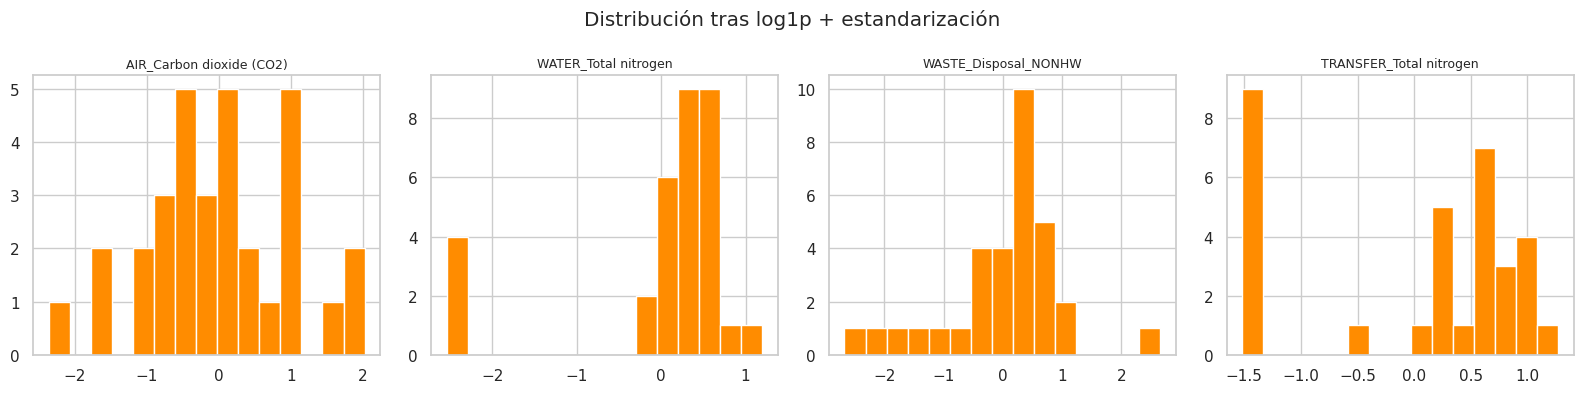

In [ ]:
# Distribución después de transformar las mismas variables presentadas en el punto anterior
fig, axes = plt.subplots(1, len(muestra_vars), figsize=(16, 4))
for ax, var in zip(axes, muestra_vars):
    ax.hist(X_scaled[var], bins=15, color="darkorange", edgecolor="white")
    ax.set_title(var, fontsize=9)
plt.suptitle("Distribución tras log1p + estandarización")
plt.tight_layout()
plt.show()

Tras aplicar log1p + StandardScaler, las mismas 4 variables muestran
distribuciones mucho más simétricas y centradas en 0, especialmente
CO₂ y Nitrógeno en agua, que pasan de distribuciones muy sesgadas
a perfiles aproximadamente normales.
Las variables de residuos y transferencias siguen mostrando algo de asimetría, ya que hay países que no reportan esas categorías (valores concentrados en el extremo izquierdo tras la transformación).

## VI. Reducción de dimensionalidad (PCA)

Se aplica **Análisis de Componentes Principales (PCA)** con dos finalidades:
- Visualizar en 2D la estructura de similitud entre países.
- Cuantificar cuánta varianza total del dataset (35 variables) puede explicarse con pocos componentes.

Se utiliza `random_state=SEED` para que la orientación de los componentes sea reproducible.

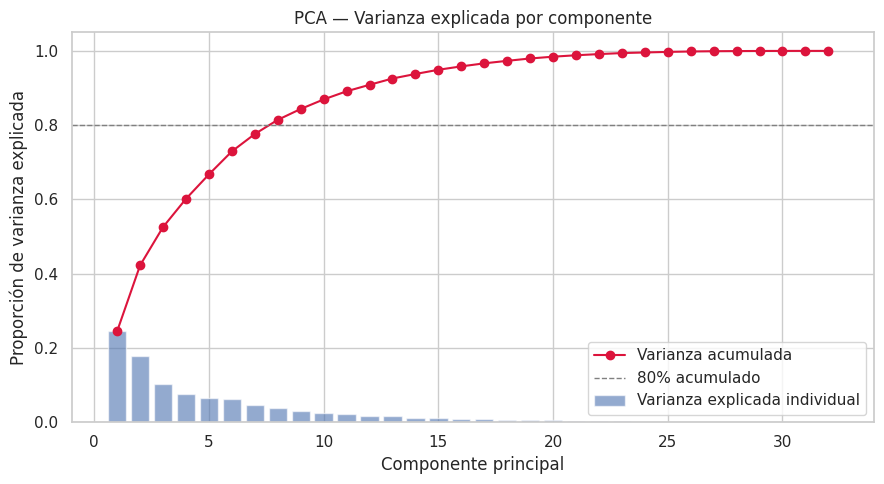

Componentes necesarios para explicar el 80% de la varianza: 8


In [ ]:
# Varianza explicada acumulada (scree plot)
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

plt.figure(figsize=(9, 5))
plt.bar(range(1, len(var_exp) + 1), var_exp, alpha=0.6, label="Varianza explicada individual")
plt.plot(range(1, len(var_exp) + 1), var_acum, color="crimson", marker="o", label="Varianza acumulada")
plt.axhline(0.8, color="gray", linestyle="--", linewidth=1, label="80% acumulado")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza explicada")
plt.title("PCA — Varianza explicada por componente")
plt.legend()
plt.tight_layout()
plt.show()

n_80 = np.argmax(var_acum >= 0.80) + 1
print(f"Componentes necesarios para explicar el 80% de la varianza: {n_80}")

Varianza explicada por PC1 y PC2: 42.3%


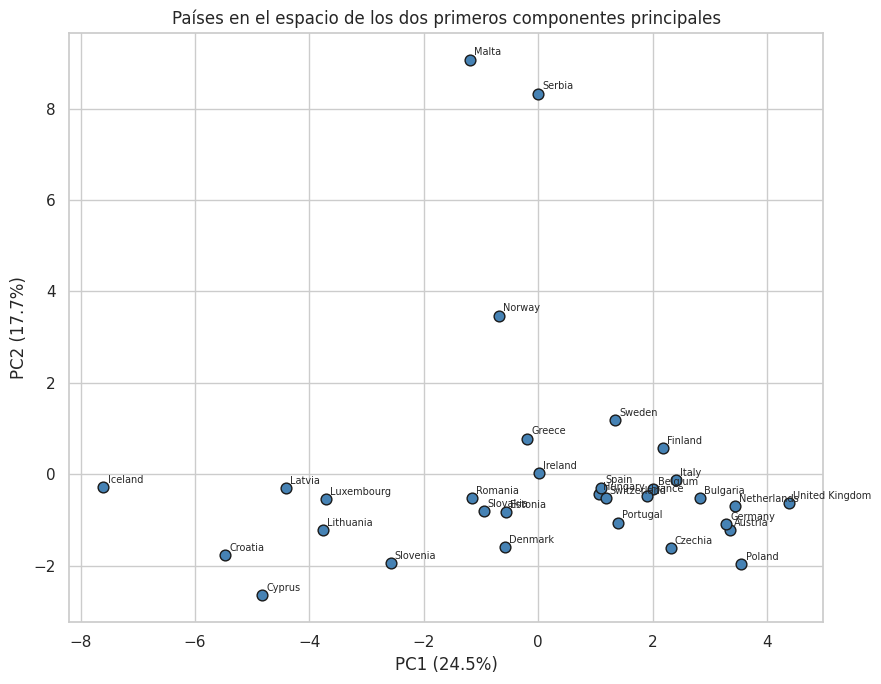

In [ ]:
# PCA a 2 componentes, exclusivamente para visualización
pca_2d = PCA(n_components=2, random_state=SEED)
pcs = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(pcs, index=X_scaled.index, columns=["PC1", "PC2"])

print(f"Varianza explicada por PC1 y PC2: {pca_2d.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(9, 7))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=60, color="steelblue", edgecolor="k")
for pais, row in pca_df.iterrows():
    plt.annotate(pais, (row["PC1"], row["PC2"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
plt.title("Países en el espacio de los dos primeros componentes principales")
plt.tight_layout()
plt.show()

**Varianza explicada:**

- El PC1 captura el 24.5% de la varianza, probablemente muestre los países con más emisiones en todas las categorías versus los que tienen menos.
- El PC2 obtiene el 17.7% adicional, y puede que represente a países con sector ganadero versus países con perfil energético/metales.
- Se necesitan 8 componentes para explicar el 80% de la varianza. Entre el PC1 y el PC2 se explica el 42.2% de la varianza total.

**Mapa de países en 2D**:

- Malta y Serbia aparecen muy aislados en PC2 alto con un
  perfil de emisiones muy distinto al resto, posiblemente se debe a
  su pequeño tamaño industrial.

- Islandia y Chipre se alejan en PC1 negativo. Son países
  pequeños con muy pocas instalaciones y perfil industrial
  muy específico.

- El núcleo central (Alemania, Francia, Reino Unido, Polonia,
  Italia, España) se agrupa en PC1 positivo.

- Noruega destaca en PC2 positivo separada del resto, indicativo de
  su industria de aluminio y metales, muy distinto al mix europeo típico.

In [ ]:
# Variables que más pesan en PC1 y PC2 (cargas / loadings)
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=X_scaled.columns,
    columns=["PC1", "PC2"]
)
loadings["grupo"] = loadings.index.map(GROUP_MAP)

print("Top 8 variables con mayor carga absoluta en PC1:")
display(loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index).head(8))

print("Top 8 variables con mayor carga absoluta en PC2:")
display(loadings.reindex(loadings["PC2"].abs().sort_values(ascending=False).index).head(8))

Top 8 variables con mayor carga absoluta en PC1:


,PC1,PC2,grupo
WATER_Chlorides (as total Cl),0.269,-0.028,WATER
WATER_Total organic carbon(as total C or COD/3) (TOC),0.262,0.110,WATER
TRANSFER_Total organic carbon(as total C or COD/3) (TOC),0.243,-0.178,TRANSFER
TRANSFER_Zinc and compounds (as Zn),0.241,-0.112,TRANSFER
TRANSFER_Phenols (as total C),0.237,-0.124,TRANSFER
WATER_Total nitrogen,0.230,0.142,WATER
TRANSFER_Total nitrogen,0.227,-0.197,TRANSFER
WATER_Zinc and compounds (as Zn),0.219,0.240,WATER


Top 8 variables con mayor carga absoluta en PC2:


,PC1,PC2,grupo
WATER_Arsenic and compounds (as As),0.129,0.323,WATER
AIR_Carbon monoxide (CO),0.018,-0.299,AIR
WATER_Copper and compounds (as Cu),0.203,0.283,WATER
WATER_Lead and compounds (as Pb),0.175,0.274,WATER
WATER_Nickel and compounds (as Ni),0.184,0.268,WATER
AIR_Nitrous oxide (N2O),0.067,-0.265,AIR
WATER_Zinc and compounds (as Zn),0.219,0.240,WATER
AIR_Chlorine and inorganic compounds (as HCl),0.201,-0.199,AIR


**Componentes más significativos**:

- PC1 se refiere a la intensidad de vertidos y transferencias: las variables con mayor peso aquí son principalmente contaminantes de agua (cloruro, TOC, nitrógeno, zinc) y transferencias de contaminantes (TOC, zinc, fenoles, nitrógeno). Este componente separa países con alta actividad industrial en tratamiento de aguas residuales y transferencia de contaminantes a externos.

- PC2 muestra el perfil metalúrgico vs el de combustión: con 2 tipos de contaminantes: valores positivos (como Malta, Serbia y Noruega, donde existen metales pesados en agua), y valores negativos (Croacia, Eslovenia, Chipre, dominados por CO y N₂O, propios de combustión industrial y procesos químicos.

## VII. Determinación del número óptimo de clusters

Antes de fijar el número de grupos `k`, se evalúan varias alternativas con dos criterios complementarios:
- **Método del codo (elbow method):** inercia (suma de distancias al cuadrado dentro de cada cluster) para cada `k`.
- **Coeficiente de silueta (silhouette score):** mide qué tan bien separados y compactos son los clusters (valores más cercanos a 1 son mejores).

En todos los ajustes de K-Means se fija `random_state=SEED` y `n_init=10` para asegurar que el resultado no varíe entre ejecuciones.

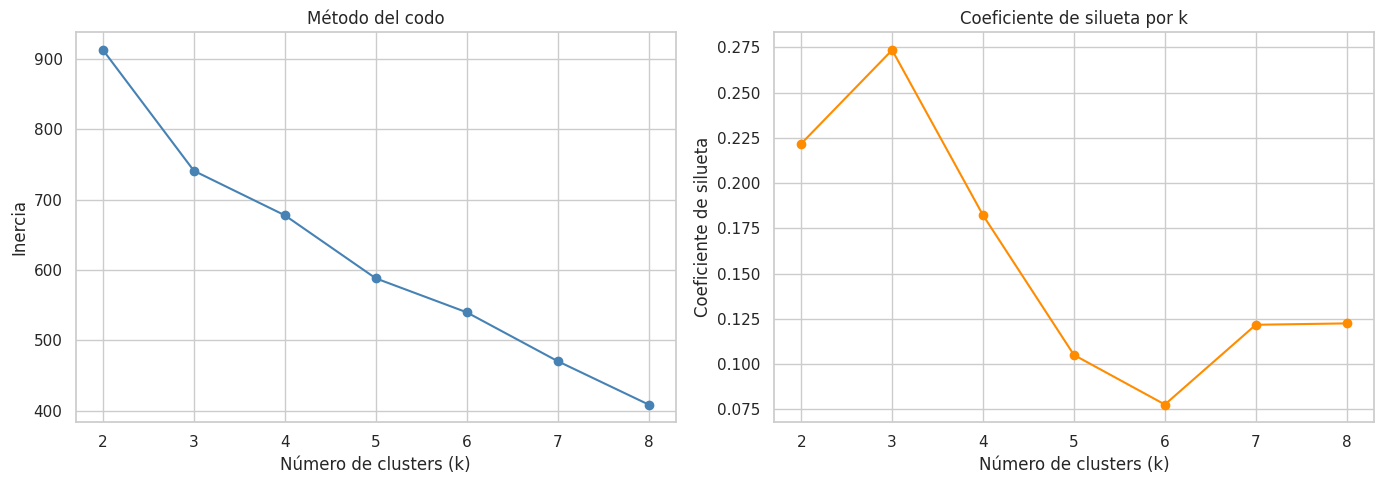

,k,inercia,silueta
0,2,912.383,0.222
1,3,740.745,0.273
2,4,677.553,0.182
3,5,587.980,0.105
4,6,539.726,0.078
5,7,470.328,0.122
6,8,408.672,0.123



Número de clusters seleccionado (máxima silueta): k = 3


In [ ]:
# Elbow method + silhouette score para distintos valores de k
rango_k = range(2, 9)
inercias = []
siluetas = []

for k in rango_k:
    kmeans_k = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_k = kmeans_k.fit_predict(X_scaled)
    inercias.append(kmeans_k.inertia_)
    siluetas.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(rango_k), inercias, marker="o", color="steelblue")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo")

axes[1].plot(list(rango_k), siluetas, marker="o", color="darkorange")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Coeficiente de silueta")
axes[1].set_title("Coeficiente de silueta por k")

plt.tight_layout()
plt.show()

resumen_k = pd.DataFrame({"k": list(rango_k), "inercia": inercias, "silueta": siluetas})
display(resumen_k)

K = resumen_k.loc[resumen_k["silueta"].idxmax(), "k"]
print(f"\nNúmero de clusters seleccionado (máxima silueta): k = {K}")

** Análisis de determinación de número de clusters**:

- Método del codo: la curva de inercia muestra una reducción progresiva sin un codo que destaque, lo que nos indica que no hay un número de clusters natural. Esto es debido a que el dataset tiene pocos puntos (32 países) y alta dimensionalidad (35 variables).

- Coeficiente de silueta: obtenemos un k=3, es decir, se pueden separar en 3 clusters.

## VIII. Clustering K-Means

Se ajusta el modelo final de K-Means con el `k` seleccionado en el paso anterior, usando la semilla fija `SEED` para que la asignación de países a clusters sea siempre la misma.

In [ ]:
# K-Means final
kmeans_final = KMeans(n_clusters=int(K), random_state=SEED, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

country_df["cluster_kmeans"] = labels_kmeans
pca_df["cluster_kmeans"] = labels_kmeans

print("Países por cluster (K-Means):")
for c in sorted(set(labels_kmeans)):
    paises_c = country_df.index[country_df["cluster_kmeans"] == c].tolist()
    print(f"  Cluster {c} ({len(paises_c)} países): {', '.join(paises_c)}")

print(f"\nCoeficiente de silueta global: {silhouette_score(X_scaled, labels_kmeans):.3f}")

Países por cluster (K-Means):
  Cluster 0 (2 países): Malta, Serbia
  Cluster 1 (23 países): Austria, Belgium, Bulgaria, Czechia, Denmark, Estonia, Finland, France, Germany, Greece, Hungary, Ireland, Italy, Netherlands, Norway, Poland, Portugal, Romania, Slovakia, Spain, Sweden, Switzerland, United Kingdom
  Cluster 2 (7 países): Croatia, Cyprus, Iceland, Latvia, Lithuania, Luxembourg, Slovenia

Coeficiente de silueta global: 0.273


** Composición de 3 clusters**:

- Cluster 0: perteneciente a Malta y Serbia. Países con perfiles atípicos respecto del resto europeos.

- Cluster 1: con 23 países (Alemania, Francia, Reino Unido, Italia, España, Polonia, Finlandia, Suecia, Dinamarca, Noruega Bulgaria, Rumanía, Hungría, Chequia). Este es el núcleo industrial europeo y más heterogéneo.

- Cluster 2: 7 países (Croacia, Chipre, Islandia, Latvia, Lituania, Luxemburgo
y Eslovenia) comparten emisiones de baja intensidad y menor diversidad de contaminantes.

El coeficiente de silueta de 0.273 no indica una separación tangible entre clusters pero habrá algo de solapamiento, sobre todo en el Cluster 1.

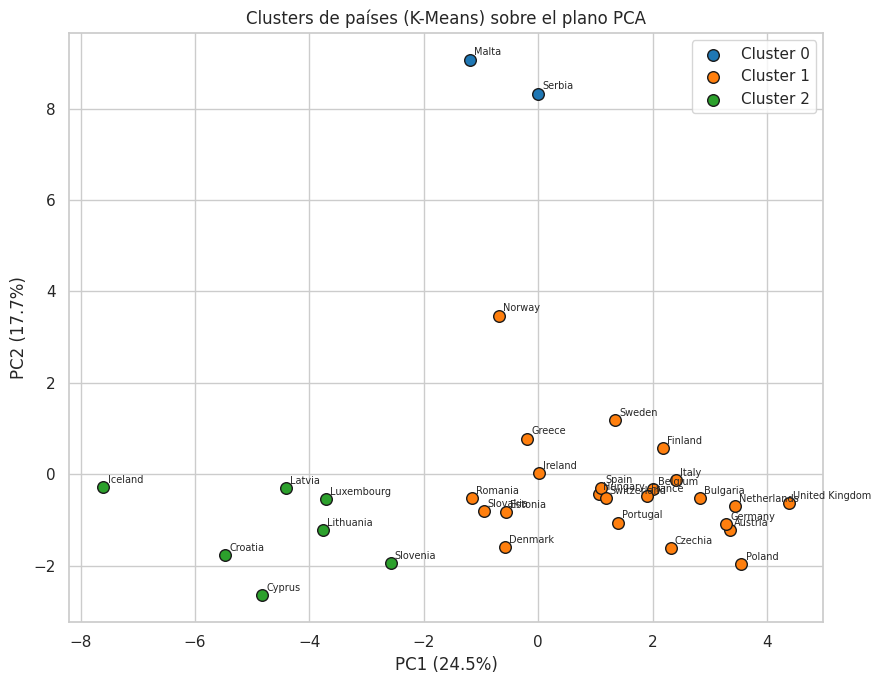

In [ ]:
# Visualización de los clusters K-Means sobre el plano PCA
plt.figure(figsize=(9, 7))
paleta = sns.color_palette("tab10", n_colors=int(K))

for c in sorted(pca_df["cluster_kmeans"].unique()):
    subset = pca_df[pca_df["cluster_kmeans"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], s=70, color=paleta[c], edgecolor="k", label=f"Cluster {c}")

for pais, row in pca_df.iterrows():
    plt.annotate(pais, (row["PC1"], row["PC2"]), fontsize=7, xytext=(3, 3), textcoords="offset points")

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
plt.title("Clusters de países (K-Means) sobre el plano PCA")
plt.legend()
plt.tight_layout()
plt.show()

## IX. Clustering jerárquico

Como complemento a K-Means, se aplica **clustering jerárquico aglomerativo** (enlace de Ward, que minimiza la varianza intra-cluster de forma análoga a K-Means), lo que permite además visualizar la estructura de agrupamiento completa mediante un **dendrograma**, sin necesidad de fijar `k` de antemano.

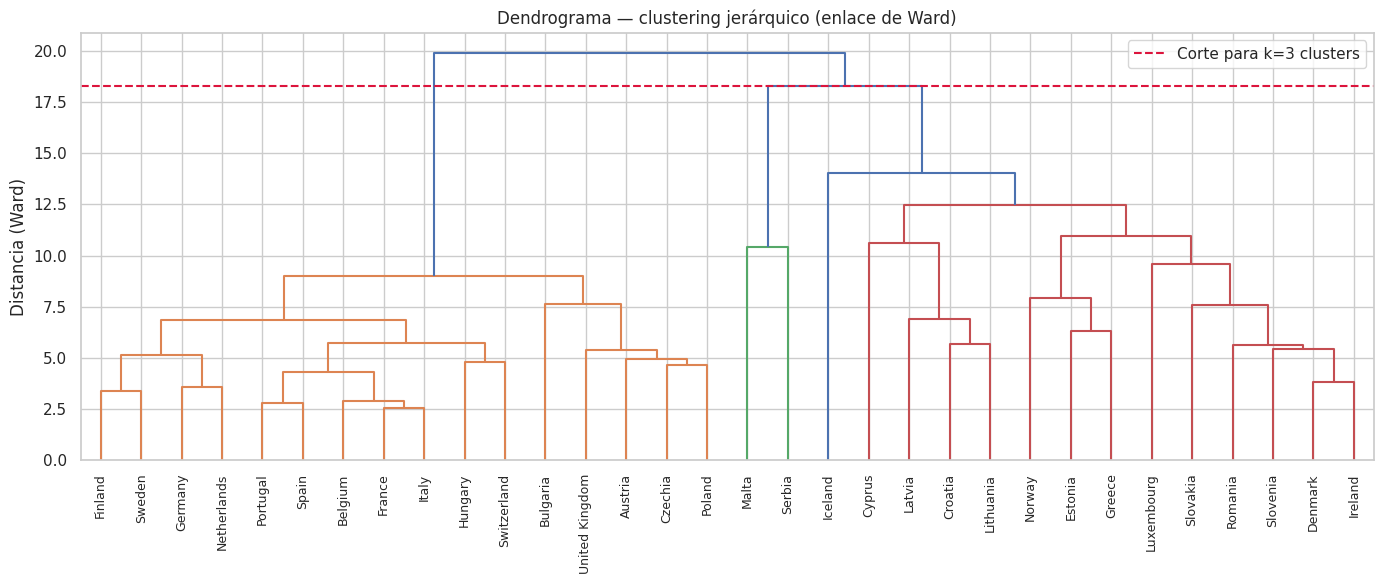

In [ ]:
# Enlace jerárquico (Ward) y dendrograma
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, labels=X_scaled.index.tolist(), leaf_rotation=90, leaf_font_size=9)
plt.axhline(y=Z[-(int(K) - 1), 2], color="crimson", linestyle="--",
            label=f"Corte para k={int(K)} clusters")
plt.title("Dendrograma — clustering jerárquico (enlace de Ward)")
plt.ylabel("Distancia (Ward)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Clustering jerárquico aglomerativo con el mismo k que K-Means, para comparar
agglo = AgglomerativeClustering(n_clusters=int(K), linkage="ward")
labels_jerarquico = agglo.fit_predict(X_scaled)

country_df["cluster_jerarquico"] = labels_jerarquico
pca_df["cluster_jerarquico"] = labels_jerarquico

print("Países por cluster (jerárquico):")
for c in sorted(set(labels_jerarquico)):
    paises_c = country_df.index[country_df["cluster_jerarquico"] == c].tolist()
    print(f"  Cluster {c} ({len(paises_c)} países): {', '.join(paises_c)}")

print(f"\nCoeficiente de silueta global: {silhouette_score(X_scaled, labels_jerarquico):.3f}")

Países por cluster (jerárquico):
  Cluster 0 (14 países): Croatia, Cyprus, Denmark, Estonia, Greece, Iceland, Ireland, Latvia, Lithuania, Luxembourg, Norway, Romania, Slovakia, Slovenia
  Cluster 1 (16 países): Austria, Belgium, Bulgaria, Czechia, Finland, France, Germany, Hungary, Italy, Netherlands, Poland, Portugal, Spain, Sweden, Switzerland, United Kingdom
  Cluster 2 (2 países): Malta, Serbia

Coeficiente de silueta global: 0.188


** Lectura del dendograma**:

- La línea roja discontinua marca el corte para k=3 clusters. Por encima de esa línea quedan 3 ramas independientes.
- Malta y Serbia forman una rama completamente separada del resto como ya hemos visto.
- El resto de países se divide en 2 ramas grandes: los países del núcleo industrial en naranja, y los países con un perfil más reducido en rojo. Se aprecian subgrupos como el bloque de Finlandia, Suecia, Alemania y Países Bajos.

## X. Comparación entre métodos

Se contrastan las particiones obtenidas por K-Means y por clustering jerárquico mediante:
- Una **tabla de contingencia** (crosstab) entre ambas asignaciones.
- El **índice de Rand ajustado (ARI)**, que mide el grado de acuerdo entre dos particiones (1 = coinciden perfectamente, 0 = acuerdo equivalente al azar).

In [ ]:
# Tabla de contingencia y ARI
tabla_contingencia = pd.crosstab(
    country_df["cluster_kmeans"], country_df["cluster_jerarquico"],
    rownames=["K-Means"], colnames=["Jerárquico"]
)
display(tabla_contingencia)

ari = adjusted_rand_score(labels_kmeans, labels_jerarquico)
print(f"Índice de Rand ajustado (ARI) entre K-Means y jerárquico: {ari:.3f}")

Jerárquico,0,1,2
K-Means,,,
0,0,0,2
1,7,16,0
2,7,0,0


Índice de Rand ajustado (ARI) entre K-Means y jerárquico: 0.361


**Conclusión**: KMeans produce clusters más compactos (silueta 0.273 vs 0.188)
y es el método seleccionado para el análisis final.

## XI. Interpretación de los grupos resultantes

Para caracterizar cada cluster de forma objetiva (sin apreciaciones subjetivas), se calcula automáticamente, a partir de la matriz estandarizada (`X_scaled`):

- El **perfil medio por grupo ambiental** (`AIR`, `WATER`, `WASTE`, `TRANSFER`) de cada cluster, visualizado como mapa de calor.
- Las **variables individuales que más distinguen a cada cluster** (las de z-score medio más alto y más bajo dentro del cluster), que se usan para redactar una descripción textual de cada grupo.

Se utiliza la partición de **K-Means** como referencia principal para esta interpretación, dado que es el algoritmo con el que se seleccionó formalmente `k` mediante silueta.

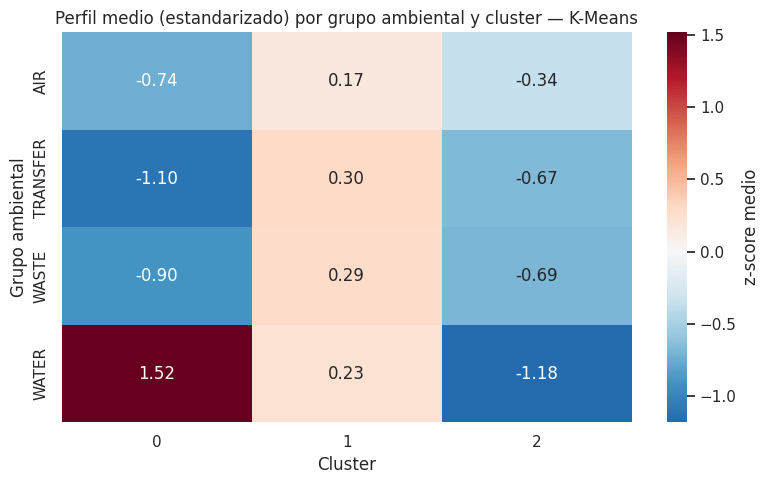

cluster_kmeans,0,1,2
grupo,,,
AIR,-0.740,0.170,-0.340
TRANSFER,-1.100,0.300,-0.670
WASTE,-0.900,0.290,-0.690
WATER,1.520,0.230,-1.180


In [ ]:
# Perfil medio por grupo ambiental (AIR / WATER / WASTE / TRANSFER) y por cluster
Xz = X_scaled.copy()
Xz["cluster_kmeans"] = labels_kmeans

perfil_var_cluster = Xz.groupby("cluster_kmeans")[POLLUTANT_COLS].mean().T
perfil_var_cluster["grupo"] = perfil_var_cluster.index.map(GROUP_MAP)
perfil_grupo_cluster = perfil_var_cluster.groupby("grupo").mean()

plt.figure(figsize=(8, 5))
sns.heatmap(perfil_grupo_cluster, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "z-score medio"})
plt.title("Perfil medio (estandarizado) por grupo ambiental y cluster — K-Means")
plt.xlabel("Cluster")
plt.ylabel("Grupo ambiental")
plt.tight_layout()
plt.show()

display(perfil_grupo_cluster.round(2))

In [ ]:
# Tamaño de cada cluster, en número de países e instalaciones
tamano_cluster = country_df.join(country_meta).groupby("cluster_kmeans").agg(
    n_paises=("cluster_kmeans", "size"),
    n_facilities_total=("n_facilities_total", "sum")
)
display(tamano_cluster)

,n_paises,n_facilities_total
cluster_kmeans,,
0,2,420
1,23,79191
2,7,1394


In [ ]:
# Caracterización automática de cada cluster: variables con z-score más alto y más bajo
def caracterizar_cluster(cluster_id, X_scaled, labels, group_map, top_n=5):
    idx = X_scaled.index[labels == cluster_id]
    perfil = X_scaled.loc[idx].mean().sort_values(ascending=False)

    print(f"\n=== Cluster {cluster_id} — {len(idx)} países ===")
    print(f"Países: {', '.join(idx)}")

    print(f"\nVariables con emisión relativa MÁS ALTA (top {top_n}):")
    for var, z in perfil.head(top_n).items():
        print(f"  - [{group_map[var]}] {var}: z = {z:+.2f}")

    print(f"\nVariables con emisión relativa MÁS BAJA (top {top_n}):")
    for var, z in perfil.tail(top_n).items():
        print(f"  - [{group_map[var]}] {var}: z = {z:+.2f}")

for c in sorted(set(labels_kmeans)):
    caracterizar_cluster(c, X_scaled, labels_kmeans, GROUP_MAP)


=== Cluster 0 — 2 países ===
Países: Malta, Serbia

Variables con emisión relativa MÁS ALTA (top 5):
  - [WATER] WATER_Arsenic and compounds (as As): z = +2.95
  - [WATER] WATER_Copper and compounds (as Cu): z = +2.43
  - [WATER] WATER_Lead and compounds (as Pb): z = +2.40
  - [WATER] WATER_Nickel and compounds (as Ni): z = +2.03
  - [WATER] WATER_Zinc and compounds (as Zn): z = +1.98

Variables con emisión relativa MÁS BAJA (top 5):
  - [TRANSFER] TRANSFER_Total nitrogen: z = -1.52
  - [AIR] AIR_Chlorine and inorganic compounds (as HCl): z = -1.90
  - [AIR] AIR_Non-methane volatile organic compounds (NMVOC): z = -2.39
  - [AIR] AIR_Carbon monoxide (CO): z = -2.80
  - [AIR] AIR_Nitrous oxide (N2O): z = -2.92

=== Cluster 1 — 23 países ===
Países: Austria, Belgium, Bulgaria, Czechia, Denmark, Estonia, Finland, France, Germany, Greece, Hungary, Ireland, Italy, Netherlands, Norway, Poland, Portugal, Romania, Slovakia, Spain, Sweden, Switzerland, United Kingdom

Variables con emisión rela

**Lectura de los resultados:** el mapa de calor y el listado de variables extremas anteriores permiten redactar, a partir de la ejecución real del notebook, una etiqueta descriptiva para cada cluster (por ejemplo: "economías industriales grandes con emisiones atmosféricas y de residuos elevadas por instalación", "países con perfil bajo en la mayoría de contaminantes" o "casos atípicos con vertidos al agua desproporcionadamente altos por instalación").

Es habitual en este tipo de datos que aparezca un cluster muy pequeño (1-2 países): normalmente corresponde a países con **pocas instalaciones E-PRTR**, donde la normalización por instalación amplifica el peso de una o dos plantas con emisiones puntualmente muy altas en algún contaminante. Conviene señalarlo explícitamente como una limitación al interpretar ese grupo, en lugar de tratarlo como una categoría "industrial" plenamente comparable con los demás.

## XII. Extensión: evolución de los clusters por país y año

Los pasos anteriores resumen a cada país en un único perfil promedio. Para aprovechar también la dimensión temporal del panel construido en la Parte III, se repite el mismo procedimiento de preprocesamiento y K-Means **directamente sobre las combinaciones país-año** (`panel_norm`), en lugar de sobre el promedio por país.

Esto permite observar si un país **cambia de cluster a lo largo de los años** (por ejemplo, por cierre/apertura de instalaciones, cambios regulatorios o mejoras tecnológicas), en vez de asumir un perfil ambiental fijo en el tiempo.

In [ ]:
# Preprocesamiento del panel país-año (mismo criterio que a nivel país)
X_log_pa = np.log1p(panel_norm[POLLUTANT_COLS])
X_scaled_pa = StandardScaler().fit_transform(X_log_pa)

# K-Means sobre las observaciones país-año, con la misma semilla
kmeans_pa = KMeans(n_clusters=int(K), random_state=SEED, n_init=10)
panel_norm["cluster_pais_anio"] = kmeans_pa.fit_predict(X_scaled_pa)

print(f"Silueta del clustering país-año (k={int(K)}): "
      f"{silhouette_score(X_scaled_pa, panel_norm['cluster_pais_anio']):.3f}")

panel_norm[["countryName", "reportingYear", "cluster_pais_anio"]].head()

Silueta del clustering país-año (k=3): 0.276


,countryName,reportingYear,cluster_pais_anio
0,Austria,2007,1
1,Austria,2008,1
2,Austria,2009,1
3,Austria,2010,1
4,Austria,2011,1


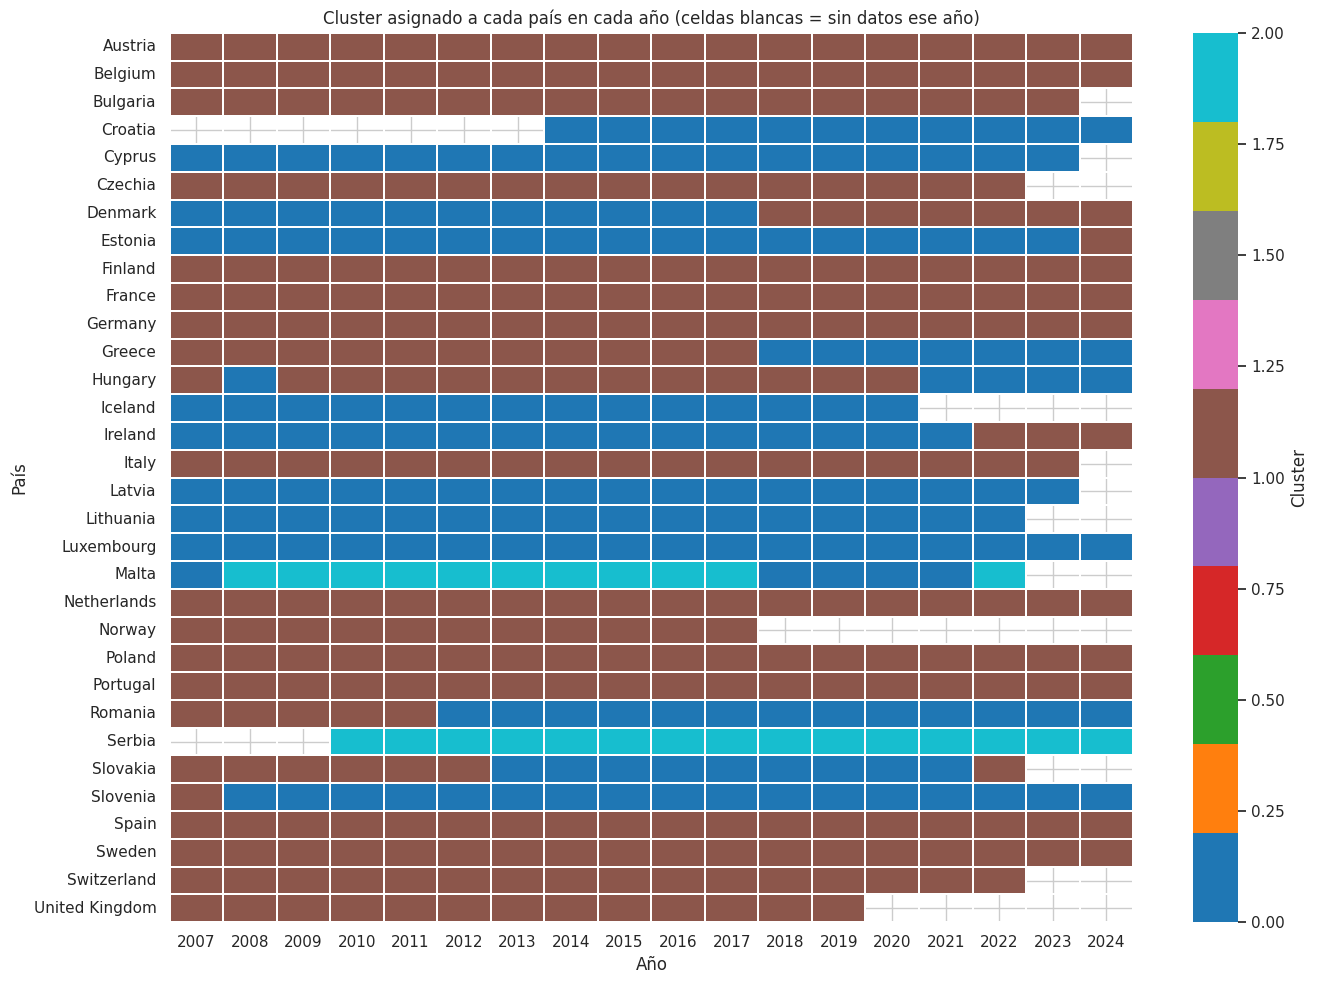

In [ ]:
# Matriz país (filas) x año (columnas) con el cluster asignado en cada año
pivot_pais_anio = panel_norm.pivot_table(
    index="countryName", columns="reportingYear", values="cluster_pais_anio", aggfunc="first"
)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_pais_anio, cmap="tab10", cbar_kws={"label": "Cluster"}, linewidths=0.3, linecolor="white")
plt.title("Cluster asignado a cada país en cada año (celdas blancas = sin datos ese año)")
plt.xlabel("Año")
plt.ylabel("País")
plt.tight_layout()
plt.show()

In [ ]:
# Movilidad entre clusters: países que más cambian de grupo a lo largo del tiempo
movilidad = (
    pivot_pais_anio.nunique(axis=1)
    .sort_values(ascending=False)
    .rename("n_clusters_distintos")
    .reset_index()
)
print("Países ordenados por número de clusters distintos a lo largo de los años")
print("(1 = perfil ambiental estable en el tiempo; >1 = el país cambió de grupo):")
display(movilidad)

Países ordenados por número de clusters distintos a lo largo de los años
(1 = perfil ambiental estable en el tiempo; >1 = el país cambió de grupo):


,countryName,n_clusters_distintos
0,Denmark,2
1,Estonia,2
2,Hungary,2
3,Greece,2
4,Ireland,2
5,Slovakia,2
6,Slovenia,2
7,Malta,2
8,Romania,2
9,Czechia,1


**Análisis de evolución temporal de los cluster por país y año**:

Aquí se repite el clustering sobre las 536 combinaciones país-año para detectar si algún país cambió su perfil de contaminantes a lo largo del tiempo.

La silueta de 0.276 indica que la estructura de grupos es estable en el tiempo.

El mapa de calor muestra que la mayoría mantienen el mismo cluster en todos los años exceptuando a Malta y Serbia con su cluster atípico. Las celdas blancas indican años carentes de datos (recordemos que no todos los países tenían cobertura completa en el tiempo).

Solo 8 países cambiaron de cluster en algún momento: Dinamarca, Estonia, Hungría, Grecia, Irlanda, Eslovaquia, Eslovenia, Malta y Rumanía. El resto mantuvo el mismo cluster en todos los años disponibles.

## XIII. Conclusiones

Resumen de los principales resultados obtenidos, calculados directamente a partir de la ejecución del notebook.

In [ ]:
# Indicadores finales de resumen
indicadores_finales = {
    "Países analizados": country_df.shape[0],
    "Variables de contaminantes utilizadas": len(POLLUTANT_COLS),
    "Número de clusters (k)": int(K),
    "Silueta K-Means (nivel país)": round(silhouette_score(X_scaled, labels_kmeans), 3),
    "Silueta jerárquico (nivel país)": round(silhouette_score(X_scaled, labels_jerarquico), 3),
    "Acuerdo K-Means vs jerárquico (ARI)": round(ari, 3),
    "Varianza explicada por PC1+PC2": f"{pca_2d.explained_variance_ratio_.sum():.1%}",
    "Semilla utilizada (SEED)": SEED,
}

for k_, v_ in indicadores_finales.items():
    print(f"{k_}: {v_}")

Países analizados: 32
Variables de contaminantes utilizadas: 35
Número de clusters (k): 3
Silueta K-Means (nivel país): 0.273
Silueta jerárquico (nivel país): 0.188
Acuerdo K-Means vs jerárquico (ARI): 0.361
Varianza explicada por PC1+PC2: 42.3%
Semilla utilizada (SEED): 42


### Síntesis metodológica

- Se construyó un panel de características ambientales **por país y año** a partir de las 35 variables `AIR_*`, `WATER_*`, `WASTE_*` y `TRANSFER_*`, agregando y normalizando por número de instalaciones para hacer comparables países de distinto tamaño industrial.
- Ese panel se resumió en un perfil **promedio por país** (32 países x 35 variables), utilizado como base principal para el clustering.
- Se aplicaron dos algoritmos de clustering no supervisado — **K-Means** y **clustering jerárquico (Ward)** —, seleccionando el número de grupos mediante el método del codo y el coeficiente de silueta.
- Se utilizó **PCA** para reducir la dimensionalidad a 2 componentes y visualizar la posición relativa de los países y de los clusters obtenidos.
- Se interpretaron los grupos resultantes de forma automática, identificando el perfil medio por grupo ambiental y las variables más distintivas de cada cluster.
- Como extensión, se replicó el clustering a nivel **país-año**, permitiendo observar la estabilidad o movilidad de cada país entre clusters a lo largo del período 2007-2024.
- **Todo el proceso estocástico (K-Means, PCA) utiliza `SEED = 42`**, garantizando que los clusters obtenidos son reproducibles y no cambian entre ejecuciones sucesivas del notebook.


Los 3 clusters identificados son:
- **Cluster 0** (Malta, Serbia): atípicos con vertidos
  de metales pesados al agua desproporcionadamente altos
  por instalación — resultado que debe interpretarse
  con cautela por el pequeño número de instalaciones
  que amplifica valores puntuales extremos.
- **Cluster 1** (23 países): núcleo industrial europeo
  con perfil ambiental completo y equilibrado en todas
  las dimensiones.
- **Cluster 2** (7 países pequeños): perfil bajo en
  la mayoría de contaminantes — países con menor
  base industrial.

La extensión temporal confirma que los perfiles
ambientales son **estructuralmente estables** —
solo 8 de los 32 países cambiaron de cluster
en algún año del periodo 2007-2024.

### Limitaciones

- La normalización por instalación puede amplificar el peso de países con muy pocas plantas reportantes (p. ej. Malta), generando clusters pequeños dominados por casos atípicos.
- Las variables con muchos valores no reportados (imputados como 0 tras la normalización) pueden subestimar la actividad real de un país en ese contaminante específico.
- El resultado del clustering depende de las decisiones de preprocesamiento (log1p + estandarización); otras transformaciones podrían producir agrupaciones distintas.

In [ ]:
joblib.dump(kmeans_final, MODELOS + 'model_clusters.pkl')
print(f"\n  Modelo guardado en: {MODELOS}model_clusters.pkl")

# Verificar
if os.path.exists(MODELOS + 'model_clusters.pkl'):
    size = os.path.getsize(MODELOS + 'model_clusters.pkl') / 1024**2
    print(f"  ✓ model_clusters.pkl — {size:.2f} MB")
else:
    print(f"  ✗ Error — fichero no encontrado")


  Modelo guardado en: /content/drive/MyDrive/TFM/modelos/model_clusters.pkl
  ✓ model_clusters.pkl — 0.00 MB


# 6. Predicción temporal de emisiones industriales 2025-2030
## Modelo de series temporales aplicado al registro europeo E-PRTR

**Fuente de datos:** European Pollutant Release and Transfer Register (E-PRTR)  
**Dataset utilizado:** `dataset_merged_limpio.csv`, el mismo dataset consolidado empleado en el modelo de regresión del TFM.

### Objetivo

Complementar el modelo de regresión a nivel instalación-año con un modelo de series temporales agregado a nivel europeo, con el objetivo de:

1. estudiar la evolución anual de las emisiones industriales reportadas;
2. evaluar si existe una tendencia temporal suficientemente estable para realizar predicciones;
3. comparar varios modelos de series temporales mediante validación temporal;
4. generar previsiones para 2025-2030;
5. interpretar esas previsiones en relación con la trayectoria de reducción de emisiones del estudio.

### Diferencia respecto al modelo de regresión

El modelo de regresión responde a una pregunta micro: cuánto CO₂ puede emitir una instalación según su perfil de contaminantes, sector, país y año.

El modelo de series temporales responde a una pregunta macro: cómo evolucionará el volumen agregado de emisiones reportadas en Europa a partir de su propia historia temporal.

Por tanto, ambos análisis son complementarios y no deben interpretarse como modelos alternativos.

In [ ]:
# Imports series temporales
!pip -q install statsmodels

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA


print("Librerías series temporales cargadas")

Librerías series temporales cargadas


## Fase 1 — Carga y verificación de estructura

El dataset conserva la estructura de panel instalación × año utilizada en la regresión. Para construir una serie temporal europea, cada año se agregan las emisiones reportadas de todas las instalaciones.

Es importante no interpretar los valores ausentes de CO₂ como cero: según la metodología ya establecida en el TFM, la ausencia de reporte está vinculada al umbral legal de declaración. Por tanto, la serie construida representa las emisiones de CO₂ reportadas al E-PRTR, no una estimación de todas las emisiones industriales reales de Europa.

In [ ]:
print(f"Instalaciones únicas: {df_merged['FacilityInspireId'].nunique():,}")
print(f"Rango temporal: {df_merged['reportingYear'].min()} - {df_merged['reportingYear'].max()}")
print(f"Duplicados exactos: {df_merged.duplicated().sum()}")
print(f"Duplicados por (instalación, año): "
      f"{df_merged.duplicated(subset=['FacilityInspireId','reportingYear']).sum()}")

TARGET_CO2 = 'AIR_Carbon dioxide (CO2)'

if TARGET_CO2 not in df_merged.columns:
    raise KeyError(f"No se encuentra la variable objetivo: {TARGET_CO2}")

Instalaciones únicas: 10,788
Rango temporal: 2007 - 2024
Duplicados exactos: 0
Duplicados por (instalación, año): 0


**Conclusión de la fase:** se parte exactamente del mismo dataset consolidado que en el modelo de regresión, evitando diferencias de cobertura, limpieza o definición entre ambas partes del TFM.

## Fase 2 — Construcción de la serie temporal agregada

La unidad de observación cambia respecto a la regresión:

- **Regresión:** una fila = una instalación en un año.
- **Series temporales:** una fila = un año.

Para cada año se calcula la suma de las emisiones de CO₂ reportadas. Los datos originales están expresados en kg/año, por lo que la serie se convierte a toneladas/año, manteniendo la misma conversión realizada en el notebook de regresión.

In [ ]:
# Conservamos únicamente emisiones de CO2 reportadas y positivas
df_ts = df_merged[
    df_merged[TARGET_CO2].notna() &
    (df_merged[TARGET_CO2] > 0)
].copy()

# Conversión de kg a toneladas
df_ts['CO2_toneladas'] = df_ts[TARGET_CO2] / 1000

# Agregación anual europea
ts_co2 = (
    df_ts.groupby('reportingYear', as_index=True)['CO2_toneladas']
    .sum()
    .sort_index()
    .rename('CO2_total_t')
    .to_frame()
)

# Garantizar índice anual continuo
full_years = pd.Index(
    range(int(ts_co2.index.min()), int(ts_co2.index.max()) + 1),
    name='reportingYear'
)
ts_co2 = ts_co2.reindex(full_years)

if ts_co2['CO2_total_t'].isna().any():
    missing_years = ts_co2.index[ts_co2['CO2_total_t'].isna()].tolist()
    raise ValueError(f"Faltan años en la serie agregada: {missing_years}")

print(ts_co2)
print(f"\nObservaciones temporales: {len(ts_co2)} años")
print(f"Primer año: {ts_co2.index.min()}")
print(f"Último año: {ts_co2.index.max()}")

                    CO2_total_t
reportingYear                  
2007          2,050,285,000.000
2008          2,007,166,000.000
2009          1,875,730,000.000
2010          1,946,342,000.000
2011          1,852,102,000.000
2012          1,852,403,000.000
2013          1,798,056,000.000
2014          1,765,151,000.000
2015          1,707,541,000.000
2016          1,671,845,000.000
2017          1,680,786,000.000
2018          1,597,135,836.414
2019          1,477,756,490.168
2020          1,179,745,790.246
2021          1,273,440,775.674
2022          1,264,234,091.088
2023          1,021,433,624.738
2024            819,273,259.067

Observaciones temporales: 18 años
Primer año: 2007
Último año: 2024


count              18.000
mean    1,602,245,937.077
std       354,522,451.858
min       819,273,259.067
25%     1,324,519,704.297
50%     1,694,163,500.000
75%     1,852,327,750.000
max     2,050,285,000.000
Name: CO2_total_t, dtype: float64

Cambio 2007-2024: -60.0%
Tasa media anual aproximada (CAGR): -5.25%


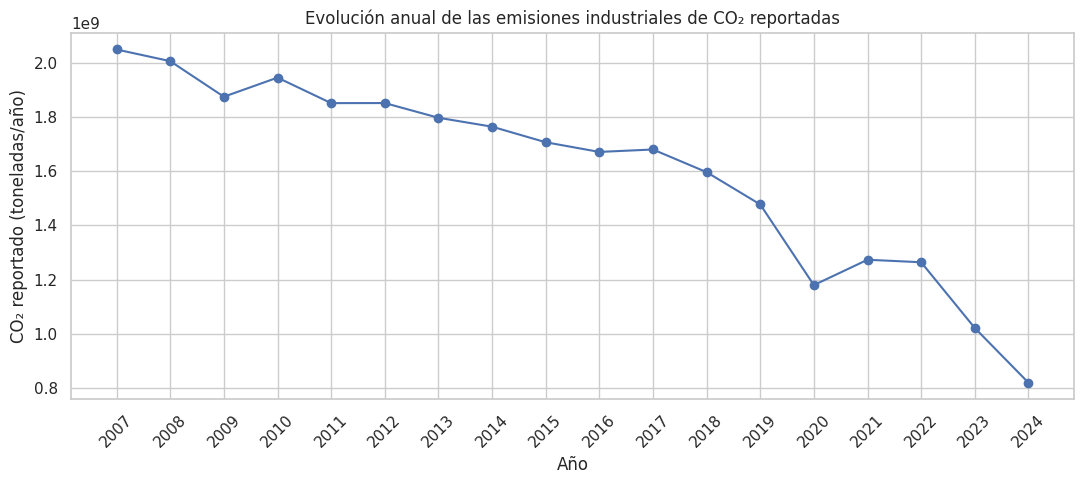

In [ ]:
# Estadística descriptiva de la serie
serie = ts_co2['CO2_total_t']

print(serie.describe())
print(f"\nCambio 2007-2024: {(serie.iloc[-1] / serie.iloc[0] - 1) * 100:.1f}%")
print(f"Tasa media anual aproximada (CAGR): "
      f"{((serie.iloc[-1] / serie.iloc[0]) ** (1/(len(serie)-1)) - 1) * 100:.2f}%")

plt.figure(figsize=(11, 5))
plt.plot(serie.index, serie.values, marker='o')
plt.title('Evolución anual de las emisiones industriales de CO₂ reportadas')
plt.xlabel('Año')
plt.ylabel('CO₂ reportado (toneladas/año)')
plt.xticks(serie.index, rotation=45)
plt.tight_layout()
plt.show()

## Fase 3 — Análisis exploratorio de la dinámica temporal

Antes de estimar un modelo, se comprueba si la serie presenta:

- tendencia creciente o decreciente;
- cambios importantes entre años;
- crecimiento/descenso aproximadamente constante;
- necesidad de trabajar en escala logarítmica.

Al tratarse de datos anuales, no se introduce estacionalidad mensual o trimestral: no existe una frecuencia intranual que justifique un componente estacional.

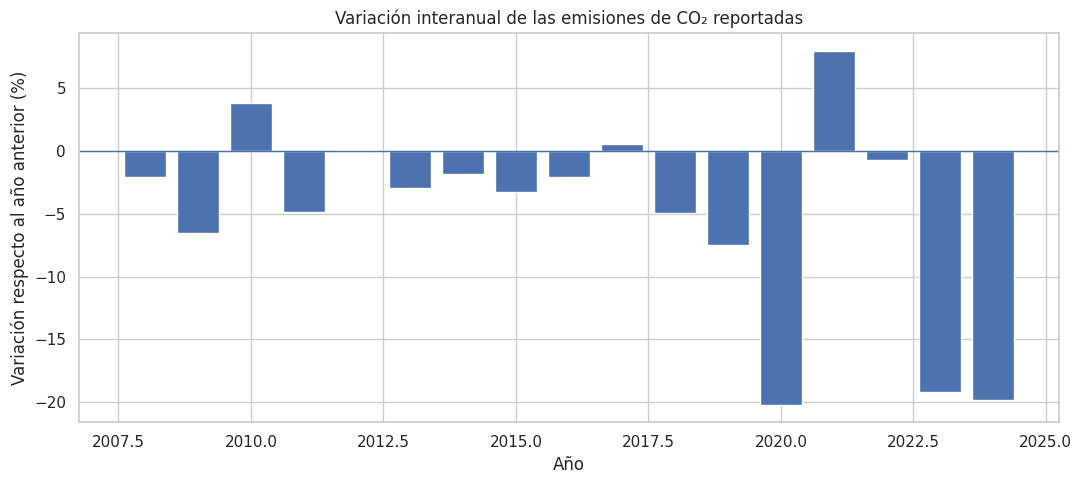

Variaciones interanuales:
reportingYear
2007       NaN
2008    -2.100
2009    -6.550
2010     3.760
2011    -4.840
2012     0.020
2013    -2.930
2014    -1.830
2015    -3.260
2016    -2.090
2017     0.530
2018    -4.980
2019    -7.470
2020   -20.170
2021     7.940
2022    -0.720
2023   -19.210
2024   -19.790
Name: YoY_%, dtype: float64


In [ ]:
# Variación interanual
ts_co2['YoY_%'] = ts_co2['CO2_total_t'].pct_change() * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(ts_co2.index, ts_co2['YoY_%'])
ax.axhline(0, linewidth=1)
ax.set_title('Variación interanual de las emisiones de CO₂ reportadas')
ax.set_xlabel('Año')
ax.set_ylabel('Variación respecto al año anterior (%)')
plt.tight_layout()
plt.show()

print("Variaciones interanuales:")
print(ts_co2['YoY_%'].round(2))

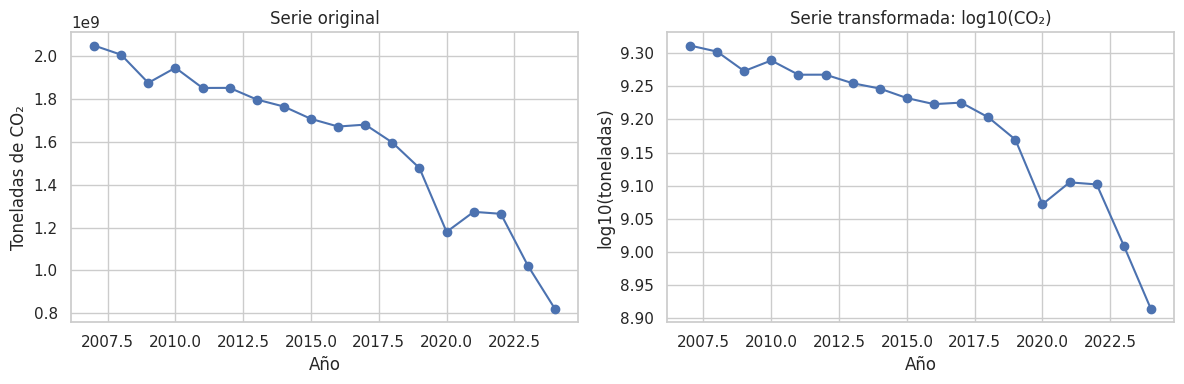

In [ ]:
# Transformación logarítmica, siguiendo la lógica empleada en la regresión
ts_co2['log10_CO2'] = np.log10(ts_co2['CO2_total_t'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ts_co2.index, ts_co2['CO2_total_t'], marker='o')
axes[0].set_title('Serie original')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Toneladas de CO₂')

axes[1].plot(ts_co2.index, ts_co2['log10_CO2'], marker='o')
axes[1].set_title('Serie transformada: log10(CO₂)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('log10(toneladas)')

plt.tight_layout()
plt.show()

**Conclusión de la fase:** la serie anual muestra una tendencia temporal que puede modelarse mediante métodos de nivel/tendencia y modelos ARIMA. La transformación log10 se utiliza para estabilizar la escala y mantener coherencia con el tratamiento del CO₂ realizado en la regresión, pero las métricas y las previsiones finales se devuelven siempre a toneladas reales.

## Fase 4 — Diseño de la validación temporal

En una serie temporal no es correcto utilizar una partición aleatoria convencional, porque eso permitiría que observaciones futuras influyeran en la evaluación del pasado.

Se utiliza validación rolling-origin:

1. se entrena con un bloque inicial de años;
2. se predicen los siguientes años;
3. el periodo de entrenamiento se amplía;
4. se repite el proceso.

De esta forma se evalúa la capacidad del modelo para predecir años que realmente vienen después de los datos utilizados para entrenarlo.

In [ ]:
# Serie utilizada para modelar
y = ts_co2['log10_CO2'].copy()

# Para el backtesting reservamos los últimos 3 años como un primer bloque de evaluación.
# Los folds anteriores se construyen de forma creciente para respetar el orden temporal.
N_TEST_FINAL = 3
train_base = y.iloc[:-N_TEST_FINAL]
test_final = y.iloc[-N_TEST_FINAL:]

print(f"Train inicial: {train_base.index.min()} - {train_base.index.max()} ({len(train_base)} años)")
print(f"Test final:    {test_final.index.min()} - {test_final.index.max()} ({len(test_final)} años)")

Train inicial: 2007 - 2021 (15 años)
Test final:    2022 - 2024 (3 años)


## Fase 5 — Modelos candidatos

Se comparan modelos de complejidad creciente:

| Modelo | Idea principal |
|---|---|
| Naive | El siguiente valor es igual al último observado |
| Drift | Prolonga la tendencia media observada |
| Holt | Modela nivel y tendencia |
| Holt damped | Permite tendencia, pero hace que se modere a largo plazo |
| ARIMA | Combina autorregresión, diferenciación y medias móviles |

Los modelos Naive y Drift se mantienen como benchmarks. Un modelo más sofisticado solo es útil si supera estas referencias en validación temporal.

In [ ]:
def forecast_naive(train, horizon):
    return pd.Series(np.repeat(train.iloc[-1], horizon),
                     index=pd.RangeIndex(horizon))

def forecast_drift(train, horizon):
    # Pronóstico lineal basado en el cambio medio entre el primer y último punto
    if len(train) < 2:
        return forecast_naive(train, horizon)
    slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
    steps = np.arange(1, horizon + 1)
    return pd.Series(train.iloc[-1] + slope * steps,
                     index=pd.RangeIndex(horizon))

def forecast_holt(train, horizon, damped=False):
    model = ExponentialSmoothing(
        train,
        trend='add',
        damped_trend=damped,
        seasonal=None,
        initialization_method='estimated'
    ).fit(optimized=True)
    return model.forecast(horizon)

def forecast_arima(train, horizon, order):
    model = ARIMA(train, order=order, trend=None).fit()
    return model.forecast(horizon)

def forecast_model(train, horizon, model_name):
    if model_name == 'Naive':
        return forecast_naive(train, horizon)
    if model_name == 'Drift':
        return forecast_drift(train, horizon)
    if model_name == 'Holt':
        return forecast_holt(train, horizon, damped=False)
    if model_name == 'Holt damped':
        return forecast_holt(train, horizon, damped=True)
    if model_name.startswith('ARIMA'):
        order = MODEL_ORDERS[model_name]
        return forecast_arima(train, horizon, order)
    raise ValueError(model_name)

MODEL_ORDERS = {
    'ARIMA(0,1,1)': (0, 1, 1),
    'ARIMA(1,1,0)': (1, 1, 0),
    'ARIMA(1,1,1)': (1, 1, 1),
    'ARIMA(2,1,0)': (2, 1, 0)
}

MODEL_NAMES = [
    'Naive',
    'Drift',
    'Holt',
    'Holt damped',
    *MODEL_ORDERS.keys()
]

print("Modelos candidatos:", MODEL_NAMES)

Modelos candidatos: ['Naive', 'Drift', 'Holt', 'Holt damped', 'ARIMA(0,1,1)', 'ARIMA(1,1,0)', 'ARIMA(1,1,1)', 'ARIMA(2,1,0)']


## Fase 6 — Backtesting y selección del modelo

La selección se realiza con varios cortes temporales de validación. La métrica principal será el **RMSE en escala real**, porque penaliza especialmente los errores grandes, relevantes cuando el objetivo es estimar toneladas de CO₂.

También se calculan MAE y MAPE para facilitar la interpretación.

In [ ]:
def evaluate_predictions(y_true_log, y_pred_log):
    y_true_real = 10 ** np.asarray(y_true_log)
    y_pred_real = 10 ** np.asarray(y_pred_log)

    mae = mean_absolute_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    mape = np.mean(np.abs((y_true_real - y_pred_real) / y_true_real)) * 100

    return mae, rmse, mape

# Folds de validación: horizonte de 2 años
VALIDATION_HORIZON = 2
initial_train_size = len(y) - 6

folds = []
train_end = initial_train_size

while train_end + VALIDATION_HORIZON <= len(y):
    train_slice = y.iloc[:train_end]
    val_slice = y.iloc[train_end:train_end + VALIDATION_HORIZON]
    folds.append((train_slice, val_slice))
    train_end += VALIDATION_HORIZON

print(f"Número de folds temporales: {len(folds)}")
for j, (tr, va) in enumerate(folds, start=1):
    print(f"Fold {j}: train {tr.index.min()}-{tr.index.max()} | "
          f"validación {va.index.min()}-{va.index.max()}")

Número de folds temporales: 3
Fold 1: train 2007-2018 | validación 2019-2020
Fold 2: train 2007-2020 | validación 2021-2022
Fold 3: train 2007-2022 | validación 2023-2024


In [ ]:
results = []

for model_name in MODEL_NAMES:
    fold_metrics = []

    for fold_id, (train_fold, val_fold) in enumerate(folds, start=1):
        try:
            pred = forecast_model(train_fold, len(val_fold), model_name)
            mae, rmse, mape = evaluate_predictions(val_fold, pred)

            fold_metrics.append({
                'Modelo': model_name,
                'Fold': fold_id,
                'MAE_t': mae,
                'RMSE_t': rmse,
                'MAPE_%': mape
            })
        except Exception as e:
            fold_metrics.append({
                'Modelo': model_name,
                'Fold': fold_id,
                'MAE_t': np.nan,
                'RMSE_t': np.nan,
                'MAPE_%': np.nan
            })
            print(f"Advertencia: {model_name} falló en fold {fold_id}: {e}")

    results.extend(fold_metrics)

backtest_df = pd.DataFrame(results)

summary_models = (
    backtest_df.groupby('Modelo')
    .agg(
        MAE_t=('MAE_t', 'mean'),
        RMSE_t=('RMSE_t', 'mean'),
        MAPE_pct=('MAPE_%', 'mean'),
        Folds_validos=('RMSE_t', 'count')
    )
    .sort_values('RMSE_t')
)

print(summary_models)

                       MAE_t          RMSE_t  MAPE_pct  Folds_validos
Modelo                                                               
Drift        220,364,443.712 236,902,211.298    20.841              3
Naive        233,785,662.843 251,537,664.071    22.597              3
ARIMA(0,1,1) 260,113,977.242 277,661,978.718    24.665              3
Holt         287,970,072.752 306,649,500.783    25.962              3
Holt damped  289,953,687.061 308,584,647.522    26.168              3
ARIMA(1,1,1) 294,648,082.932 312,077,545.541    26.876              3
ARIMA(2,1,0) 303,821,789.397 320,637,743.312    28.229              3
ARIMA(1,1,0) 345,924,826.724 366,281,617.142    31.432              3


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [ ]:
# Selección del mejor modelo:
# se exige que haya funcionado en todos los folds y se minimiza el RMSE medio.
valid_models = summary_models[summary_models['Folds_validos'] == len(folds)].copy()

if valid_models.empty:
    raise RuntimeError("Ningún modelo ha completado todos los folds de validación.")

BEST_MODEL = valid_models.index[0]

print(f"\nMejor modelo según RMSE medio de validación temporal: {BEST_MODEL}")
print(f"RMSE medio: {valid_models.loc[BEST_MODEL, 'RMSE_t']:,.0f} t")
print(f"MAE medio:  {valid_models.loc[BEST_MODEL, 'MAE_t']:,.0f} t")
print(f"MAPE medio: {valid_models.loc[BEST_MODEL, 'MAPE_pct']:.2f}%")


Mejor modelo según RMSE medio de validación temporal: Drift
RMSE medio: 236,902,211 t
MAE medio:  220,364,444 t
MAPE medio: 20.84%


**Conclusión de la fase:** la elección del modelo no se basa en qué técnica es más sofisticada, sino en qué método consigue los mejores resultados cuando se enfrenta a años que no ha visto. Este criterio es especialmente importante en este TFM porque el objetivo final es pronosticar 2025-2030.

## Fase 7 — Evaluación sobre el periodo final de test

Después de seleccionar el modelo con el backtesting temporal, se realiza una evaluación final sobre los últimos años reservados.

Este paso funciona como una comprobación fuera de muestra y evita utilizar el mismo periodo para seleccionar y presentar el rendimiento final.

In [ ]:
# Evaluación final sobre los últimos 3 años
train_final = y.iloc[:-N_TEST_FINAL]
test_final = y.iloc[-N_TEST_FINAL:]

pred_test_final_log = forecast_model(
    train_final,
    len(test_final),
    BEST_MODEL
)

mae_final, rmse_final, mape_final = evaluate_predictions(
    test_final,
    pred_test_final_log
)

y_test_real = 10 ** test_final
y_pred_real = 10 ** pred_test_final_log

r2_final = r2_score(y_test_real, y_pred_real)

final_metrics = pd.DataFrame([{
    'Modelo': BEST_MODEL,
    'MAE_t': mae_final,
    'RMSE_t': rmse_final,
    'MAPE_%': mape_final,
    'R2': r2_final
}])

print(final_metrics)

test_comparison = pd.DataFrame({
    'Año': test_final.index,
    'CO2_real_t': y_test_real.values,
    'CO2_predicho_t': y_pred_real.values
}).set_index('Año')

test_comparison['Error_t'] = test_comparison['CO2_real_t'] - test_comparison['CO2_predicho_t']
test_comparison['Error_%'] = (
    test_comparison['Error_t'] / test_comparison['CO2_real_t'] * 100
)

print("\nComparación real vs predicho:")
print(test_comparison.round(0))

  Modelo           MAE_t          RMSE_t  MAPE_%     R2
0  Drift 177,417,164.654 215,042,970.688  19.823 -0.398

Comparación real vs predicho:
            CO2_real_t    CO2_predicho_t          Error_t  Error_%
Año                                                               
2022 1,264,234,091.000 1,230,849,033.000   33,385,058.000    3.000
2023 1,021,433,625.000 1,189,681,822.000 -168,248,197.000  -16.000
2024   819,273,259.000 1,149,891,498.000 -330,618,239.000  -40.000


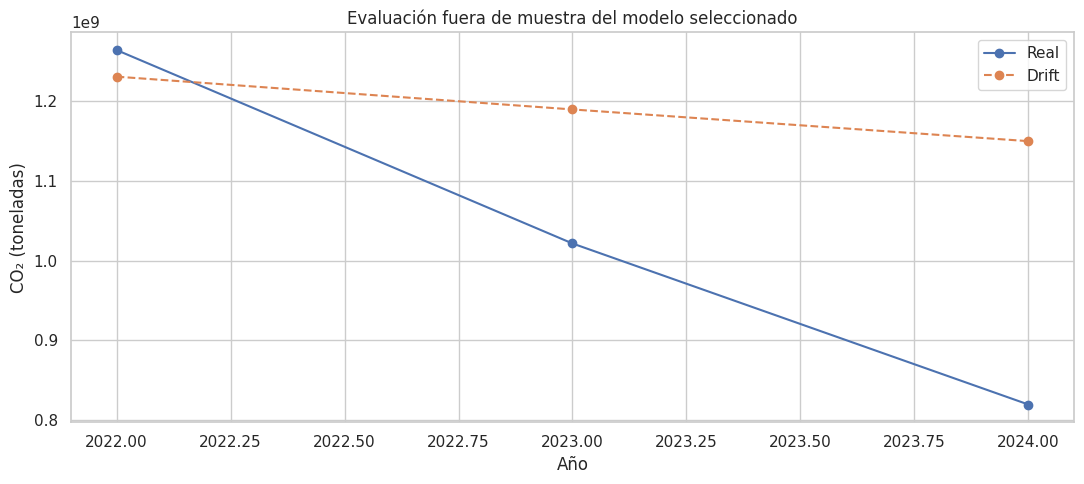

In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(test_comparison.index, test_comparison['CO2_real_t'],
         marker='o', label='Real')
plt.plot(test_comparison.index, test_comparison['CO2_predicho_t'],
         marker='o', linestyle='--', label=f'{BEST_MODEL}')
plt.title('Evaluación fuera de muestra del modelo seleccionado')
plt.xlabel('Año')
plt.ylabel('CO₂ (toneladas)')
plt.legend()
plt.tight_layout()
plt.show()

## Fase 8 — Reestimación y previsión 2025-2030

Una vez elegido el modelo, se vuelve a entrenar utilizando **todos los datos históricos disponibles (2007-2024)**.

Este último ajuste es el que se utiliza para producir las previsiones de 2025 a 2030. La predicción no utiliza ninguna información futura, sino únicamente la trayectoria observada hasta 2024.

In [ ]:
# Reajuste sobre toda la serie histórica
forecast_horizon = 6
future_years = pd.Index(range(2025, 2031), name='reportingYear')

forecast_log = forecast_model(
    y,
    forecast_horizon,
    BEST_MODEL
)
forecast_log.index = future_years

forecast_real = 10 ** forecast_log

forecast_df = pd.DataFrame({
    'Año': future_years,
    'CO2_predicho_t': forecast_real.values
}).set_index('Año')

print("Previsión de emisiones de CO₂ reportadas para 2025-2030:")
print(forecast_df.round(0))

Previsión de emisiones de CO₂ reportadas para 2025-2030:
      CO2_predicho_t
Año                 
2025 776,237,002.000
2026 735,461,432.000
2027 696,827,793.000
2028 660,223,572.000
2029 625,542,163.000
2030 592,682,561.000


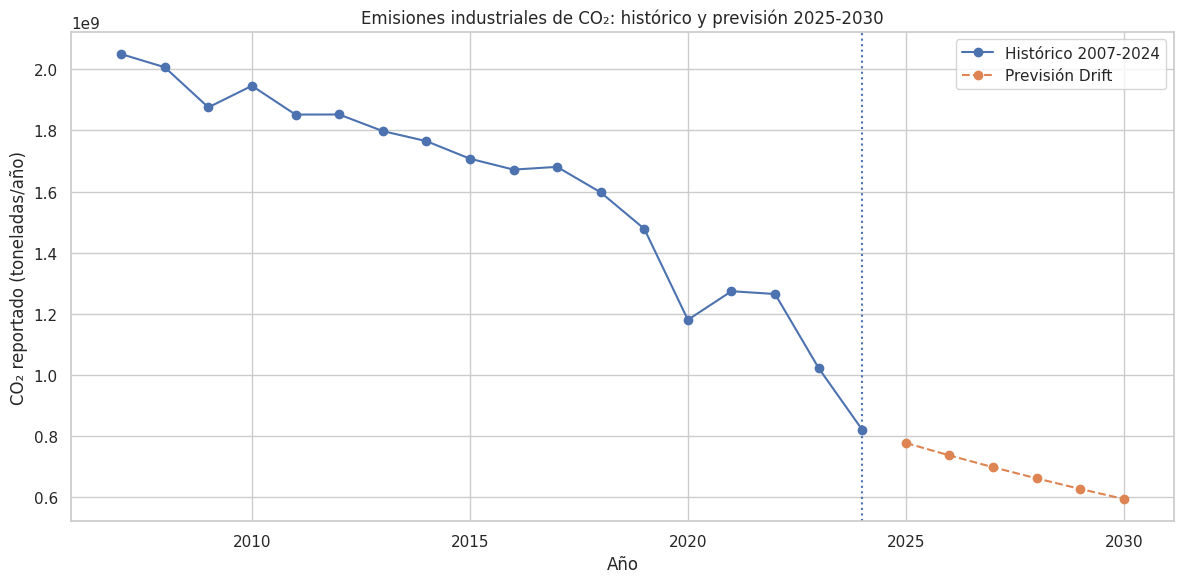

In [ ]:
# Comparación visual histórico + previsión
plt.figure(figsize=(12, 6))

plt.plot(
    ts_co2.index,
    ts_co2['CO2_total_t'],
    marker='o',
    label='Histórico 2007-2024'
)

plt.plot(
    forecast_df.index,
    forecast_df['CO2_predicho_t'],
    marker='o',
    linestyle='--',
    label=f'Previsión {BEST_MODEL}'
)

plt.axvline(2024, linestyle=':', linewidth=1.5)
plt.title('Emisiones industriales de CO₂: histórico y previsión 2025-2030')
plt.xlabel('Año')
plt.ylabel('CO₂ reportado (toneladas/año)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Variación respecto a 2024
co2_2024 = ts_co2.loc[2024, 'CO2_total_t']

forecast_df['Cambio_vs_2024_%'] = (
    (forecast_df['CO2_predicho_t'] / co2_2024) - 1
) * 100

forecast_df['Reduccion_vs_2024_%'] = (
    1 - forecast_df['CO2_predicho_t'] / co2_2024
) * 100

print(f"CO₂ reportado en 2024: {co2_2024:,.0f} t")
print("\nPrevisión y cambio respecto a 2024:")
print(forecast_df.round(2))

reduccion_2030 = forecast_df.loc[2030, 'Reduccion_vs_2024_%']
print(f"\nReducción prevista 2024-2030: {reduccion_2030:.1f}%")

CO₂ reportado en 2024: 819,273,259 t

Previsión y cambio respecto a 2024:
      CO2_predicho_t  Cambio_vs_2024_%  Reduccion_vs_2024_%
Año                                                        
2025 776,237,002.460            -5.250                5.250
2026 735,461,431.600           -10.230               10.230
2027 696,827,793.140           -14.950               14.950
2028 660,223,571.790           -19.410               19.410
2029 625,542,162.700           -23.650               23.650
2030 592,682,560.930           -27.660               27.660

Reducción prevista 2024-2030: 27.7%


In [ ]:
# Ajuste final del modelo sobre toda la serie histórica y guardado en .pkl
import joblib
import os

# Reajustamos el modelo ganador con todos los datos disponibles (2007-2024)
if BEST_MODEL == 'Naive':
    modelo_final = {
        'tipo': 'Naive',
        'serie_entrenamiento': y.copy()
    }

elif BEST_MODEL == 'Drift':
    modelo_final = {
        'tipo': 'Drift',
        'serie_entrenamiento': y.copy()
    }

elif BEST_MODEL == 'Holt':
    modelo_final = ExponentialSmoothing(
        y,
        trend='add',
        damped_trend=False,
        seasonal=None,
        initialization_method='estimated'
    ).fit(optimized=True)

elif BEST_MODEL == 'Holt damped':
    modelo_final = ExponentialSmoothing(
        y,
        trend='add',
        damped_trend=True,
        seasonal=None,
        initialization_method='estimated'
    ).fit(optimized=True)

elif BEST_MODEL.startswith('ARIMA'):
    order = MODEL_ORDERS[BEST_MODEL]
    modelo_final = ARIMA(y, order=order, trend=None).fit()

# Guardamos el objeto final
path_modelo = MODELOS + 'model_series.pkl'
joblib.dump(modelo_final, path_modelo)

print(f"\nModelo seleccionado: {BEST_MODEL}")
print(f"Modelo guardado en: {path_modelo}")

if os.path.exists(path_modelo):
    size = os.path.getsize(path_modelo) / 1024**2
    print(f"  ✓ model_series.pkl — {size:.1f} MB")
else:
    print("  ✗ Error — fichero no encontrado")


Modelo seleccionado: Drift
Modelo guardado en: /content/drive/MyDrive/TFM/modelos/model_series.pkl
  ✓ model_series.pkl — 0.0 MB


### Nota importante sobre la comparación con el Green Deal

El objetivo europeo del **Pacto Verde** de reducir las emisiones netas un 55% para 2030 se define respecto a 1990 y para las emisiones de gases de efecto invernadero en su conjunto.

La serie de este TFM comienza en 2007, mide **CO₂ industrial reportado al E-PRTR** y está condicionada por los umbrales de reporte. Por tanto, no es metodológicamente correcto afirmar que una previsión 2025-2030 "cumple" o "no cumple" directamente el objetivo europeo del -55%.

La comparación válida dentro de este análisis es estudiar si la trayectoria prevista mantiene una reducción suficientemente intensa y, de forma separada, discutir cómo esa tendencia es compatible o no con el objetivo político general.

## Fase 9 — Conclusiones del modelo de series temporales

La lectura final de esta parte debe responder a cuatro preguntas:

1. **¿Existe una tendencia temporal?**  
   Se describe a partir de la serie 2007-2024 y de sus variaciones interanuales.

2. **¿Qué modelo funciona mejor fuera de muestra?**  
   Se selecciona mediante validación rolling-origin y no por complejidad teórica.

3. **¿Qué se prevé para 2025-2030?**  
   La previsión se genera después de reajustar el modelo con todos los años disponibles hasta 2024.

4. **¿Qué implica para el TFM?**  
   El modelo permite transformar la evolución histórica de las emisiones en una trayectoria futura cuantificable. Sin embargo, las previsiones deben entenderse como una prolongación estadística de los patrones observados, no como una estimación causal del efecto de futuras políticas ambientales.

### Limitaciones principales

- Solo existen 18 observaciones anuales, por lo que no conviene utilizar modelos excesivamente complejos.
- La serie representa emisiones industriales **reportadas** al E-PRTR, no todas las emisiones industriales reales.
- Los cambios regulatorios, cierres de plantas, crisis económicas o innovaciones tecnológicas pueden generar rupturas estructurales que el modelo histórico no anticipe.
- Una previsión hasta 2030 es especialmente sensible a la especificación elegida cuando el horizonte es relativamente largo.

In [ ]:
# Resumen final
resumen_2024_2030 = pd.DataFrame({
    'Indicador': [
        'CO2 reportado 2024 (t)',
        'CO2 previsto 2030 (t)',
        'Cambio previsto 2024-2030 (%)',
        'Modelo seleccionado',
        'Horizonte de previsión'
    ],
    'Valor': [
        co2_2024,
        forecast_df.loc[2030, 'CO2_predicho_t'],
        forecast_df.loc[2030, 'Cambio_vs_2024_%'],
        BEST_MODEL,
        '2025-2030'
    ]
})

print(resumen_2024_2030)

                       Indicador           Valor
0         CO2 reportado 2024 (t) 819,273,259.067
1          CO2 previsto 2030 (t) 592,682,560.934
2  Cambio previsto 2024-2030 (%)         -27.658
3            Modelo seleccionado           Drift
4         Horizonte de previsión       2025-2030
